# Private-vs-FLIR Thermal Proxy Alignment

This notebook audits three thermal bounding-box datasets in one workflow:

1. the private `v18` person-detection dataset,
2. the original public FLIR thermal detection dataset,
3. a reduced FLIR proxy subset constructed here.

The notebook is meant to serve as:

- a research instrument for domain diagnosis,
- a reproducible curation record,
- and a source of paper-ready plots and tables.

Scope guardrails:

- thermal imagery only,
- detection with axis-aligned bounding boxes only,
- no model training,
- no segmentation,
- no synthetic data generation,
- no multi-dataset fusion.

Core design principle:

- match person-centric transfer statistics and repetition bias to the private dataset,
- preserve multiclass structure and long-tail value inside FLIR.


In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import pickle
import random
import re
import sys
import warnings
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from PIL import Image

try:
    from scipy import stats
except Exception:
    stats = None


def _resolve_repo_root() -> Path:
    """Resolve repository root from notebook or script execution context."""
    try:
        from src.core.paths import repo_root as _repo_root

        return _repo_root()
    except Exception:
        start = Path.cwd().resolve()
        for candidate in [start, *start.parents]:
            if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
                return candidate
        raise RuntimeError("Could not resolve repository root from the current environment.")


REPO_ROOT = _resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.core.data.annotations import coco_bbox_to_xyxy, load_coco_annotations  # noqa: E402
from src.core.normalization import raw_to_norm_numpy  # noqa: E402


MISSING_RUNTIME_DEPS = []
for _name in ("pandas", "matplotlib", "seaborn"):
    try:
        __import__(_name)
    except Exception:
        MISSING_RUNTIME_DEPS.append(_name)

if MISSING_RUNTIME_DEPS:
    raise ImportError(
        "This notebook expects a notebook/analysis environment with "
        f"{', '.join(MISSING_RUNTIME_DEPS)} installed."
    )


SEED = 7
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.style.use("default")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

PRIVATE_ROOT = REPO_ROOT / "data" / "raw" / "v18"
FLIR_ROOT = REPO_ROOT / "data" / "raw" / "flir"
OUTPUT_ROOT = REPO_ROOT / "artifacts" / "analysis" / "flir_private_proxy_alignment"
CACHE_ROOT = REPO_ROOT / "data" / "cache" / "flir_private_proxy_alignment"
EXPORT_ROOT = REPO_ROOT / "data" / "derived" / "flir_private_proxy_alignment"

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

PRIVATE_TARGET_SPLIT = "train"
PRIVATE_AUDIT_SPLITS = ("train", "val", "test")
FLIR_SPLIT_DIRS = {
    "train": "images_thermal_train",
    "val": "images_thermal_val",
    "test": "video_thermal_test",
}

PERSON_LABEL = "person"
TOP_K_SCENES = 5
PAIRWISE_MAX_OBJECTS_GLOBAL = 40
PAIRWISE_SAMPLE_CAP = 20000
HEATMAP_BINS_X = 16
HEATMAP_BINS_Y = 12
COUNT_BIN_CAP = 10
AHASH_SIZE = 8
USE_CACHE = True
USE_ALL_FLIR_IMAGES_FOR_EXPORT = True

FLIR_CANONICAL_LABELS = {
    "person": "person",
    "bike": "bike",
    "car": "car",
    "motor": "motorcycle",
    "bus": "bus",
    "train": "train",
    "truck": "truck",
    "light": "traffic light",
    "hydrant": "fire hydrant",
    "sign": "street sign",
    "dog": "dog",
    "skateboard": "skateboard",
    "stroller": "stroller",
    "scooter": "scooter",
    "other vehicle": "other vehicle",
    "deer": "deer",
}

display(
    Markdown(
        "\n".join(
            [
                "**Environment**",
                "",
                f"- `REPO_ROOT`: `{REPO_ROOT}`",
                f"- `PRIVATE_ROOT`: `{PRIVATE_ROOT}`",
                f"- `FLIR_ROOT`: `{FLIR_ROOT}`",
                f"- `OUTPUT_ROOT`: `{OUTPUT_ROOT}`",
                f"- `EXPORT_ROOT`: `{EXPORT_ROOT}`",
                f"- `PRIVATE_TARGET_SPLIT`: `{PRIVATE_TARGET_SPLIT}`",
                f"- `FLIR_SPLITS`: `{tuple(FLIR_SPLIT_DIRS.keys())}`",
                f"- `USE_ALL_FLIR_IMAGES_FOR_EXPORT`: `{USE_ALL_FLIR_IMAGES_FOR_EXPORT}`",
                f"- `SEED`: `{SEED}`",
            ]
        )
    )
)


def save_figure(fig: plt.Figure, stem: str) -> None:
    """Save a figure to the notebook output directory."""
    path = OUTPUT_ROOT / f"{stem}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")


def save_table(df: pd.DataFrame, stem: str) -> None:
    """Save a table to CSV in the notebook output directory."""
    path = OUTPUT_ROOT / f"{stem}.csv"
    df.to_csv(path, index=False)


def robust_entropy(values: Sequence[float]) -> float:
    """Compute entropy on a non-negative vector."""
    arr = np.asarray(values, dtype=float)
    total = arr.sum()
    if total <= 0:
        return 0.0
    p = arr / total
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())


def gini_coefficient(values: Sequence[float]) -> float:
    """Compute the Gini coefficient for a non-negative vector."""
    arr = np.asarray(values, dtype=float)
    if arr.size == 0 or np.allclose(arr.sum(), 0.0):
        return 0.0
    arr = np.sort(arr)
    n = arr.size
    index = np.arange(1, n + 1)
    return float((2 * np.sum(index * arr) / (n * arr.sum())) - (n + 1) / n)


def js_divergence(p: Sequence[float], q: Sequence[float], eps: float = 1e-12) -> float:
    """Jensen-Shannon divergence between two histograms or categorical vectors."""
    p_arr = np.asarray(p, dtype=float)
    q_arr = np.asarray(q, dtype=float)
    if p_arr.sum() <= 0 and q_arr.sum() <= 0:
        return 0.0
    p_arr = p_arr / max(p_arr.sum(), eps)
    q_arr = q_arr / max(q_arr.sum(), eps)
    m_arr = 0.5 * (p_arr + q_arr)

    def _kl(a: np.ndarray, b: np.ndarray) -> float:
        mask = a > 0
        return float(np.sum(a[mask] * np.log2((a[mask] + eps) / (b[mask] + eps))))

    return 0.5 * _kl(p_arr, m_arr) + 0.5 * _kl(q_arr, m_arr)


def wasserstein_1d(a: Sequence[float], b: Sequence[float]) -> float:
    """Wasserstein-1 distance with scipy fallback."""
    a_arr = np.asarray(list(a), dtype=float)
    b_arr = np.asarray(list(b), dtype=float)
    if a_arr.size == 0 or b_arr.size == 0:
        return np.nan
    if stats is not None:
        return float(stats.wasserstein_distance(a_arr, b_arr))
    grid = np.linspace(0.0, 1.0, 257)
    aq = np.quantile(a_arr, grid)
    bq = np.quantile(b_arr, grid)
    return float(np.mean(np.abs(aq - bq)))


def rbf_mmd(x: np.ndarray, y: np.ndarray, max_points: int = 1024) -> float:
    """Simple RBF-MMD on subsampled multivariate observations."""
    x_arr = np.asarray(x, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    if x_arr.ndim == 1:
        x_arr = x_arr[:, None]
    if y_arr.ndim == 1:
        y_arr = y_arr[:, None]
    if len(x_arr) == 0 or len(y_arr) == 0:
        return np.nan
    if len(x_arr) > max_points:
        x_arr = x_arr[rng.choice(len(x_arr), size=max_points, replace=False)]
    if len(y_arr) > max_points:
        y_arr = y_arr[rng.choice(len(y_arr), size=max_points, replace=False)]

    joined = np.vstack([x_arr, y_arr])
    sq_dists = np.sum((joined[:, None, :] - joined[None, :, :]) ** 2, axis=-1)
    gamma = 1.0 / max(np.median(sq_dists[sq_dists > 0]), 1e-6)

    def _kernel(a: np.ndarray, b: np.ndarray) -> np.ndarray:
        sq = np.sum((a[:, None, :] - b[None, :, :]) ** 2, axis=-1)
        return np.exp(-gamma * sq)

    k_xx = _kernel(x_arr, x_arr)
    k_yy = _kernel(y_arr, y_arr)
    k_xy = _kernel(x_arr, y_arr)
    return float(k_xx.mean() + k_yy.mean() - 2.0 * k_xy.mean())


def normalize_histogram(values: Sequence[float], bins: Sequence[float]) -> np.ndarray:
    """Return a density-normalized histogram with fixed bins."""
    arr = np.asarray(list(values), dtype=float)
    if arr.size == 0:
        return np.zeros(len(bins) - 1, dtype=float)
    hist, _ = np.histogram(arr, bins=bins)
    hist = hist.astype(float)
    if hist.sum() > 0:
        hist /= hist.sum()
    return hist


def safe_log(values: Sequence[float], floor: float = 1e-9) -> np.ndarray:
    """Numerically safe log transform."""
    arr = np.asarray(values, dtype=float)
    return np.log(np.clip(arr, floor, None))


def bbox_iou_xyxy(box_a: Sequence[float], box_b: Sequence[float]) -> float:
    """Compute IoU between two xyxy boxes."""
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    denom = area_a + area_b - inter
    return float(inter / denom) if denom > 0 else 0.0


def nlargest_shares(counts: pd.Series, top_k: int = TOP_K_SCENES) -> Dict[str, float]:
    """Top-k normalized shares from a count series."""
    total = float(counts.sum())
    if total <= 0 or counts.empty:
        return {f"top_{k}_share": 0.0 for k in (1, top_k)}
    ordered = counts.sort_values(ascending=False)
    return {
        "top_1_share": float(ordered.head(1).sum() / total),
        f"top_{top_k}_share": float(ordered.head(top_k).sum() / total),
    }


V18_STEM_RE = re.compile(
    r"^sequence-"
    r"(?P<date>\d{8})-"
    r"(?P<time>\d{6})-"
    r"(?P<subsec>\d+)-"
    r"(?P<camera>[A-Za-z0-9]+)-"
    r"(?P<scene_hash>[A-Za-z0-9]+)-"
    r"(?P<frame>\d+)$"
)

FLIR_STEM_RE = re.compile(
    r"^video-(?P<video_id>[A-Za-z0-9]+)-frame-(?P<frame_index>\d+)-(?P<frame_token>[A-Za-z0-9]+)$"
)


def parse_v18_stem(stem: str) -> Dict[str, object]:
    """Parse the v18 naming convention into structured metadata."""
    match = V18_STEM_RE.match(stem)
    sequence_id = stem.rsplit("-", 1)[0]
    if match is None:
        return {
            "camera_id": None,
            "scene_id": sequence_id,
            "sequence_id": sequence_id,
            "frame_index": None,
            "timestamp": None,
        }

    payload = match.groupdict()
    timestamp = pd.to_datetime(
        f"{payload['date']}{payload['time']}{payload['subsec'][:6].ljust(6, '0')}",
        format="%Y%m%d%H%M%S%f",
        errors="coerce",
    )
    return {
        "camera_id": payload["camera"],
        "scene_id": payload["scene_hash"],
        "sequence_id": sequence_id,
        "frame_index": int(payload["frame"]),
        "timestamp": timestamp,
    }


def parse_flir_stem(stem: str) -> Dict[str, object]:
    """Parse the FLIR naming convention into structured metadata."""
    match = FLIR_STEM_RE.match(stem)
    if match is None:
        return {
            "camera_id": None,
            "scene_id": None,
            "sequence_id": None,
            "frame_index": None,
            "video_id": None,
        }
    payload = match.groupdict()
    return {
        "camera_id": None,
        "scene_id": payload["video_id"],
        "sequence_id": payload["video_id"],
        "frame_index": int(payload["frame_index"]),
        "video_id": payload["video_id"],
    }


def average_hash_from_array(image_01: np.ndarray, hash_size: int = AHASH_SIZE) -> str:
    """Compute an average hash string from a [0, 1] grayscale image."""
    arr = np.asarray(image_01, dtype=float)
    arr = np.clip(arr, 0.0, 1.0)
    pil = Image.fromarray((arr * 255.0).astype(np.uint8), mode="L")
    resized = pil.resize((hash_size, hash_size), resample=Image.BILINEAR)
    pixels = np.asarray(resized, dtype=np.float32)
    mean_val = float(pixels.mean())
    bits = pixels > mean_val
    return "".join("1" if bit else "0" for bit in bits.flatten())


def load_v18_image_for_display(path: Path) -> np.ndarray:
    """Load and normalize a v18 uint16 frame to [0, 1] for hashing or display."""
    arr = np.load(path)
    if arr.ndim == 3 and arr.shape[0] == 1:
        arr = arr[0]
    arr = raw_to_norm_numpy(arr)
    arr = np.clip((arr + 1.0) / 2.0, 0.0, 1.0)
    return arr.astype(np.float32)


def load_flir_image_for_display(path: Path) -> np.ndarray:
    """Load a FLIR thermal JPEG to [0, 1]."""
    with Image.open(path) as image:
        image = image.convert("L")
        arr = np.asarray(image, dtype=np.float32) / 255.0
    return arr


def maybe_compute_ahash(image_table: pd.DataFrame, loader_kind: str, cache_name: str) -> pd.Series:
    """Compute or load perceptual average hashes for a dataset image table."""
    cache_path = CACHE_ROOT / f"{cache_name}_ahash.pkl"
    if USE_CACHE and cache_path.exists():
        with cache_path.open("rb") as handle:
            payload = pickle.load(handle)
        return image_table["image_id"].map(payload)

    hashes: Dict[object, str] = {}
    for row in image_table.itertuples(index=False):
        path = Path(row.file_path)
        if not path.exists():
            hashes[row.image_id] = None
            continue
        if loader_kind == "v18":
            image_01 = load_v18_image_for_display(path)
        else:
            image_01 = load_flir_image_for_display(path)
        hashes[row.image_id] = average_hash_from_array(image_01, hash_size=AHASH_SIZE)

    if USE_CACHE:
        with cache_path.open("wb") as handle:
            pickle.dump(hashes, handle)
    return image_table["image_id"].map(hashes)


def proportional_quotas(counts: pd.Series, total_target: int) -> Dict[str, int]:
    """Allocate an integer total proportionally with largest-remainder rounding."""
    total_available = int(counts.sum())
    if total_available <= 0:
        return {str(key): 0 for key in counts.index}
    raw = counts.astype(float) / total_available * total_target
    base = np.floor(raw).astype(int)
    remainder = raw - base
    deficit = int(total_target - base.sum())
    order = remainder.sort_values(ascending=False).index.tolist()
    quotas = base.to_dict()
    for key in order[:deficit]:
        quotas[key] += 1
    return {str(key): int(value) for key, value in quotas.items()}


def support_lookup_1d(values: Sequence[float], reference_hist: np.ndarray, bins: np.ndarray) -> np.ndarray:
    """Return histogram support scores for each value."""
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return np.array([], dtype=float)
    indices = np.clip(np.digitize(arr, bins) - 1, 0, len(reference_hist) - 1)
    return reference_hist[indices]


def support_lookup_2d(points: np.ndarray, reference_hist: np.ndarray, x_bins: np.ndarray, y_bins: np.ndarray) -> np.ndarray:
    """Return 2D histogram support scores for each point."""
    if len(points) == 0:
        return np.array([], dtype=float)
    x_idx = np.clip(np.digitize(points[:, 0], x_bins) - 1, 0, reference_hist.shape[1] - 1)
    y_idx = np.clip(np.digitize(points[:, 1], y_bins) - 1, 0, reference_hist.shape[0] - 1)
    return reference_hist[y_idx, x_idx]


def make_2d_histogram(x: Sequence[float], y: Sequence[float], x_bins: np.ndarray, y_bins: np.ndarray) -> np.ndarray:
    """Normalized 2D histogram."""
    if len(x) == 0:
        return np.zeros((len(y_bins) - 1, len(x_bins) - 1), dtype=float)
    hist, _, _ = np.histogram2d(y, x, bins=[y_bins, x_bins])
    hist = hist.astype(float)
    if hist.sum() > 0:
        hist /= hist.sum()
    return hist


def discover_private_layout(root: Path, splits: Sequence[str]) -> pd.DataFrame:
    """Inspect the on-disk private v18 layout and annotation health."""
    rows = []
    for split in splits:
        split_dir = root / split
        ann_path = split_dir / "annotations.json"
        npy_files = sorted(split_dir.glob("*.npy"))
        row = {
            "split": split,
            "split_dir": str(split_dir),
            "split_exists": split_dir.exists(),
            "annotation_exists": ann_path.exists(),
            "npy_files": len(npy_files),
        }
        if ann_path.exists():
            coco = load_coco_annotations(ann_path)
            ann_files = {img["file_name"] for img in coco.get("images", [])}
            local_files = {path.name for path in npy_files}
            row["images_in_json"] = len(ann_files)
            row["annotations"] = len(coco.get("annotations", []))
            row["categories"] = len(coco.get("categories", []))
            row["matched_local_files"] = len(ann_files & local_files)
            row["missing_local_files"] = len(ann_files - local_files)
        else:
            row["images_in_json"] = 0
            row["annotations"] = 0
            row["categories"] = 0
            row["matched_local_files"] = 0
            row["missing_local_files"] = 0
        rows.append(row)
    return pd.DataFrame(rows)


def discover_flir_layout(root: Path, split_dirs: Dict[str, str]) -> pd.DataFrame:
    """Inspect the on-disk FLIR thermal layout and annotation health."""
    rows = []
    for split, split_dir_name in split_dirs.items():
        split_dir = root / split_dir_name
        coco_path = split_dir / "coco.json"
        index_path = split_dir / "index.json"
        jpg_files = sorted((split_dir / "data").glob("*.jpg"))
        row = {
            "split": split,
            "split_dir": str(split_dir),
            "coco_exists": coco_path.exists(),
            "index_exists": index_path.exists(),
            "jpg_files": len(jpg_files),
        }
        if coco_path.exists():
            coco = load_coco_annotations(coco_path)
            row["images_in_json"] = len(coco.get("images", []))
            row["annotations"] = len(coco.get("annotations", []))
            row["categories"] = len(coco.get("categories", []))
        else:
            row["images_in_json"] = 0
            row["annotations"] = 0
            row["categories"] = 0
        if index_path.exists():
            index_payload = json.loads(index_path.read_text())
            row["videos"] = len(index_payload.get("videos", []))
            row["frames_in_index"] = len(index_payload.get("frames", []))
        else:
            row["videos"] = 0
            row["frames_in_index"] = 0
        rows.append(row)
    return pd.DataFrame(rows)


PRIVATE_LAYOUT_DF = discover_private_layout(PRIVATE_ROOT, PRIVATE_AUDIT_SPLITS)
FLIR_LAYOUT_DF = discover_flir_layout(FLIR_ROOT, FLIR_SPLIT_DIRS)


def canonicalize_annotations(
    annotations_df: pd.DataFrame,
    images_df: pd.DataFrame,
    categories_df: pd.DataFrame,
    source_dataset: str,
) -> pd.DataFrame:
    """Create one canonical annotation table shared by all later analyses."""
    if annotations_df.empty:
        return annotations_df.copy()

    merged = annotations_df.merge(
        images_df[
            [
                "image_id",
                "split",
                "source_dataset",
                "file_name",
                "file_path",
                "width",
                "height",
                "camera_id",
                "scene_id",
                "sequence_id",
                "scene_proxy_unit",
                "frame_index",
                "timestamp",
                "video_id",
            ]
        ],
        on="image_id",
        how="left",
    )
    merged = merged.merge(categories_df[["category_id", "raw_label", "canonical_label"]], on="category_id", how="left")
    merged["source_dataset"] = source_dataset
    merged["x"] = merged["bbox"].apply(lambda box: float(box[0]))
    merged["y"] = merged["bbox"].apply(lambda box: float(box[1]))
    merged["w"] = merged["bbox"].apply(lambda box: float(box[2]))
    merged["h"] = merged["bbox"].apply(lambda box: float(box[3]))
    merged["x1"] = merged["x"]
    merged["y1"] = merged["y"]
    merged["x2"] = merged["x"] + merged["w"]
    merged["y2"] = merged["y"] + merged["h"]
    merged["center_x_norm"] = (merged["x"] + 0.5 * merged["w"]) / merged["width"].clip(lower=1)
    merged["center_y_norm"] = (merged["y"] + 0.5 * merged["h"]) / merged["height"].clip(lower=1)
    merged["bbox_w_norm"] = merged["w"] / merged["width"].clip(lower=1)
    merged["bbox_h_norm"] = merged["h"] / merged["height"].clip(lower=1)
    merged["area_ratio"] = (merged["w"] * merged["h"]) / (merged["width"] * merged["height"]).clip(lower=1)
    merged["aspect_ratio"] = merged["w"] / merged["h"].clip(lower=1e-9)
    merged["log_bbox_h_norm"] = safe_log(merged["bbox_h_norm"].clip(lower=1e-9))
    merged["is_person"] = merged["canonical_label"].eq(PERSON_LABEL)
    merged["annotation_id"] = merged["annotation_id"].astype(str)
    return merged


def load_v18_split(split: str, keep_local_only: bool = True) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load one private v18 split into canonical image/category/annotation tables."""
    split_dir = PRIVATE_ROOT / split
    coco_path = split_dir / "annotations.json"
    coco = load_coco_annotations(coco_path)

    images_df = pd.DataFrame(coco.get("images", [])).rename(columns={"id": "image_id"})
    images_df["split"] = split
    images_df["source_dataset"] = "private"
    images_df["file_path"] = images_df["file_name"].map(lambda name: str(split_dir / name))
    images_df["stem"] = images_df["file_name"].map(lambda name: Path(name).stem)
    meta_df = images_df["stem"].map(parse_v18_stem).apply(pd.Series)
    images_df = pd.concat([images_df, meta_df], axis=1)
    images_df["scene_proxy_unit"] = images_df["sequence_id"]
    images_df["video_id"] = None
    images_df["file_exists"] = images_df["file_path"].map(lambda path: Path(path).exists())
    if keep_local_only:
        images_df = images_df[images_df["file_exists"]].copy()

    categories_df = pd.DataFrame(coco.get("categories", [])).rename(
        columns={"id": "category_id", "name": "raw_label"}
    )
    categories_df["canonical_label"] = categories_df["raw_label"]

    annotations_df = pd.DataFrame(coco.get("annotations", [])).rename(
        columns={"id": "annotation_id"}
    )
    if not images_df.empty:
        annotations_df = annotations_df[annotations_df["image_id"].isin(images_df["image_id"])].copy()
    return images_df, categories_df, canonicalize_annotations(
        annotations_df=annotations_df,
        images_df=images_df,
        categories_df=categories_df,
        source_dataset="private",
    )


def load_all_v18(splits: Sequence[str], keep_local_only: bool = True) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load all requested v18 splits and concatenate them."""
    image_tables = []
    annotation_tables = []
    category_table = None
    for split in splits:
        images_df, categories_df, annotations_df = load_v18_split(split, keep_local_only=keep_local_only)
        image_tables.append(images_df)
        annotation_tables.append(annotations_df)
        if category_table is None:
            category_table = categories_df
    return (
        pd.concat(image_tables, ignore_index=True),
        category_table.copy(),
        pd.concat(annotation_tables, ignore_index=True),
    )


def build_flir_category_table(coco_payload: dict, annotations_df: pd.DataFrame) -> pd.DataFrame:
    """Build a FLIR category table with raw-to-canonical mapping and support counts."""
    categories_df = pd.DataFrame(coco_payload.get("categories", [])).rename(
        columns={"id": "category_id", "name": "raw_label"}
    )
    categories_df["canonical_label"] = categories_df["raw_label"].map(
        lambda name: FLIR_CANONICAL_LABELS.get(name, name)
    )
    support = annotations_df["category_id"].value_counts().rename("instance_count")
    categories_df = categories_df.merge(
        support, left_on="category_id", right_index=True, how="left"
    )
    categories_df["instance_count"] = categories_df["instance_count"].fillna(0).astype(int)
    categories_df["is_active"] = categories_df["instance_count"] > 0
    return categories_df


def assign_flir_scene_proxy_units(images_df: pd.DataFrame, chunk_size: int) -> pd.DataFrame:
    """Create FLIR scene-proxy chunks sized to match private sequence repetition."""
    chunk_size = max(1, int(chunk_size))
    images_df = images_df.sort_values(["split", "video_id", "frame_index", "stem"]).copy()
    images_df["video_order"] = images_df.groupby(["split", "video_id"]).cumcount()
    images_df["scene_chunk_index"] = images_df["video_order"] // chunk_size
    images_df["scene_proxy_unit"] = (
        images_df["video_id"].astype(str)
        + "::chunk-"
        + images_df["scene_chunk_index"].astype(str)
    )
    return images_df


def load_flir_split(split: str, split_dir_name: str, scene_chunk_size: int) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load one FLIR thermal split into canonical tables."""
    split_dir = FLIR_ROOT / split_dir_name
    coco_path = split_dir / "coco.json"
    coco = load_coco_annotations(coco_path)

    images_df = pd.DataFrame(coco.get("images", [])).rename(columns={"id": "image_id"})
    # FLIR image ids restart across splits, so make them split-scoped before
    # any cross-split concatenation or merge.
    images_df["source_image_id"] = images_df["image_id"]
    images_df["image_id"] = images_df["source_image_id"].map(lambda raw_id: f"{split}::{raw_id}")
    images_df["split"] = split
    images_df["source_dataset"] = "flir_original"
    images_df["file_path"] = images_df["file_name"].map(lambda name: str(split_dir / name))
    images_df["stem"] = images_df["file_name"].map(lambda name: Path(name).stem)
    parse_df = images_df["stem"].map(parse_flir_stem).apply(pd.Series)
    extra_df = images_df["extra_info"].apply(lambda payload: payload if isinstance(payload, dict) else {}).apply(pd.Series)
    extra_df = extra_df.add_prefix("extra_")
    images_df = pd.concat([images_df, parse_df, extra_df], axis=1)
    if "extra_video_id" in images_df.columns:
        images_df["video_id"] = images_df["video_id"].fillna(images_df["extra_video_id"])
    if "extra_scene" in images_df.columns:
        images_df["scene_id"] = images_df["scene_id"].fillna(images_df["extra_scene"])
    if "extra_hours" in images_df.columns:
        images_df["hours"] = images_df["extra_hours"]
    else:
        images_df["hours"] = None
    if "extra_weather" in images_df.columns:
        images_df["weather"] = images_df["extra_weather"]
    else:
        images_df["weather"] = None
    images_df["timestamp"] = None
    images_df["file_exists"] = images_df["file_path"].map(lambda path: Path(path).exists())
    images_df = assign_flir_scene_proxy_units(images_df, chunk_size=scene_chunk_size)

    raw_annotations_df = pd.DataFrame(coco.get("annotations", [])).rename(columns={"id": "annotation_id"})
    raw_annotations_df["source_annotation_id"] = raw_annotations_df["annotation_id"]
    raw_annotations_df["annotation_id"] = raw_annotations_df["source_annotation_id"].map(
        lambda raw_id: f"{split}::{raw_id}"
    )
    raw_annotations_df["source_image_id"] = raw_annotations_df["image_id"]
    raw_annotations_df["image_id"] = raw_annotations_df["source_image_id"].map(
        lambda raw_id: f"{split}::{raw_id}"
    )
    categories_df = build_flir_category_table(coco, raw_annotations_df)
    annotations_df = canonicalize_annotations(
        annotations_df=raw_annotations_df,
        images_df=images_df,
        categories_df=categories_df,
        source_dataset="flir_original",
    )
    return images_df, categories_df, annotations_df


def load_all_flir(split_dirs: Dict[str, str], scene_chunk_size: int) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load all FLIR thermal splits and concatenate them."""
    image_tables = []
    category_tables = []
    annotation_tables = []
    for split, split_dir_name in split_dirs.items():
        images_df, categories_df, annotations_df = load_flir_split(
            split=split,
            split_dir_name=split_dir_name,
            scene_chunk_size=scene_chunk_size,
        )
        image_tables.append(images_df)
        category_tables.append(categories_df)
        annotation_tables.append(annotations_df)

    images_all = pd.concat(image_tables, ignore_index=True)
    annotations_all = pd.concat(annotation_tables, ignore_index=True)
    category_union = (
        pd.concat(category_tables, ignore_index=True)
        .sort_values(["category_id", "instance_count"], ascending=[True, False])
        .drop_duplicates(subset=["category_id"])
        .reset_index(drop=True)
    )
    images_all, annotations_all = ensure_split_scoped_flir_ids(images_all, annotations_all)
    return images_all, category_union, annotations_all


def ensure_split_scoped_flir_ids(
    images_df: pd.DataFrame,
    annotations_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Repair older FLIR tables whose ids were only unique inside each split."""
    images_df = images_df.copy()
    annotations_df = annotations_df.copy()

    image_ids = images_df["image_id"].astype(str)
    if not image_ids.duplicated().any() and image_ids.str.contains("::").all():
        return images_df, annotations_df

    if "source_image_id" not in images_df.columns:
        images_df["source_image_id"] = images_df["image_id"]
    images_df["source_image_id"] = images_df["source_image_id"].astype(str)
    images_df["image_id"] = images_df["split"].astype(str) + "::" + images_df["source_image_id"]

    if "source_annotation_id" not in annotations_df.columns:
        annotations_df["source_annotation_id"] = annotations_df["annotation_id"]
    if "source_image_id" not in annotations_df.columns:
        annotations_df["source_image_id"] = annotations_df["image_id"]
    annotations_df["source_annotation_id"] = annotations_df["source_annotation_id"].astype(str)
    annotations_df["source_image_id"] = annotations_df["source_image_id"].astype(str)
    annotations_df["annotation_id"] = (
        annotations_df["split"].astype(str) + "::" + annotations_df["source_annotation_id"]
    )
    annotations_df["image_id"] = annotations_df["split"].astype(str) + "::" + annotations_df["source_image_id"]
    return images_df, annotations_df


def build_image_metrics(
    images_df: pd.DataFrame,
    annotations_df: pd.DataFrame,
    person_annotations_df: pd.DataFrame,
) -> pd.DataFrame:
    """Per-image counts, occupancy, density, and mixed-class summaries."""
    image_metrics = images_df[
        [
            "image_id",
            "split",
            "source_dataset",
            "file_name",
            "file_path",
            "width",
            "height",
            "camera_id",
            "scene_id",
            "sequence_id",
            "scene_proxy_unit",
            "frame_index",
            "timestamp",
            "video_id",
        ]
    ].copy()

    object_count = annotations_df.groupby("image_id").size().rename("object_count")
    person_count = person_annotations_df.groupby("image_id").size().rename("person_count")
    person_occupancy = person_annotations_df.groupby("image_id")["area_ratio"].sum().rename("person_occupancy_ratio")
    global_occupancy = annotations_df.groupby("image_id")["area_ratio"].sum().rename("global_occupancy_ratio")

    image_metrics = image_metrics.merge(object_count, on="image_id", how="left")
    image_metrics = image_metrics.merge(person_count, on="image_id", how="left")
    image_metrics = image_metrics.merge(person_occupancy, on="image_id", how="left")
    image_metrics = image_metrics.merge(global_occupancy, on="image_id", how="left")
    image_metrics[["object_count", "person_count"]] = image_metrics[["object_count", "person_count"]].fillna(0).astype(int)
    image_metrics[["person_occupancy_ratio", "global_occupancy_ratio"]] = image_metrics[
        ["person_occupancy_ratio", "global_occupancy_ratio"]
    ].fillna(0.0)

    class_vector = (
        annotations_df.pivot_table(
            index="image_id",
            columns="canonical_label",
            values="annotation_id",
            aggfunc="count",
            fill_value=0,
        )
        .add_prefix("class_count__")
        .reset_index()
    )
    if not class_vector.empty:
        image_metrics = image_metrics.merge(class_vector, on="image_id", how="left")

    class_cols = [column for column in image_metrics.columns if column.startswith("class_count__")]
    if class_cols:
        image_metrics[class_cols] = image_metrics[class_cols].fillna(0).astype(int)
        image_metrics["n_present_classes"] = (image_metrics[class_cols] > 0).sum(axis=1)
    else:
        image_metrics["n_present_classes"] = 0
    image_metrics["is_empty"] = image_metrics["object_count"].eq(0)
    image_metrics["is_single_object"] = image_metrics["object_count"].eq(1)
    image_metrics["is_multi_object"] = image_metrics["object_count"].gt(1)
    image_metrics["is_mixed_class"] = image_metrics["n_present_classes"].gt(1)
    image_metrics["is_single_person"] = image_metrics["person_count"].eq(1)
    image_metrics["is_multi_person"] = image_metrics["person_count"].gt(1)
    return image_metrics


def build_pairwise_metrics(
    annotations_df: pd.DataFrame,
    *,
    max_objects_per_image: Optional[int] = None,
    sample_cap: Optional[int] = None,
) -> pd.DataFrame:
    """Within-image pairwise layout statistics."""
    rows = []
    for image_id, group in annotations_df.groupby("image_id", sort=False):
        if len(group) < 2:
            continue
        if max_objects_per_image is not None and len(group) > max_objects_per_image:
            group = group.nsmallest(max_objects_per_image, columns="area_ratio")
        boxes = group[["x1", "y1", "x2", "y2"]].to_numpy(dtype=float)
        centers = group[["center_x_norm", "center_y_norm"]].to_numpy(dtype=float)
        areas = group["area_ratio"].to_numpy(dtype=float)
        labels = group["canonical_label"].tolist()
        count_in_image = len(group)
        meta = group.iloc[0][["split", "source_dataset", "scene_proxy_unit", "sequence_id", "video_id"]].to_dict()
        for idx_a, idx_b in combinations(range(count_in_image), 2):
            dx = centers[idx_b, 0] - centers[idx_a, 0]
            dy = centers[idx_b, 1] - centers[idx_a, 1]
            rows.append(
                {
                    "image_id": image_id,
                    "split": meta["split"],
                    "source_dataset": meta["source_dataset"],
                    "scene_proxy_unit": meta["scene_proxy_unit"],
                    "sequence_id": meta["sequence_id"],
                    "video_id": meta["video_id"],
                    "count_in_image": count_in_image,
                    "label_a": labels[idx_a],
                    "label_b": labels[idx_b],
                    "center_distance": float(np.hypot(dx, dy)),
                    "angle_rad": float(np.arctan2(dy, dx)),
                    "pair_iou": bbox_iou_xyxy(boxes[idx_a], boxes[idx_b]),
                    "scale_ratio": float(max(areas[idx_a], areas[idx_b]) / max(min(areas[idx_a], areas[idx_b]), 1e-9)),
                }
            )

    pairwise_df = pd.DataFrame(rows)
    if sample_cap is not None and len(pairwise_df) > sample_cap:
        pairwise_df = pairwise_df.sample(sample_cap, random_state=SEED).reset_index(drop=True)
    return pairwise_df


def build_person_neighbor_metrics(person_annotations_df: pd.DataFrame) -> pd.DataFrame:
    """Nearest-neighbor and overlap summaries among people, per image."""
    rows = []
    for image_id, group in person_annotations_df.groupby("image_id", sort=False):
        centers = group[["center_x_norm", "center_y_norm"]].to_numpy(dtype=float)
        boxes = group[["x1", "y1", "x2", "y2"]].to_numpy(dtype=float)
        if len(group) == 0:
            continue
        if len(group) == 1:
            rows.append(
                {
                    "image_id": image_id,
                    "person_mean_nn_distance": np.nan,
                    "person_overlap_rate": 0.0,
                    "person_pair_count": 0,
                }
            )
            continue
        dist_matrix = np.sqrt(np.sum((centers[:, None, :] - centers[None, :, :]) ** 2, axis=-1))
        np.fill_diagonal(dist_matrix, np.inf)
        nn_distance = np.min(dist_matrix, axis=1).mean()
        pair_ious = []
        for idx_a, idx_b in combinations(range(len(group)), 2):
            pair_ious.append(bbox_iou_xyxy(boxes[idx_a], boxes[idx_b]))
        pair_ious_arr = np.asarray(pair_ious, dtype=float)
        rows.append(
            {
                "image_id": image_id,
                "person_mean_nn_distance": float(nn_distance),
                "person_overlap_rate": float(np.mean(pair_ious_arr > 0.05)) if pair_ious_arr.size else 0.0,
                "person_pair_count": int(pair_ious_arr.size),
            }
        )
    return pd.DataFrame(rows)


def build_class_summary(images_df: pd.DataFrame, annotations_df: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    """Class-frequency, presence, and long-tail summaries."""
    instance_counts = (
        annotations_df["canonical_label"]
        .value_counts()
        .rename_axis("canonical_label")
        .reset_index(name="instance_count")
    )
    image_presence = (
        annotations_df.groupby(["image_id", "canonical_label"]).size().reset_index(name="n")
        .groupby("canonical_label").size()
        .rename("image_presence")
        .reset_index()
    )
    summary = instance_counts.merge(image_presence, on="canonical_label", how="left")
    summary["image_presence"] = summary["image_presence"].fillna(0).astype(int)
    summary["instance_rank"] = np.arange(1, len(summary) + 1)
    total_instances = summary["instance_count"].sum()
    summary["instance_share"] = summary["instance_count"] / max(total_instances, 1)
    summary["cumulative_share"] = summary["instance_share"].cumsum()

    active_labels = summary["canonical_label"].tolist()
    head_tail_ratio = (
        float(summary["instance_count"].max() / max(summary["instance_count"].min(), 1))
        if not summary.empty
        else np.nan
    )
    aggregate = pd.DataFrame(
        [
            {
                "n_active_classes": len(active_labels),
                "class_entropy": robust_entropy(summary["instance_count"]),
                "class_gini": gini_coefficient(summary["instance_count"]),
                "head_tail_ratio": head_tail_ratio,
            }
        ]
    )
    return {"table": summary, "aggregate": aggregate, "active_labels": active_labels}


def build_cooccurrence_matrix(image_metrics_df: pd.DataFrame) -> pd.DataFrame:
    """Image-level class co-occurrence matrix from wide class-count columns."""
    class_cols = [column for column in image_metrics_df.columns if column.startswith("class_count__")]
    if not class_cols:
        return pd.DataFrame()
    presence = (image_metrics_df[class_cols] > 0).astype(int)
    presence.columns = [column.replace("class_count__", "") for column in class_cols]
    matrix = presence.T @ presence
    return matrix.astype(int)


def build_scene_summary(images_df: pd.DataFrame, scene_col: str) -> pd.DataFrame:
    """Frames-per-scene summary and repetition concentration diagnostics."""
    if scene_col not in images_df.columns:
        return pd.DataFrame(
            [{"scene_col": scene_col, "n_scenes": 0, "scene_entropy": 0.0, "effective_scene_count": 0.0, "top_1_share": 0.0, "top_5_share": 0.0}]
        )
    scene_counts = images_df[scene_col].fillna("missing").value_counts()
    shares = nlargest_shares(scene_counts, top_k=TOP_K_SCENES)
    return pd.DataFrame(
        [
            {
                "scene_col": scene_col,
                "n_scenes": int(scene_counts.size),
                "scene_entropy": robust_entropy(scene_counts.values),
                "effective_scene_count": float(2.0 ** robust_entropy(scene_counts.values)),
                "top_1_share": shares["top_1_share"],
                f"top_{TOP_K_SCENES}_share": shares[f"top_{TOP_K_SCENES}_share"],
            }
        ]
    )


def build_split_summary(
    images_df: pd.DataFrame,
    annotations_df: pd.DataFrame,
    scene_col: str,
) -> pd.DataFrame:
    """Split-wise inventory and geometry sanity summary."""
    rows = []
    person_annotations = annotations_df[annotations_df["is_person"]].copy()
    for split, group in images_df.groupby("split", sort=False):
        image_ids = set(group["image_id"])
        split_annotations = annotations_df[annotations_df["image_id"].isin(image_ids)]
        split_person = person_annotations[person_annotations["image_id"].isin(image_ids)]
        scene_counts = group[scene_col].fillna("missing").value_counts() if scene_col in group.columns else pd.Series(dtype=int)
        rows.append(
            {
                "split": split,
                "images": int(len(group)),
                "annotations": int(len(split_annotations)),
                "person_annotations": int(len(split_person)),
                "mean_person_count": float(split_person.groupby("image_id").size().mean()) if not split_person.empty else 0.0,
                "median_person_area_ratio": float(split_person["area_ratio"].median()) if not split_person.empty else np.nan,
                "scene_units": int(scene_counts.size),
                "scene_top_1_share": float(scene_counts.head(1).sum() / max(scene_counts.sum(), 1)) if not scene_counts.empty else 0.0,
            }
        )
    return pd.DataFrame(rows)


def profile_dataset(dataset_name: str, images_df: pd.DataFrame, annotations_df: pd.DataFrame) -> Dict[str, object]:
    """Compute all reusable audit ingredients for one dataset slice."""
    person_annotations = annotations_df[annotations_df["is_person"]].copy()
    image_metrics = build_image_metrics(images_df, annotations_df, person_annotations)
    person_neighbor_metrics = build_person_neighbor_metrics(person_annotations)
    image_metrics = image_metrics.merge(person_neighbor_metrics, on="image_id", how="left")

    image_metrics["person_mean_nn_distance"] = image_metrics["person_mean_nn_distance"].fillna(np.nan)
    image_metrics["person_overlap_rate"] = image_metrics["person_overlap_rate"].fillna(0.0)
    image_metrics["person_pair_count"] = image_metrics["person_pair_count"].fillna(0).astype(int)
    image_metrics["crowded_person_image"] = (
        image_metrics["person_count"].ge(3) | image_metrics["person_mean_nn_distance"].lt(0.08)
    )

    person_pairs = build_pairwise_metrics(person_annotations, sample_cap=PAIRWISE_SAMPLE_CAP)
    global_pairs = build_pairwise_metrics(
        annotations_df,
        max_objects_per_image=PAIRWISE_MAX_OBJECTS_GLOBAL,
        sample_cap=PAIRWISE_SAMPLE_CAP,
    )
    class_summary = build_class_summary(images_df, annotations_df)
    cooccurrence = build_cooccurrence_matrix(image_metrics)
    scene_summary = build_scene_summary(images_df, "scene_proxy_unit")
    perceptual_summary = build_scene_summary(images_df, "ahash_cluster")
    split_summary = build_split_summary(images_df, annotations_df, scene_col="scene_proxy_unit")

    inventory = pd.DataFrame(
        [
            {
                "dataset": dataset_name,
                "images": int(len(images_df)),
                "annotations": int(len(annotations_df)),
                "person_annotations": int(len(person_annotations)),
                "mean_annotations_per_image": float(len(annotations_df) / max(len(images_df), 1)),
                "mean_persons_per_image": float(image_metrics["person_count"].mean()) if not image_metrics.empty else 0.0,
                "scene_units": int(images_df["scene_proxy_unit"].nunique()) if "scene_proxy_unit" in images_df.columns else 0,
                "camera_units": int(images_df["camera_id"].dropna().nunique()) if "camera_id" in images_df.columns else 0,
                "sequence_units": int(images_df["sequence_id"].dropna().nunique()) if "sequence_id" in images_df.columns else 0,
            }
        ]
    )

    return {
        "dataset_name": dataset_name,
        "images": images_df,
        "annotations": annotations_df,
        "person_annotations": person_annotations,
        "image_metrics": image_metrics,
        "person_pairs": person_pairs,
        "global_pairs": global_pairs,
        "class_summary": class_summary,
        "cooccurrence": cooccurrence,
        "scene_summary": scene_summary,
        "perceptual_summary": perceptual_summary,
        "split_summary": split_summary,
        "inventory": inventory,
    }


def plot_study_flow() -> plt.Figure:
    """Compact study-flow schematic."""
    fig, ax = plt.subplots(figsize=(13, 2.6))
    ax.axis("off")
    boxes = [
        (0.02, "Private audit"),
        (0.23, "FLIR audit"),
        (0.42, "Compare"),
        (0.58, "Reduce FLIR"),
        (0.77, "Re-audit"),
        (0.90, "Validate"),
    ]
    for x0, label in boxes:
        ax.add_patch(plt.Rectangle((x0, 0.35), 0.12, 0.3, fc="#e9f0e5", ec="#3a5a40", lw=1.6))
        ax.text(x0 + 0.06, 0.50, label, ha="center", va="center", fontsize=12)
    for idx in range(len(boxes) - 1):
        start = boxes[idx][0] + 0.12
        end = boxes[idx + 1][0]
        ax.annotate("", xy=(end - 0.01, 0.50), xytext=(start + 0.01, 0.50), arrowprops={"arrowstyle": "->", "lw": 1.6, "color": "#3a5a40"})
    ax.set_xlim(0, 1.04)
    ax.set_ylim(0, 1)
    fig.suptitle("Study Map", y=0.95)
    return fig


def plot_person_center_heatmap(person_annotations_df: pd.DataFrame, title: str) -> plt.Figure:
    """Person-center heatmap."""
    fig, ax = plt.subplots(figsize=(7, 5))
    if person_annotations_df.empty:
        ax.text(0.5, 0.5, "No person boxes", ha="center", va="center")
        ax.axis("off")
        return fig
    hist = make_2d_histogram(
        x=person_annotations_df["center_x_norm"],
        y=person_annotations_df["center_y_norm"],
        x_bins=np.linspace(0.0, 1.0, HEATMAP_BINS_X + 1),
        y_bins=np.linspace(0.0, 1.0, HEATMAP_BINS_Y + 1),
    )
    sns.heatmap(hist, cmap="magma", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("x center bins")
    ax.set_ylabel("y center bins")
    return fig


def plot_y_scale_heatmap(person_annotations_df: pd.DataFrame, title: str) -> plt.Figure:
    """Joint heatmap of y center versus log height."""
    fig, ax = plt.subplots(figsize=(7, 5))
    if person_annotations_df.empty:
        ax.text(0.5, 0.5, "No person boxes", ha="center", va="center")
        ax.axis("off")
        return fig
    y_bins = np.linspace(0.0, 1.0, HEATMAP_BINS_Y + 1)
    h_bins = np.linspace(
        float(person_annotations_df["log_bbox_h_norm"].quantile(0.01)),
        float(person_annotations_df["log_bbox_h_norm"].quantile(0.99)),
        HEATMAP_BINS_Y + 1,
    )
    hist = make_2d_histogram(
        x=person_annotations_df["center_y_norm"],
        y=person_annotations_df["log_bbox_h_norm"],
        x_bins=y_bins,
        y_bins=h_bins,
    )
    sns.heatmap(hist, cmap="viridis", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("y center bins")
    ax.set_ylabel("log(height) bins")
    return fig


def plot_scene_concentration(images_df: pd.DataFrame, scene_col: str, title: str) -> plt.Figure:
    """Scene concentration curve."""
    fig, ax = plt.subplots(figsize=(8, 4))
    counts = images_df[scene_col].fillna("missing").value_counts().sort_values(ascending=False)
    if counts.empty:
        ax.text(0.5, 0.5, "No scene units", ha="center", va="center")
        ax.axis("off")
        return fig
    cumulative = counts.cumsum() / counts.sum()
    ax.plot(np.arange(1, len(cumulative) + 1), cumulative.values, color="#355070", lw=2)
    ax.set_title(title)
    ax.set_xlabel("Top-ranked scene units")
    ax.set_ylabel("Cumulative image share")
    ax.set_ylim(0.0, 1.01)
    return fig


def plot_person_audit(profile: Dict[str, object], title_prefix: str) -> plt.Figure:
    """Compact 3x3 person-centric audit panel."""
    image_metrics = profile["image_metrics"]
    person_annotations = profile["person_annotations"]
    person_pairs = profile["person_pairs"]

    fig, axes = plt.subplots(3, 3, figsize=(16, 13))

    sns.histplot(image_metrics["object_count"], bins=20, ax=axes[0, 0], color="#4c956c")
    axes[0, 0].set_title(f"{title_prefix}: objects per image")

    sns.histplot(image_metrics["person_count"], bins=np.arange(0, min(COUNT_BIN_CAP, image_metrics["person_count"].max() + 2)) - 0.5, ax=axes[0, 1], color="#2c7da0")
    axes[0, 1].set_title(f"{title_prefix}: persons per image")

    sns.histplot(person_annotations["area_ratio"], bins=30, ax=axes[0, 2], color="#ef476f")
    axes[0, 2].set_title(f"{title_prefix}: person area ratio")

    sns.histplot(person_annotations["aspect_ratio"], bins=30, ax=axes[1, 0], color="#ffa62b")
    axes[1, 0].set_title(f"{title_prefix}: person aspect ratio")

    if not person_annotations.empty:
        hist_center = make_2d_histogram(
            x=person_annotations["center_x_norm"],
            y=person_annotations["center_y_norm"],
            x_bins=np.linspace(0.0, 1.0, HEATMAP_BINS_X + 1),
            y_bins=np.linspace(0.0, 1.0, HEATMAP_BINS_Y + 1),
        )
        sns.heatmap(hist_center, cmap="magma", ax=axes[1, 1], cbar=False)
    else:
        axes[1, 1].text(0.5, 0.5, "No person boxes", ha="center", va="center")
    axes[1, 1].set_title(f"{title_prefix}: person centers")

    if not person_annotations.empty:
        y_bins = np.linspace(0.0, 1.0, HEATMAP_BINS_Y + 1)
        h_low = float(person_annotations["log_bbox_h_norm"].quantile(0.01))
        h_high = float(person_annotations["log_bbox_h_norm"].quantile(0.99))
        h_bins = np.linspace(h_low, h_high, HEATMAP_BINS_Y + 1)
        hist_yh = make_2d_histogram(
            x=person_annotations["center_y_norm"],
            y=person_annotations["log_bbox_h_norm"],
            x_bins=y_bins,
            y_bins=h_bins,
        )
        sns.heatmap(hist_yh, cmap="viridis", ax=axes[1, 2], cbar=False)
    else:
        axes[1, 2].text(0.5, 0.5, "No person boxes", ha="center", va="center")
    axes[1, 2].set_title(f"{title_prefix}: y-scale")

    sns.histplot(image_metrics["person_mean_nn_distance"].dropna(), bins=30, ax=axes[2, 0], color="#355070")
    axes[2, 0].set_title(f"{title_prefix}: mean person NN distance")

    sns.histplot(person_pairs["center_distance"], bins=30, ax=axes[2, 1], color="#6d597a")
    axes[2, 1].set_title(f"{title_prefix}: pair distance")

    sns.histplot(person_pairs["pair_iou"], bins=30, ax=axes[2, 2], color="#9a031e")
    axes[2, 2].set_title(f"{title_prefix}: pair IoU")

    fig.tight_layout()
    return fig


def plot_flir_global_audit(profile: Dict[str, object], title_prefix: str) -> plt.Figure:
    """FLIR-specific multiclass audit panel."""
    image_metrics = profile["image_metrics"]
    class_table = profile["class_summary"]["table"]
    cooccurrence = profile["cooccurrence"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.barplot(data=class_table.head(20), x="instance_count", y="canonical_label", ax=axes[0, 0], color="#457b9d")
    axes[0, 0].set_title(f"{title_prefix}: class frequencies")

    axes[0, 1].plot(class_table["instance_rank"], class_table["cumulative_share"], color="#1d3557", lw=2)
    axes[0, 1].set_title(f"{title_prefix}: cumulative class share")
    axes[0, 1].set_xlabel("Rank")
    axes[0, 1].set_ylabel("Cumulative share")

    sns.histplot(image_metrics["object_count"], bins=30, ax=axes[1, 0], color="#8d99ae")
    axes[1, 0].set_title(f"{title_prefix}: total objects per image")

    if not cooccurrence.empty:
        limited = cooccurrence.loc[cooccurrence.sum(axis=1).sort_values(ascending=False).index[:15], :]
        limited = limited[limited.index]
        sns.heatmap(limited, cmap="crest", ax=axes[1, 1])
    else:
        axes[1, 1].text(0.5, 0.5, "No co-occurrence data", ha="center", va="center")
        axes[1, 1].axis("off")
    axes[1, 1].set_title(f"{title_prefix}: class co-occurrence")

    fig.tight_layout()
    return fig


def compare_profiles(reference: Dict[str, object], candidate: Dict[str, object], comparison_name: str) -> pd.DataFrame:
    """Compute person-transfer and multiclass-comparison distances."""
    ref_image_metrics = reference["image_metrics"]
    cand_image_metrics = candidate["image_metrics"]
    ref_person = reference["person_annotations"]
    cand_person = candidate["person_annotations"]
    ref_pairs = reference["person_pairs"]
    cand_pairs = candidate["person_pairs"]

    count_bins = np.arange(-0.5, max(ref_image_metrics["person_count"].max(), cand_image_metrics["person_count"].max(), COUNT_BIN_CAP) + 1.5, 1.0)
    center_x_bins = np.linspace(0.0, 1.0, HEATMAP_BINS_X + 1)
    center_y_bins = np.linspace(0.0, 1.0, HEATMAP_BINS_Y + 1)
    log_h_bins = np.linspace(
        float(min(ref_person["log_bbox_h_norm"].quantile(0.01) if not ref_person.empty else -8.0, cand_person["log_bbox_h_norm"].quantile(0.01) if not cand_person.empty else -8.0)),
        float(max(ref_person["log_bbox_h_norm"].quantile(0.99) if not ref_person.empty else -1.0, cand_person["log_bbox_h_norm"].quantile(0.99) if not cand_person.empty else -1.0)),
        HEATMAP_BINS_Y + 1,
    )

    center_hist_ref = make_2d_histogram(ref_person["center_x_norm"], ref_person["center_y_norm"], center_x_bins, center_y_bins)
    center_hist_cand = make_2d_histogram(cand_person["center_x_norm"], cand_person["center_y_norm"], center_x_bins, center_y_bins)
    yh_hist_ref = make_2d_histogram(ref_person["center_y_norm"], ref_person["log_bbox_h_norm"], center_y_bins, log_h_bins)
    yh_hist_cand = make_2d_histogram(cand_person["center_y_norm"], cand_person["log_bbox_h_norm"], center_y_bins, log_h_bins)

    rows = [
        {
            "comparison": comparison_name,
            "statistic": "person_count_per_image",
            "category": "counts",
            "metric": "js_divergence",
            "distance": js_divergence(
                normalize_histogram(ref_image_metrics["person_count"], count_bins),
                normalize_histogram(cand_image_metrics["person_count"], count_bins),
            ),
            "importance": "hard-match",
        },
        {
            "comparison": comparison_name,
            "statistic": "person_area_ratio",
            "category": "geometry",
            "metric": "wasserstein_1",
            "distance": wasserstein_1d(ref_person["area_ratio"], cand_person["area_ratio"]),
            "importance": "hard-match",
        },
        {
            "comparison": comparison_name,
            "statistic": "person_aspect_ratio",
            "category": "geometry",
            "metric": "wasserstein_1",
            "distance": wasserstein_1d(ref_person["aspect_ratio"], cand_person["aspect_ratio"]),
            "importance": "hard-match",
        },
        {
            "comparison": comparison_name,
            "statistic": "person_center_distribution",
            "category": "geometry",
            "metric": "js_divergence_2d",
            "distance": js_divergence(center_hist_ref.flatten(), center_hist_cand.flatten()),
            "importance": "hard-match",
        },
        {
            "comparison": comparison_name,
            "statistic": "person_y_logh_distribution",
            "category": "geometry",
            "metric": "js_divergence_2d",
            "distance": js_divergence(yh_hist_ref.flatten(), yh_hist_cand.flatten()),
            "importance": "hard-match",
        },
        {
            "comparison": comparison_name,
            "statistic": "person_occupancy_ratio",
            "category": "crowding",
            "metric": "wasserstein_1",
            "distance": wasserstein_1d(ref_image_metrics["person_occupancy_ratio"], cand_image_metrics["person_occupancy_ratio"]),
            "importance": "soft-match",
        },
        {
            "comparison": comparison_name,
            "statistic": "person_mean_nn_distance",
            "category": "crowding",
            "metric": "wasserstein_1",
            "distance": wasserstein_1d(
                ref_image_metrics["person_mean_nn_distance"].dropna(),
                cand_image_metrics["person_mean_nn_distance"].dropna(),
            ),
            "importance": "soft-match",
        },
        {
            "comparison": comparison_name,
            "statistic": "pairwise_person_distance",
            "category": "layout",
            "metric": "wasserstein_1",
            "distance": wasserstein_1d(ref_pairs["center_distance"], cand_pairs["center_distance"]),
            "importance": "soft-match",
        },
        {
            "comparison": comparison_name,
            "statistic": "pairwise_person_iou",
            "category": "layout",
            "metric": "wasserstein_1",
            "distance": wasserstein_1d(ref_pairs["pair_iou"], cand_pairs["pair_iou"]),
            "importance": "soft-match",
        },
        {
            "comparison": comparison_name,
            "statistic": "pairwise_person_layout_mmd",
            "category": "layout",
            "metric": "rbf_mmd",
            "distance": rbf_mmd(
                ref_pairs[["center_distance", "pair_iou", "scale_ratio"]].to_numpy(dtype=float),
                cand_pairs[["center_distance", "pair_iou", "scale_ratio"]].to_numpy(dtype=float),
            ),
            "importance": "soft-match",
        },
        {
            "comparison": comparison_name,
            "statistic": "scene_top_5_share",
            "category": "repetition",
            "metric": "absolute_difference",
            "distance": float(
                abs(
                    reference["scene_summary"].iloc[0][f"top_{TOP_K_SCENES}_share"]
                    - candidate["scene_summary"].iloc[0][f"top_{TOP_K_SCENES}_share"]
                )
            ),
            "importance": "hard-match",
        },
        {
            "comparison": comparison_name,
            "statistic": "scene_entropy",
            "category": "repetition",
            "metric": "absolute_difference",
            "distance": float(
                abs(reference["scene_summary"].iloc[0]["scene_entropy"] - candidate["scene_summary"].iloc[0]["scene_entropy"])
            ),
            "importance": "hard-match",
        },
    ]

    ref_class_table = reference["class_summary"]["table"]
    cand_class_table = candidate["class_summary"]["table"]
    if not ref_class_table.empty and not cand_class_table.empty:
        shared_labels = sorted(set(ref_class_table["canonical_label"]) | set(cand_class_table["canonical_label"]))
        ref_counts = ref_class_table.set_index("canonical_label")["instance_count"].reindex(shared_labels, fill_value=0).to_numpy()
        cand_counts = cand_class_table.set_index("canonical_label")["instance_count"].reindex(shared_labels, fill_value=0).to_numpy()
        rows.extend(
            [
                {
                    "comparison": comparison_name,
                    "statistic": "class_frequency",
                    "category": "multiclass",
                    "metric": "js_divergence",
                    "distance": js_divergence(ref_counts, cand_counts),
                    "importance": "preserve",
                },
                {
                    "comparison": comparison_name,
                    "statistic": "class_entropy",
                    "category": "multiclass",
                    "metric": "absolute_difference",
                    "distance": float(
                        abs(
                            reference["class_summary"]["aggregate"].iloc[0]["class_entropy"]
                            - candidate["class_summary"]["aggregate"].iloc[0]["class_entropy"]
                        )
                    ),
                    "importance": "preserve",
                },
                {
                    "comparison": comparison_name,
                    "statistic": "class_gini",
                    "category": "multiclass",
                    "metric": "absolute_difference",
                    "distance": float(
                        abs(
                            reference["class_summary"]["aggregate"].iloc[0]["class_gini"]
                            - candidate["class_summary"]["aggregate"].iloc[0]["class_gini"]
                        )
                    ),
                    "importance": "preserve",
                },
            ]
        )

    comparison_df = pd.DataFrame(rows).sort_values(["distance", "statistic"], ascending=[False, True]).reset_index(drop=True)
    return comparison_df


def derive_private_constraints(private_profile: Dict[str, object]) -> Dict[str, object]:
    """Turn the private audit into explicit matching constraints."""
    person_annotations = private_profile["person_annotations"]
    image_metrics = private_profile["image_metrics"]
    scene_sizes = private_profile["images"]["scene_proxy_unit"].value_counts()
    chunk_size = int(scene_sizes.median()) if not scene_sizes.empty else 64

    count_values = image_metrics["person_count"].to_numpy()
    count_bins = np.arange(-0.5, max(int(count_values.max()) + 1, COUNT_BIN_CAP) + 1.5, 1.0)
    area_bins = np.linspace(
        float(person_annotations["area_ratio"].quantile(0.01)) if not person_annotations.empty else 0.0,
        float(person_annotations["area_ratio"].quantile(0.99)) if not person_annotations.empty else 0.1,
        24,
    )
    aspect_bins = np.linspace(
        float(person_annotations["aspect_ratio"].quantile(0.01)) if not person_annotations.empty else 0.0,
        float(person_annotations["aspect_ratio"].quantile(0.99)) if not person_annotations.empty else 4.0,
        24,
    )
    y_bins = np.linspace(0.0, 1.0, HEATMAP_BINS_Y + 1)
    x_bins = np.linspace(0.0, 1.0, HEATMAP_BINS_X + 1)
    h_bins = np.linspace(
        float(person_annotations["log_bbox_h_norm"].quantile(0.01)) if not person_annotations.empty else -8.0,
        float(person_annotations["log_bbox_h_norm"].quantile(0.99)) if not person_annotations.empty else -1.0,
        HEATMAP_BINS_Y + 1,
    )

    constraints = {
        "target_total_images": int(len(private_profile["images"])),
        "scene_chunk_size": chunk_size,
        "person_count_bins": count_bins,
        "person_count_hist": normalize_histogram(count_values, count_bins),
        "area_bins": area_bins,
        "area_hist": normalize_histogram(person_annotations["area_ratio"], area_bins),
        "aspect_bins": aspect_bins,
        "aspect_hist": normalize_histogram(person_annotations["aspect_ratio"], aspect_bins),
        "center_x_bins": x_bins,
        "center_y_bins": y_bins,
        "center_hist": make_2d_histogram(person_annotations["center_x_norm"], person_annotations["center_y_norm"], x_bins, y_bins),
        "y_bins": y_bins,
        "log_h_bins": h_bins,
        "y_logh_hist": make_2d_histogram(person_annotations["center_y_norm"], person_annotations["log_bbox_h_norm"], y_bins, h_bins),
        "person_count_max": int(image_metrics["person_count"].quantile(0.99)),
        "scene_top_5_share": float(private_profile["scene_summary"].iloc[0][f"top_{TOP_K_SCENES}_share"]),
        "scene_entropy": float(private_profile["scene_summary"].iloc[0]["scene_entropy"]),
        "min_aux_class_instances": 25,
        "min_aux_class_images": 10,
    }
    return constraints


def score_flir_images_against_private(
    flir_images_df: pd.DataFrame,
    flir_annotations_df: pd.DataFrame,
    private_constraints: Dict[str, object],
) -> pd.DataFrame:
    """Score FLIR images by how well their person slice matches the private domain."""
    person_df = flir_annotations_df[flir_annotations_df["is_person"]].copy()
    support_area = support_lookup_1d(person_df["area_ratio"], private_constraints["area_hist"], private_constraints["area_bins"])
    support_aspect = support_lookup_1d(person_df["aspect_ratio"], private_constraints["aspect_hist"], private_constraints["aspect_bins"])
    center_points = person_df[["center_x_norm", "center_y_norm"]].to_numpy(dtype=float)
    support_center = support_lookup_2d(
        center_points,
        private_constraints["center_hist"],
        private_constraints["center_x_bins"],
        private_constraints["center_y_bins"],
    )
    y_logh_points = person_df[["center_y_norm", "log_bbox_h_norm"]].to_numpy(dtype=float)
    support_y_logh = support_lookup_2d(
        y_logh_points,
        private_constraints["y_logh_hist"],
        private_constraints["y_bins"],
        private_constraints["log_h_bins"],
    )

    person_df["support_area"] = support_area
    person_df["support_aspect"] = support_aspect
    person_df["support_center"] = support_center
    person_df["support_y_logh"] = support_y_logh
    person_df["support_score_box"] = person_df[
        ["support_area", "support_aspect", "support_center", "support_y_logh"]
    ].mean(axis=1)

    image_scores = (
        person_df.groupby("image_id")
        .agg(
            support_score=("support_score_box", "mean"),
            support_rate=("support_score_box", lambda s: float(np.mean(s > 0.0))),
            mean_person_area=("area_ratio", "mean"),
        )
        .reset_index()
    )

    image_counts = flir_annotations_df.groupby("image_id").size().rename("object_count")
    person_counts = person_df.groupby("image_id").size().rename("person_count")
    person_presence = person_counts.rename("person_count").reset_index()
    image_frame = flir_images_df[["image_id", "split", "scene_proxy_unit", "video_id"]].copy()
    image_frame = image_frame.merge(person_presence, on="image_id", how="left")
    image_frame["person_count"] = image_frame["person_count"].fillna(0).astype(int)
    image_frame = image_frame.merge(image_scores, on="image_id", how="left")
    image_frame = image_frame.merge(image_counts, on="image_id", how="left")
    image_frame["object_count"] = image_frame["object_count"].fillna(0).astype(int)
    image_frame[["support_score", "support_rate", "mean_person_area"]] = image_frame[
        ["support_score", "support_rate", "mean_person_area"]
    ].fillna(0.0)

    count_support_hist = private_constraints["person_count_hist"]
    count_bins = private_constraints["person_count_bins"]
    count_indices = np.clip(np.digitize(image_frame["person_count"], count_bins) - 1, 0, len(count_support_hist) - 1)
    image_frame["count_support"] = count_support_hist[count_indices]

    class_counts = (
        flir_annotations_df[~flir_annotations_df["is_person"]]
        .groupby(["image_id", "canonical_label"]).size().reset_index(name="class_count")
    )
    rare_class_inverse_support = (
        flir_annotations_df[~flir_annotations_df["is_person"]]["canonical_label"].value_counts()
        .rename("global_class_count")
        .reset_index()
        .rename(columns={"index": "canonical_label"})
    )
    class_counts = class_counts.merge(rare_class_inverse_support, on="canonical_label", how="left")
    class_counts["rarity_score"] = class_counts["class_count"] / class_counts["global_class_count"].clip(lower=1)
    rarity_bonus = class_counts.groupby("image_id")["rarity_score"].sum().rename("rarity_bonus")
    image_frame = image_frame.merge(rarity_bonus, on="image_id", how="left")
    image_frame["rarity_bonus"] = image_frame["rarity_bonus"].fillna(0.0)

    image_frame["hard_support"] = (
        image_frame["person_count"].le(private_constraints["person_count_max"])
        & (
            image_frame["person_count"].eq(0)
            | image_frame["support_rate"].ge(0.50)
        )
    )
    image_frame["match_score"] = (
        0.35 * image_frame["count_support"]
        + 0.45 * image_frame["support_score"]
        + 0.20 * image_frame["rarity_bonus"]
    )
    return image_frame


def select_reduced_flir(
    flir_profile: Dict[str, object],
    private_constraints: Dict[str, object],
) -> Dict[str, object]:
    """Scene-aware FLIR reduction that keeps multiclass support while improving private-domain alignment."""
    flir_images, flir_annotations = ensure_split_scoped_flir_ids(
        flir_profile["images"],
        flir_profile["annotations"],
    )
    image_scores = score_flir_images_against_private(flir_images, flir_annotations, private_constraints)

    starting_images = len(flir_images)
    candidate_images = image_scores[
        image_scores["hard_support"] | image_scores["rarity_bonus"].gt(0.0)
    ].copy()
    after_coarse_filter = len(candidate_images)

    split_sizes = flir_images["split"].value_counts().sort_index()
    split_quotas = proportional_quotas(split_sizes, private_constraints["target_total_images"])
    split_quotas = {split: max(1, split_quotas.get(split, 0)) for split in split_sizes.index}
    split_quotas["train"] = min(
        int(private_constraints["target_total_images"]),
        int(split_sizes.get("train", 0)),
    )

    group_features = candidate_images.groupby(["split", "scene_proxy_unit"], as_index=False).agg(
        scene_group_images=("image_id", "size"),
        scene_group_score=("match_score", "mean"),
        scene_group_support=("support_score", "mean"),
        scene_group_person_rate=("person_count", lambda s: float(np.mean(np.asarray(s) > 0))),
        scene_group_rarity=("rarity_bonus", "sum"),
    )
    group_features["scene_selection_score"] = (
        0.45 * group_features["scene_group_score"]
        + 0.25 * group_features["scene_group_support"]
        + 0.15 * group_features["scene_group_person_rate"]
        + 0.15 * group_features["scene_group_rarity"]
    )

    selected_scene_units: List[str] = []
    running_split_counts = {split: 0 for split in split_quotas}
    for split in split_quotas:
        split_groups = group_features[group_features["split"] == split].sort_values(
            ["scene_selection_score", "scene_group_rarity"],
            ascending=[False, False],
        )
        for row in split_groups.itertuples(index=False):
            if running_split_counts[split] >= split_quotas[split]:
                break
            selected_scene_units.append(row.scene_proxy_unit)
            running_split_counts[split] += int(row.scene_group_images)

    reduced_images = flir_images[flir_images["scene_proxy_unit"].isin(selected_scene_units)].copy()
    reduced_annotations = flir_annotations[flir_annotations["image_id"].isin(reduced_images["image_id"])].copy()
    after_scene_screening = len(reduced_images)

    aux_annotations = reduced_annotations[~reduced_annotations["is_person"]].copy()
    aux_image_presence = (
        aux_annotations.groupby(["canonical_label", "image_id"]).size().reset_index(name="n")
        .groupby("canonical_label").size()
        .rename("image_support")
    )
    aux_instance_support = aux_annotations["canonical_label"].value_counts().rename("instance_support")
    aux_support_table = pd.concat([aux_instance_support, aux_image_presence], axis=1).fillna(0).reset_index().rename(columns={"index": "canonical_label"})

    missing_classes = aux_support_table[
        (aux_support_table["instance_support"] < private_constraints["min_aux_class_instances"])
        | (aux_support_table["image_support"] < private_constraints["min_aux_class_images"])
    ]["canonical_label"].tolist()

    if missing_classes:
        remaining_annotations = flir_annotations[flir_annotations["image_id"].isin(candidate_images["image_id"])]
        for missing_class in missing_classes:
            class_scene_units = (
                remaining_annotations[remaining_annotations["canonical_label"] == missing_class]
                ["scene_proxy_unit"]
                .dropna()
                .unique()
                .tolist()
            )
            for scene_unit in class_scene_units:
                if scene_unit in selected_scene_units:
                    continue
                split = flir_images.loc[flir_images["scene_proxy_unit"] == scene_unit, "split"].iloc[0]
                selected_scene_units.append(scene_unit)
                running_split_counts[split] += int(
                    flir_images.loc[flir_images["scene_proxy_unit"] == scene_unit].shape[0]
                )
                break

    reduced_images = flir_images[flir_images["scene_proxy_unit"].isin(selected_scene_units)].copy()
    reduced_annotations = flir_annotations[flir_annotations["image_id"].isin(reduced_images["image_id"])].copy()

    reduced_images = reduced_images.merge(
        image_scores[["image_id", "match_score", "support_score", "support_rate", "hard_support"]],
        on="image_id",
        how="left",
    )

    final_images = len(reduced_images)
    stage_table = pd.DataFrame(
        [
            {"stage": "starting_flir", "images": starting_images},
            {"stage": "after_coarse_filter", "images": after_coarse_filter},
            {"stage": "after_scene_screening", "images": after_scene_screening},
            {"stage": "final_reduced_set", "images": final_images},
        ]
    )

    return {
        "images": reduced_images,
        "annotations": reduced_annotations,
        "stage_table": stage_table,
        "selected_scene_units": selected_scene_units,
        "split_quotas": split_quotas,
        "image_scores": image_scores,
    }


def build_all_flir_export_bundle(
    flir_profile: Dict[str, object],
    private_constraints: Optional[Dict[str, object]] = None,
) -> Dict[str, object]:
    """Bypass reduction and export all split-pure FLIR images as-is."""
    flir_images, flir_annotations = ensure_split_scoped_flir_ids(
        flir_profile["images"],
        flir_profile["annotations"],
    )
    export_images = flir_images.copy()
    for column, default in (
        ("match_score", np.nan),
        ("support_score", np.nan),
        ("support_rate", np.nan),
        ("hard_support", False),
    ):
        if column not in export_images.columns:
            export_images[column] = default

    selected_scene_units = sorted(
        export_images["scene_proxy_unit"].dropna().astype(str).unique().tolist()
    )
    split_counts = (
        export_images["split"].value_counts().sort_index().astype(int).to_dict()
        if "split" in export_images.columns
        else {}
    )
    stage_rows = [
        {"stage": "starting_flir", "images": int(len(export_images))},
        {"stage": "full_export_no_reduction", "images": int(len(export_images))},
    ]
    if private_constraints is not None:
        stage_rows.insert(
            1,
            {
                "stage": "private_target_reference",
                "images": int(private_constraints["target_total_images"]),
            },
        )
    stage_table = pd.DataFrame(stage_rows)

    return {
        "images": export_images,
        "annotations": flir_annotations.copy(),
        "stage_table": stage_table,
        "selected_scene_units": selected_scene_units,
        "split_quotas": split_counts,
        "image_scores": pd.DataFrame(),
        "selection_mode": "all_images",
    }


def build_flir_export_bundle(
    flir_profile: Dict[str, object],
    private_constraints: Dict[str, object],
    use_all_images: bool = False,
) -> Dict[str, object]:
    """Return either the reduced FLIR subset or the full split-pure FLIR export."""
    if use_all_images:
        return build_all_flir_export_bundle(
            flir_profile=flir_profile,
            private_constraints=private_constraints,
        )
    bundle = select_reduced_flir(flir_profile, private_constraints)
    bundle["selection_mode"] = "reduced_subset"
    return bundle


def export_reduced_flir_subset(
    reduced_bundle: Dict[str, object],
    flir_category_table: pd.DataFrame,
) -> Dict[str, Path]:
    """Export reduced FLIR manifests and split-pure COCO subsets."""
    reduced_images = reduced_bundle["images"].copy()
    reduced_annotations = reduced_bundle["annotations"].copy()

    manifest_path = EXPORT_ROOT / "reduced_flir_manifest.csv"
    stage_path = EXPORT_ROOT / "reduction_stage_table.csv"
    manifest_columns = [
        "image_id",
        "split",
        "file_name",
        "file_path",
        "width",
        "height",
        "video_id",
        "scene_proxy_unit",
        "frame_index",
        "match_score",
        "support_score",
        "support_rate",
        "hard_support",
    ]
    reduced_images[manifest_columns].sort_values(["split", "video_id", "frame_index"]).to_csv(manifest_path, index=False)
    reduced_bundle["stage_table"].to_csv(stage_path, index=False)

    exported = {
        "manifest": manifest_path,
        "stage_table": stage_path,
    }

    for split in sorted(reduced_images["split"].unique()):
        split_images = reduced_images[reduced_images["split"] == split].copy()
        split_annotations = reduced_annotations[reduced_annotations["image_id"].isin(split_images["image_id"])].copy()
        if split_images["image_id"].duplicated().any():
            dup_ids = split_images.loc[split_images["image_id"].duplicated(), "image_id"].astype(str).unique().tolist()
            raise ValueError(
                f"Duplicate image_id values detected before export for split={split!r}: "
                f"{dup_ids[:10]}"
            )
        if split_annotations["annotation_id"].duplicated().any():
            dup_ann_ids = split_annotations.loc[
                split_annotations["annotation_id"].duplicated(), "annotation_id"
            ].astype(str).unique().tolist()
            raise ValueError(
                f"Duplicate annotation_id values detected before export for split={split!r}: "
                f"{dup_ann_ids[:10]}"
            )
        coco_payload = {
            "info": {
                "description": "Reduced FLIR thermal proxy subset generated by flir_private_proxy_alignment notebook",
                "export_split": split,
            },
            "images": split_images[
                [
                    "image_id",
                    "split",
                    "file_name",
                    "width",
                    "height",
                    "scene_proxy_unit",
                    "video_id",
                    "frame_index",
                ]
            ]
            .rename(columns={"image_id": "id", "split": "source_split"})
            .to_dict(orient="records"),
            "annotations": split_annotations[
                ["annotation_id", "image_id", "category_id", "bbox", "area", "iscrowd"]
            ]
            .rename(columns={"annotation_id": "id"})
            .to_dict(orient="records"),
            "categories": flir_category_table[flir_category_table["is_active"]][
                ["category_id", "raw_label"]
            ]
            .rename(columns={"category_id": "id", "raw_label": "name"})
            .to_dict(orient="records"),
        }
        split_path = EXPORT_ROOT / f"reduced_flir_{split}_coco.json"
        split_path.write_text(json.dumps(coco_payload, indent=2))
        exported[f"coco_{split}"] = split_path
    return exported


def build_constraint_table(
    private_constraints: Dict[str, object],
    baseline_comparison: pd.DataFrame,
    reduced_comparison: pd.DataFrame,
) -> pd.DataFrame:
    """Hard/soft/relaxed constraint specification table."""
    baseline_lookup = baseline_comparison.set_index("statistic")["distance"]
    reduced_lookup = reduced_comparison.set_index("statistic")["distance"]
    rows = [
        {
            "statistic": "dataset_size",
            "role": "hard-match",
            "target_form": f"close to {private_constraints['target_total_images']} images",
            "tolerance": "+/- 25%",
            "reason": "keep the proxy in the same order of magnitude as the private dataset",
        },
        {
            "statistic": "person_count_per_image",
            "role": "hard-match",
            "target_form": "reduce histogram mismatch versus private",
            "tolerance": f"improve over baseline {baseline_lookup.get('person_count_per_image', np.nan):.4f}",
            "reason": "crowd structure directly affects transfer",
        },
        {
            "statistic": "person_center_distribution",
            "role": "hard-match",
            "target_form": "reduce 2D JS divergence versus private",
            "tolerance": f"improve over baseline {baseline_lookup.get('person_center_distribution', np.nan):.4f}",
            "reason": "position bias is a strong deployment prior",
        },
        {
            "statistic": "person_y_logh_distribution",
            "role": "hard-match",
            "target_form": "reduce 2D JS divergence versus private",
            "tolerance": f"improve over baseline {baseline_lookup.get('person_y_logh_distribution', np.nan):.4f}",
            "reason": "vertical position and scale encode viewpoint bias",
        },
        {
            "statistic": "scene_top_5_share",
            "role": "hard-match",
            "target_form": "move repetition concentration toward private",
            "tolerance": f"private target {private_constraints['scene_top_5_share']:.3f}",
            "reason": "repetition bias matters for transfer realism",
        },
        {
            "statistic": "pairwise_person_layout_mmd",
            "role": "soft-match",
            "target_form": "improve multivariate layout similarity",
            "tolerance": f"baseline {baseline_lookup.get('pairwise_person_layout_mmd', np.nan):.4f} -> reduced {reduced_lookup.get('pairwise_person_layout_mmd', np.nan):.4f}",
            "reason": "layout matters, but exact matching is not required",
        },
        {
            "statistic": "class_frequency",
            "role": "relaxed",
            "target_form": "do not force FLIR to mimic private single-class structure",
            "tolerance": "multiclass support must remain meaningful",
            "reason": "preserve publication value and long-tail behavior",
        },
    ]
    return pd.DataFrame(rows)


def build_compliance_table(
    private_profile: Dict[str, object],
    flir_profile: Dict[str, object],
    reduced_profile: Dict[str, object],
    baseline_comparison: pd.DataFrame,
    reduced_comparison: pd.DataFrame,
) -> pd.DataFrame:
    """Methodology compliance and anti-cheating checks."""
    baseline_lookup = baseline_comparison.set_index("statistic")["distance"]
    reduced_lookup = reduced_comparison.set_index("statistic")["distance"]

    reduced_class_table = reduced_profile["class_summary"]["table"]
    original_class_table = flir_profile["class_summary"]["table"]
    reduced_active_classes = int(len(reduced_class_table))
    original_active_classes = int(len(original_class_table))
    non_person_classes = int((reduced_class_table["canonical_label"] != PERSON_LABEL).sum()) if not reduced_class_table.empty else 0
    split_scene_overlap = (
        reduced_profile["images"]
        .groupby("split")["scene_proxy_unit"]
        .apply(set)
        .to_dict()
    )
    split_pairs = list(combinations(split_scene_overlap.keys(), 2))
    overlap_free = all(len(split_scene_overlap[a] & split_scene_overlap[b]) == 0 for a, b in split_pairs)

    rows = [
        {
            "criterion": "thermal_only_detection",
            "rationale": "keep task and modality unchanged",
            "observed_result": "all reduced paths come from FLIR thermal splits and annotations remain bbox-based",
            "pass": True,
        },
        {
            "criterion": "reduced_is_not_person_only",
            "rationale": "avoid collapsing the benchmark to the private label space",
            "observed_result": f"{non_person_classes} non-person classes remain active",
            "pass": non_person_classes > 0,
        },
        {
            "criterion": "multiclass_support_retained",
            "rationale": "preserve publication utility",
            "observed_result": f"{reduced_active_classes}/{original_active_classes} active classes retained",
            "pass": reduced_active_classes >= max(5, int(math.ceil(0.40 * original_active_classes))),
        },
        {
            "criterion": "long_tail_not_flattened",
            "rationale": "keep measurable imbalance",
            "observed_result": f"original gini={flir_profile['class_summary']['aggregate'].iloc[0]['class_gini']:.3f}, reduced gini={reduced_profile['class_summary']['aggregate'].iloc[0]['class_gini']:.3f}",
            "pass": reduced_profile["class_summary"]["aggregate"].iloc[0]["class_gini"] >= 0.5 * flir_profile["class_summary"]["aggregate"].iloc[0]["class_gini"],
        },
        {
            "criterion": "scene_split_disjointness",
            "rationale": "avoid scene leakage across reduced splits",
            "observed_result": "scene_proxy_unit overlap across splits is zero" if overlap_free else "scene overlap detected",
            "pass": overlap_free,
        },
        {
            "criterion": "person_count_became_closer",
            "rationale": "one of the main hard-match targets must improve",
            "observed_result": f"baseline={baseline_lookup.get('person_count_per_image', np.nan):.4f}, reduced={reduced_lookup.get('person_count_per_image', np.nan):.4f}",
            "pass": reduced_lookup.get("person_count_per_image", np.inf) < baseline_lookup.get("person_count_per_image", np.inf),
        },
        {
            "criterion": "center_geometry_became_closer",
            "rationale": "person geometry should move toward the private deployment domain",
            "observed_result": f"baseline={baseline_lookup.get('person_center_distribution', np.nan):.4f}, reduced={reduced_lookup.get('person_center_distribution', np.nan):.4f}",
            "pass": reduced_lookup.get("person_center_distribution", np.inf) < baseline_lookup.get("person_center_distribution", np.inf),
        },
        {
            "criterion": "scene_repetition_became_closer",
            "rationale": "repetition bias is explicitly targeted",
            "observed_result": f"baseline={baseline_lookup.get('scene_top_5_share', np.nan):.4f}, reduced={reduced_lookup.get('scene_top_5_share', np.nan):.4f}",
            "pass": reduced_lookup.get("scene_top_5_share", np.inf) < baseline_lookup.get("scene_top_5_share", np.inf),
        },
    ]
    return pd.DataFrame(rows)


def build_narrative_table(
    private_vs_original: pd.DataFrame,
    private_vs_reduced: pd.DataFrame,
    original_vs_reduced: pd.DataFrame,
) -> pd.DataFrame:
    """Paper-ready claims and evidence table."""
    povo = private_vs_original.set_index("statistic")["distance"]
    povr = private_vs_reduced.set_index("statistic")["distance"]
    ovr = original_vs_reduced.set_index("statistic")["distance"]
    rows = [
        {
            "claim": "Original FLIR is broader than the private target domain on person counts, geometry, and repetition.",
            "supporting_evidence": f"person_count {povo.get('person_count_per_image', np.nan):.4f}, center {povo.get('person_center_distribution', np.nan):.4f}, scene_top_5 {povo.get('scene_top_5_share', np.nan):.4f}",
            "candidate_figure_or_table": "mismatch ranking before reduction",
        },
        {
            "claim": "Reduced FLIR is closer to the private dataset on the targeted person-centric statistics.",
            "supporting_evidence": f"person_count {povo.get('person_count_per_image', np.nan):.4f} -> {povr.get('person_count_per_image', np.nan):.4f}, center {povo.get('person_center_distribution', np.nan):.4f} -> {povr.get('person_center_distribution', np.nan):.4f}",
            "candidate_figure_or_table": "alignment improvement heatmap",
        },
        {
            "claim": "The reduction preserves enough multiclass and long-tail structure to remain a credible benchmark.",
            "supporting_evidence": f"class_frequency delta original-vs-reduced {ovr.get('class_frequency', np.nan):.4f}, class_gini delta {ovr.get('class_gini', np.nan):.4f}",
            "candidate_figure_or_table": "retained difficulty table",
        },
        {
            "claim": "The reduced proxy exposes measurable residual gaps that motivate later augmentation work.",
            "supporting_evidence": f"pairwise layout mmd {povr.get('pairwise_person_layout_mmd', np.nan):.4f}, class_frequency {ovr.get('class_frequency', np.nan):.4f}",
            "candidate_figure_or_table": "intentional mismatch table",
        },
    ]
    return pd.DataFrame(rows)




**Environment**

- `REPO_ROOT`: `/projets/Fbassignana/diffusers_try/flow_matching_trial`
- `PRIVATE_ROOT`: `/projets/Fbassignana/diffusers_try/flow_matching_trial/data/raw/v18`
- `FLIR_ROOT`: `/projets/Fbassignana/diffusers_try/flow_matching_trial/data/raw/flir`
- `OUTPUT_ROOT`: `/projets/Fbassignana/diffusers_try/flow_matching_trial/artifacts/analysis/flir_private_proxy_alignment`
- `EXPORT_ROOT`: `/projets/Fbassignana/diffusers_try/flow_matching_trial/data/derived/flir_private_proxy_alignment`
- `PRIVATE_TARGET_SPLIT`: `train`
- `FLIR_SPLITS`: `('train', 'val', 'test')`
- `USE_ALL_FLIR_IMAGES_FOR_EXPORT`: `True`
- `SEED`: `7`

## 1. Notebook Header and Framing

The notebook studies three dataset states:

- **Private**: the local `v18` thermal person dataset, centered on overhead surveillance imagery and repeated short sequences.
- **FLIR original**: the public thermal FLIR detection dataset stored in this repo as thermal JPEGs plus COCO annotations.
- **FLIR reduced**: a scene-aware subset created here to better match the private deployment geometry without destroying FLIR's multiclass long tail.

The workflow is:

`Private audit -> FLIR audit -> Compare -> Reduce FLIR -> Re-audit -> Validate`

The notebook intentionally does not train detectors. It exists to make the curation and later transfer story explicit.


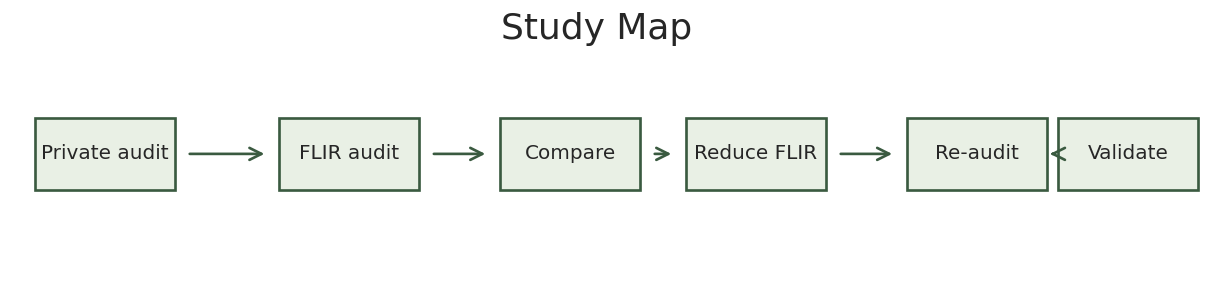

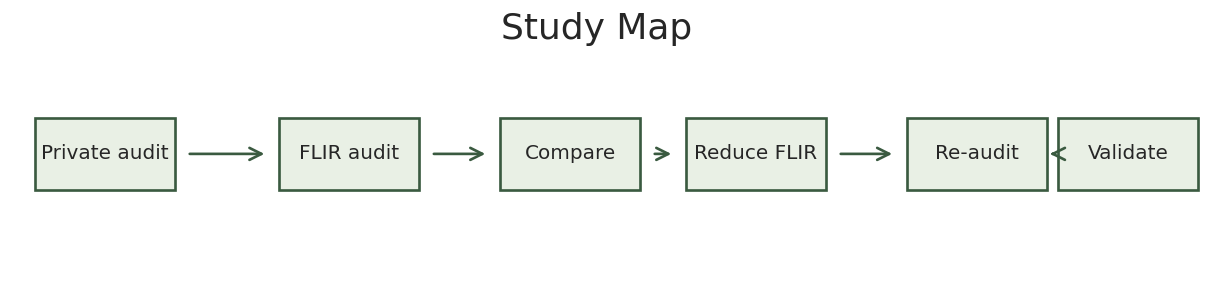

In [2]:
study_flow_fig = plot_study_flow()
save_figure(study_flow_fig, "study_flow")
study_flow_fig


## 2. Dataset Definitions and Canonical Schema

The local schemas differ:

- `v18` stores thermal frames as `.npy` arrays plus COCO-style `annotations.json`.
- FLIR stores thermal frames as grayscale JPEGs under `data/` plus `coco.json` and `index.json`.

The notebook therefore canonicalizes both sources into:

- one **image-level table**,
- one **annotation-level table**,
- and one **person slice** shared across the comparisons.

Local FLIR caveat:

- the raw `coco.json` carries the full 80 COCO category ids,
- but only a small active subset is populated in the thermal annotations,
- and this local export contains a few `deer` instances in addition to the 15 categories advertised on the Teledyne FLIR dataset page.


In [3]:
schema_table = pd.DataFrame(
    [
        {"table": "image", "field": "image_id", "unit": "string/int", "normalization": "none", "scope": "all datasets"},
        {"table": "image", "field": "split", "unit": "categorical", "normalization": "none", "scope": "all datasets"},
        {"table": "image", "field": "source_dataset", "unit": "categorical", "normalization": "none", "scope": "all datasets"},
        {"table": "image", "field": "camera_id", "unit": "categorical", "normalization": "none", "scope": "if derivable from file names"},
        {"table": "image", "field": "scene_id", "unit": "categorical", "normalization": "none", "scope": "if available"},
        {"table": "image", "field": "sequence_id / video_id", "unit": "categorical", "normalization": "none", "scope": "sequence-aware diagnostics"},
        {"table": "image", "field": "width, height", "unit": "pixels", "normalization": "none", "scope": "all datasets"},
        {"table": "annotation", "field": "bbox [x, y, w, h]", "unit": "pixels", "normalization": "COCO raw box", "scope": "all datasets"},
        {"table": "annotation", "field": "center_x_norm, center_y_norm", "unit": "[0, 1]", "normalization": "image-normalized", "scope": "all datasets"},
        {"table": "annotation", "field": "bbox_w_norm, bbox_h_norm", "unit": "[0, 1]", "normalization": "image-normalized", "scope": "all datasets"},
        {"table": "annotation", "field": "area_ratio", "unit": "[0, 1]", "normalization": "box area / image area", "scope": "all datasets"},
        {"table": "annotation", "field": "aspect_ratio", "unit": "w / h", "normalization": "none", "scope": "all datasets"},
        {"table": "slice", "field": "person slice", "unit": "subset", "normalization": "canonical_label == person", "scope": "transfer comparison"},
        {"table": "slice", "field": "global slice", "unit": "subset", "normalization": "all active labels", "scope": "FLIR benchmarking comparison"},
    ]
)
save_table(schema_table, "canonical_schema")
schema_table


,table,field,unit,normalization,scope
0,image,image_id,string/int,none,all datasets
1,image,split,categorical,none,all datasets
2,image,source_dataset,categorical,none,all datasets
3,image,camera_id,categorical,none,if derivable from file names
4,image,scene_id,categorical,none,if available
5,image,sequence_id / video_id,categorical,none,sequence-aware diagnostics
6,image,"width, height",pixels,none,all datasets
7,annotation,"bbox [x, y, w, h]",pixels,COCO raw box,all datasets
8,annotation,"center_x_norm, center_y_norm","[0, 1]",image-normalized,all datasets
9,annotation,"bbox_w_norm, bbox_h_norm","[0, 1]",image-normalized,all datasets


In [4]:
flir_label_mapping_table = pd.DataFrame(
    [
        {"raw_label": raw_label, "canonical_label": FLIR_CANONICAL_LABELS.get(raw_label, raw_label)}
        for raw_label in sorted(FLIR_CANONICAL_LABELS.keys())
    ]
).sort_values(["canonical_label", "raw_label"]).reset_index(drop=True)
save_table(flir_label_mapping_table, "flir_label_mapping")
flir_label_mapping_table


,raw_label,canonical_label
0,bike,bike
1,bus,bus
2,car,car
3,deer,deer
4,dog,dog
5,hydrant,fire hydrant
6,motor,motorcycle
7,other vehicle,other vehicle
8,person,person
9,scooter,scooter


In [5]:
display(Markdown("**Private layout inspection**"))
PRIVATE_LAYOUT_DF


**Private layout inspection**

,split,split_dir,split_exists,annotation_exists,npy_files,images_in_json,annotations,categories,matched_local_files,missing_local_files
0,train,/projets/Fbassignana/diffusers_try/flow_matchi...,True,True,6725,6725,16822,1,6725,0
1,val,/projets/Fbassignana/diffusers_try/flow_matchi...,True,True,188,2289,5947,1,188,2101
2,test,/projets/Fbassignana/diffusers_try/flow_matchi...,True,True,799,799,2026,1,799,0


In [6]:
display(Markdown("**FLIR layout inspection**"))
FLIR_LAYOUT_DF


**FLIR layout inspection**

,split,split_dir,coco_exists,index_exists,jpg_files,images_in_json,annotations,categories,videos,frames_in_index
0,train,/projets/Fbassignana/diffusers_try/flow_matchi...,True,True,10742,10742,175040,80,133,10742
1,val,/projets/Fbassignana/diffusers_try/flow_matchi...,True,True,1144,1144,16696,80,17,1144
2,test,/projets/Fbassignana/diffusers_try/flow_matchi...,True,True,3749,3749,62317,80,8,3749


## 3. Statistical Notation and Comparison Protocol

Two regimes are tracked throughout:

- **Person-transfer regime**: private vs FLIR person slices.
- **Publication regime**: FLIR original vs FLIR reduced on global multiclass structure.

Distances:

- Wasserstein-1 for 1D continuous distributions,
- Jensen-Shannon divergence for histograms and categorical vectors,
- RBF-MMD for compact multivariate layout comparisons,
- absolute differences for entropy, Gini, and concentration summaries.


In [7]:
statistics_dictionary = pd.DataFrame(
    [
        {"symbol": "P(N_person)", "definition": "person count per image", "scope": "person-transfer", "why_it_matters": "crowding and target occupancy", "distance": "JS divergence"},
        {"symbol": "A_person", "definition": "person bbox area ratio", "scope": "person-transfer", "why_it_matters": "scale support and target size", "distance": "Wasserstein-1"},
        {"symbol": "R_person", "definition": "person bbox aspect ratio", "scope": "person-transfer", "why_it_matters": "shape prior and annotation style", "distance": "Wasserstein-1"},
        {"symbol": "(x_c, y_c)", "definition": "normalized person center", "scope": "person-transfer", "why_it_matters": "camera viewpoint and framing bias", "distance": "2D JS divergence"},
        {"symbol": "(y_c, log h)", "definition": "vertical position / scale joint distribution", "scope": "person-transfer", "why_it_matters": "perspective and surveillance geometry", "distance": "2D JS divergence"},
        {"symbol": "d_NN", "definition": "mean nearest-neighbor person distance", "scope": "person-transfer", "why_it_matters": "crowding and clutter", "distance": "Wasserstein-1"},
        {"symbol": "IoU_pair", "definition": "pairwise person IoU", "scope": "person-transfer", "why_it_matters": "overlap and occlusion behavior", "distance": "Wasserstein-1"},
        {"symbol": "MMD_layout", "definition": "multivariate person-pair layout score", "scope": "person-transfer", "why_it_matters": "joint geometry, not just marginals", "distance": "RBF-MMD"},
        {"symbol": "H_scene", "definition": "scene entropy", "scope": "repetition", "why_it_matters": "effective diversity and bias concentration", "distance": "absolute difference"},
        {"symbol": "JS_class", "definition": "class-frequency divergence", "scope": "publication", "why_it_matters": "multiclass preservation", "distance": "JS divergence"},
        {"symbol": "G_class", "definition": "Gini coefficient of class counts", "scope": "publication", "why_it_matters": "long-tail preservation", "distance": "absolute difference"},
    ]
)
save_table(statistics_dictionary, "statistics_dictionary")
statistics_dictionary


,symbol,definition,scope,why_it_matters,distance
0,P(N_person),person count per image,person-transfer,crowding and target occupancy,JS divergence
1,A_person,person bbox area ratio,person-transfer,scale support and target size,Wasserstein-1
2,R_person,person bbox aspect ratio,person-transfer,shape prior and annotation style,Wasserstein-1
3,"(x_c, y_c)",normalized person center,person-transfer,camera viewpoint and framing bias,2D JS divergence
4,"(y_c, log h)",vertical position / scale joint distribution,person-transfer,perspective and surveillance geometry,2D JS divergence
5,d_NN,mean nearest-neighbor person distance,person-transfer,crowding and clutter,Wasserstein-1
6,IoU_pair,pairwise person IoU,person-transfer,overlap and occlusion behavior,Wasserstein-1
7,MMD_layout,multivariate person-pair layout score,person-transfer,"joint geometry, not just marginals",RBF-MMD
8,H_scene,scene entropy,repetition,effective diversity and bias concentration,absolute difference
9,JS_class,class-frequency divergence,publication,multiclass preservation,JS divergence


## 4. Private Dataset Audit

The private target domain is operationalized as the local `v18/train` split for the main transfer target, with optional split sanity checks against the locally available `val` and `test` metadata.


In [8]:
PRIVATE_ALL_IMAGES, PRIVATE_CATEGORY_TABLE, PRIVATE_ALL_ANNOTATIONS = load_all_v18(
    PRIVATE_AUDIT_SPLITS,
    keep_local_only=True,
)

PRIVATE_MAIN_IMAGES = PRIVATE_ALL_IMAGES[PRIVATE_ALL_IMAGES["split"] == PRIVATE_TARGET_SPLIT].copy()
PRIVATE_MAIN_ANNOTATIONS = PRIVATE_ALL_ANNOTATIONS[
    PRIVATE_ALL_ANNOTATIONS["image_id"].isin(PRIVATE_MAIN_IMAGES["image_id"])
].copy()

PRIVATE_MAIN_IMAGES["ahash_cluster"] = maybe_compute_ahash(PRIVATE_MAIN_IMAGES, loader_kind="v18", cache_name="private_train")
PRIVATE_ALL_IMAGES = PRIVATE_ALL_IMAGES.merge(
    PRIVATE_MAIN_IMAGES[["image_id", "ahash_cluster"]],
    on="image_id",
    how="left",
)
PRIVATE_PROFILE = profile_dataset("private_train", PRIVATE_MAIN_IMAGES, PRIVATE_MAIN_ANNOTATIONS)

PRIVATE_PROFILE["inventory"]


,dataset,images,annotations,person_annotations,mean_annotations_per_image,mean_persons_per_image,scene_units,camera_units,sequence_units
0,private_train,6725,16822,16822,2.501413,2.501413,6085,37,6085


In [9]:
display(Markdown("**Private split sanity summary**"))
PRIVATE_ALL_PROFILE = profile_dataset("private_all_local", PRIVATE_ALL_IMAGES, PRIVATE_ALL_ANNOTATIONS)
PRIVATE_ALL_PROFILE["split_summary"]


**Private split sanity summary**

,split,images,annotations,person_annotations,mean_person_count,median_person_area_ratio,scene_units,scene_top_1_share
0,train,6725,16822,16822,2.503646,0.030978,6085,0.000595
1,val,188,437,437,2.324468,0.035079,176,0.021277
2,test,799,2026,2026,2.542033,0.030561,785,0.002503


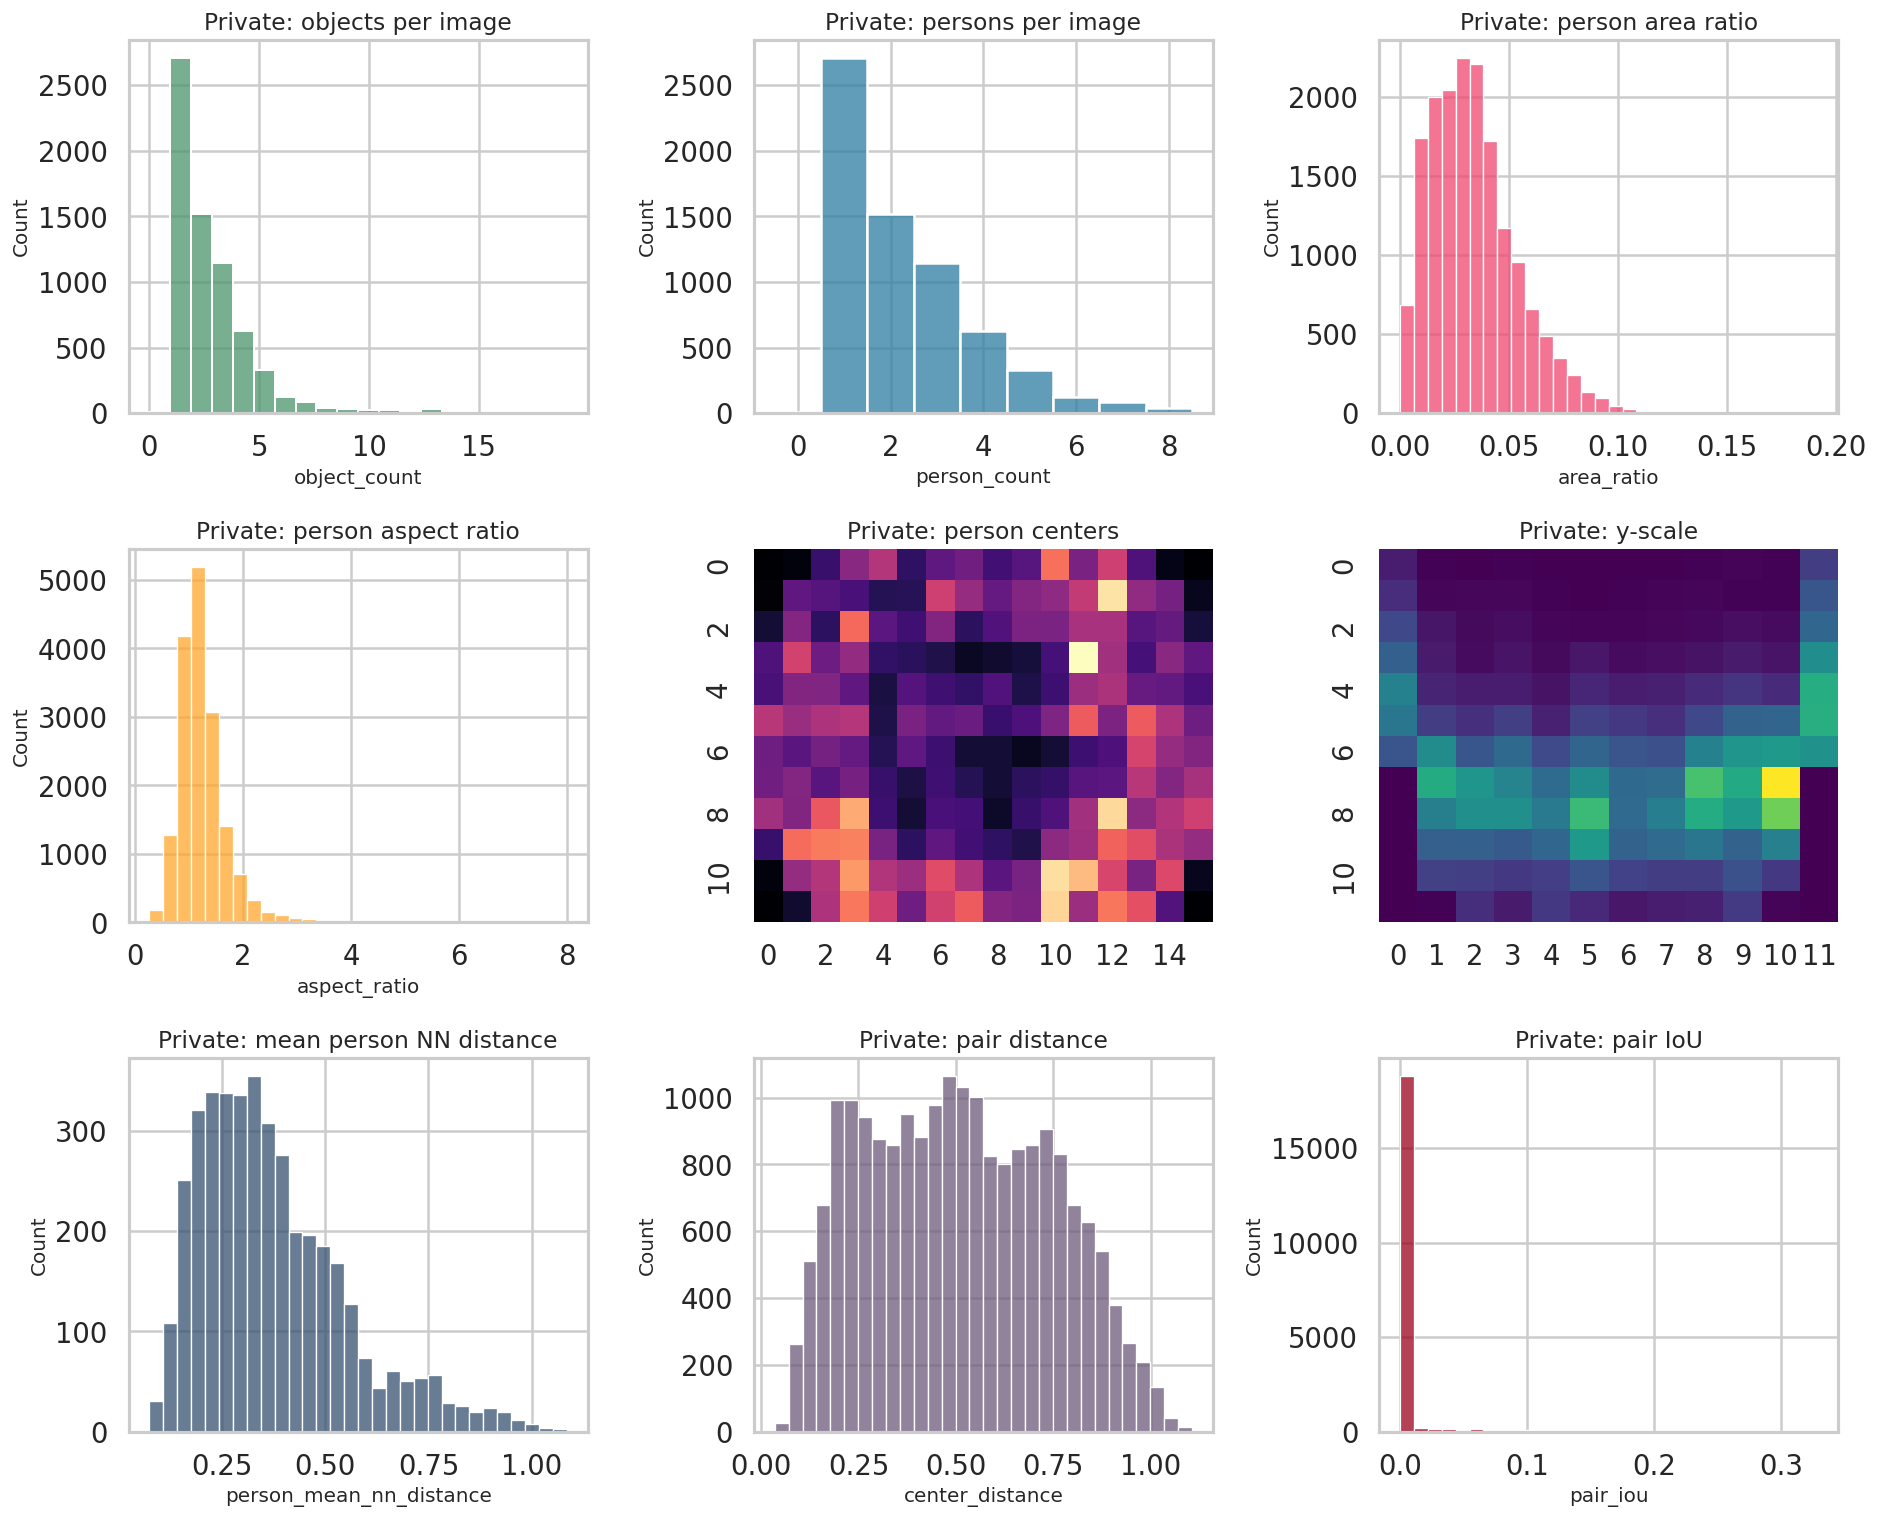

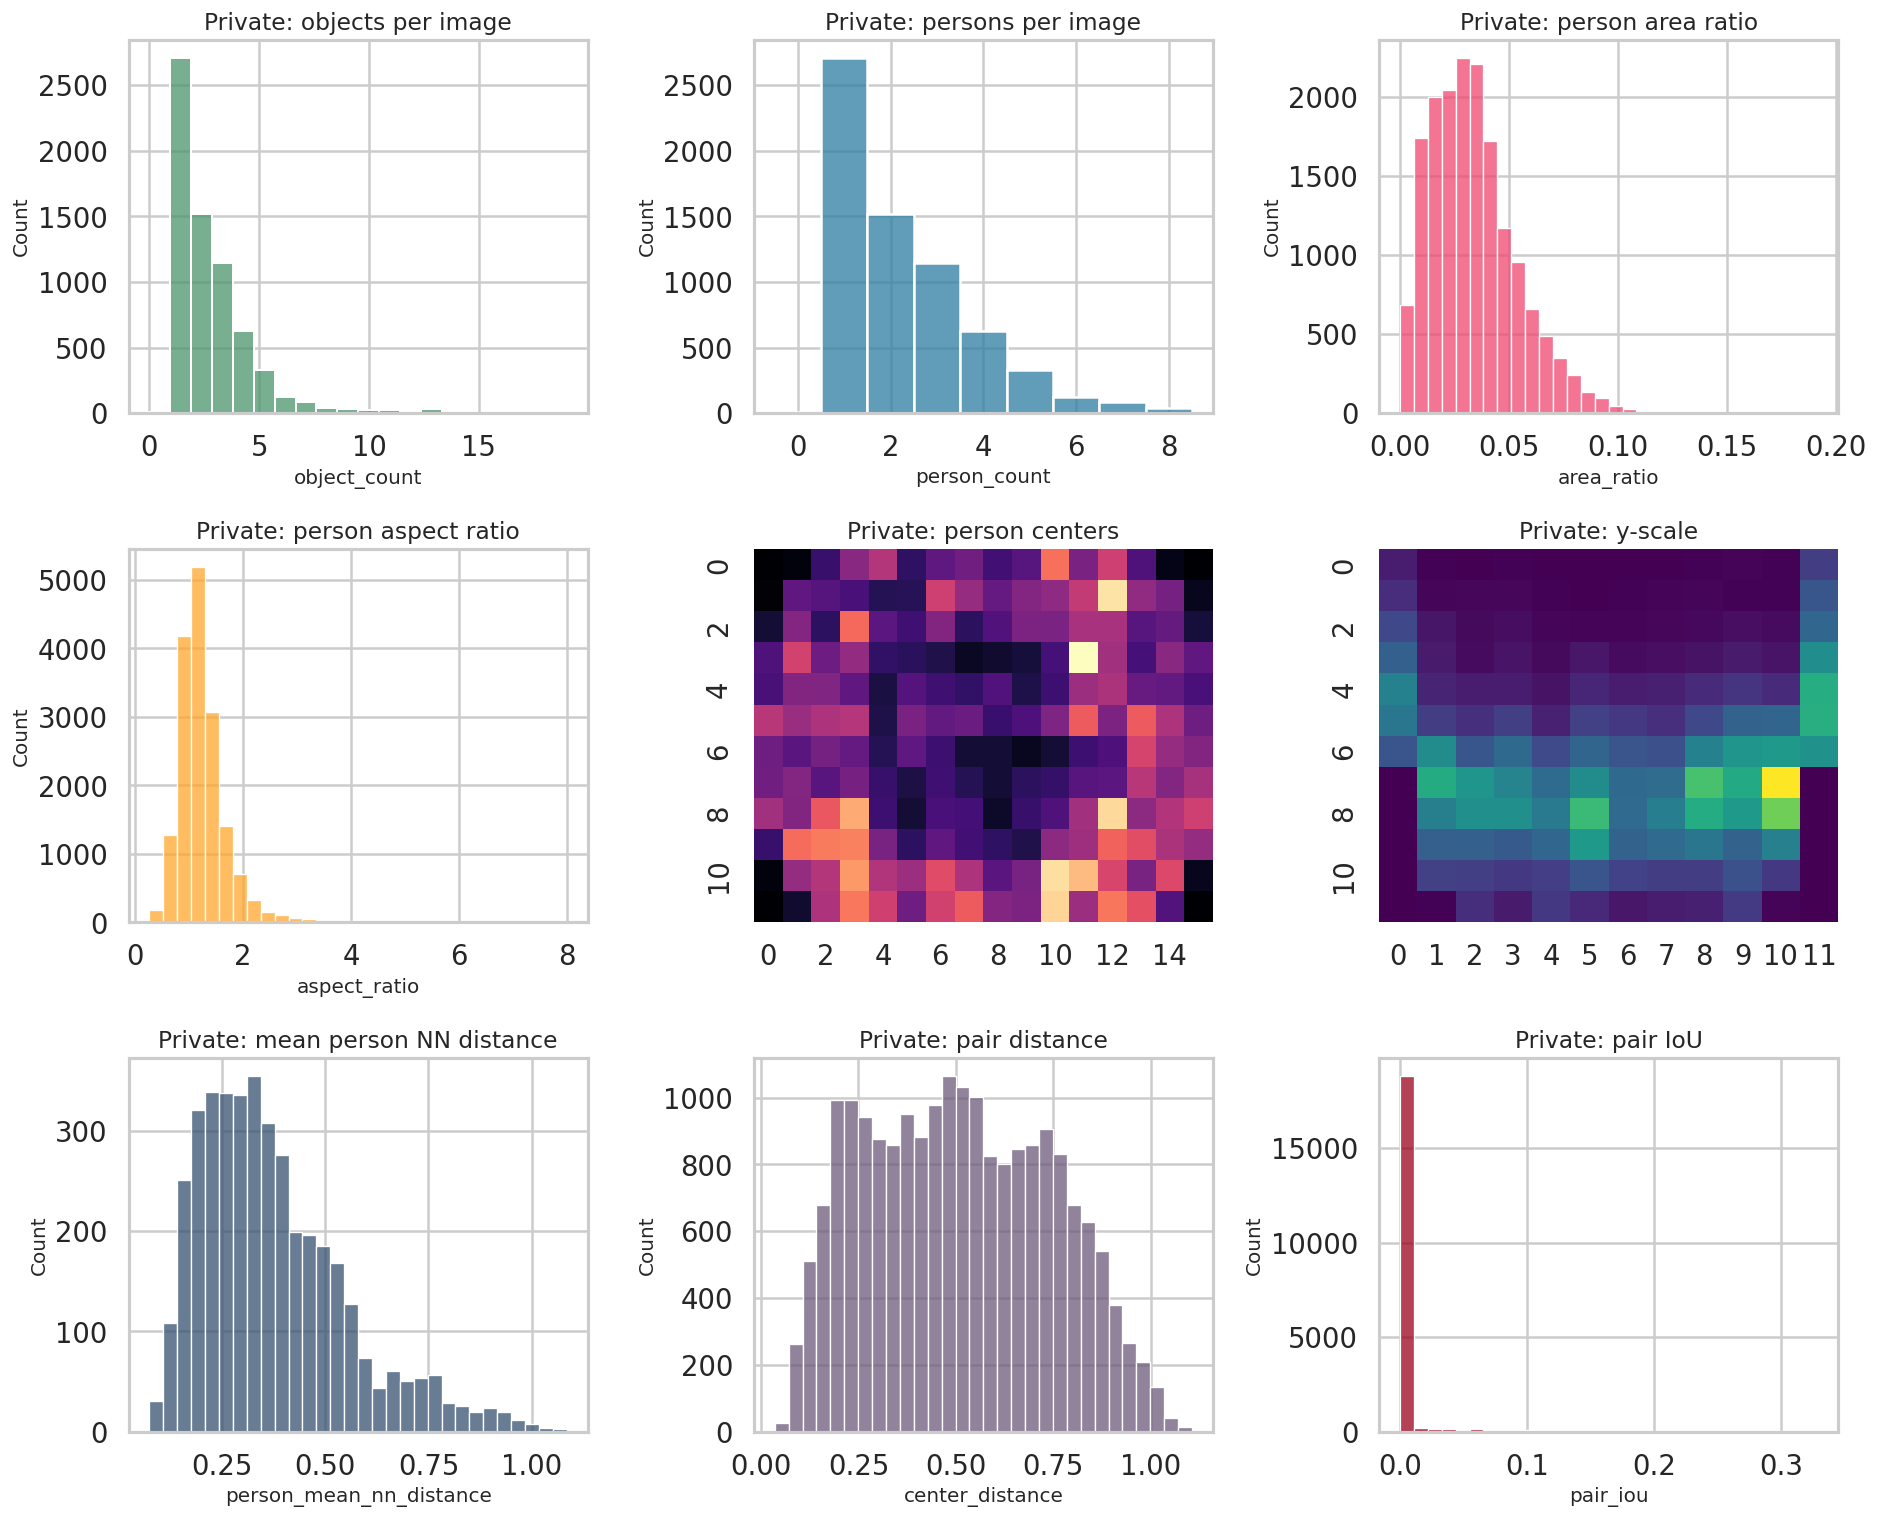

In [10]:
private_person_audit_fig = plot_person_audit(PRIVATE_PROFILE, "Private")
save_figure(private_person_audit_fig, "private_person_audit")
private_person_audit_fig


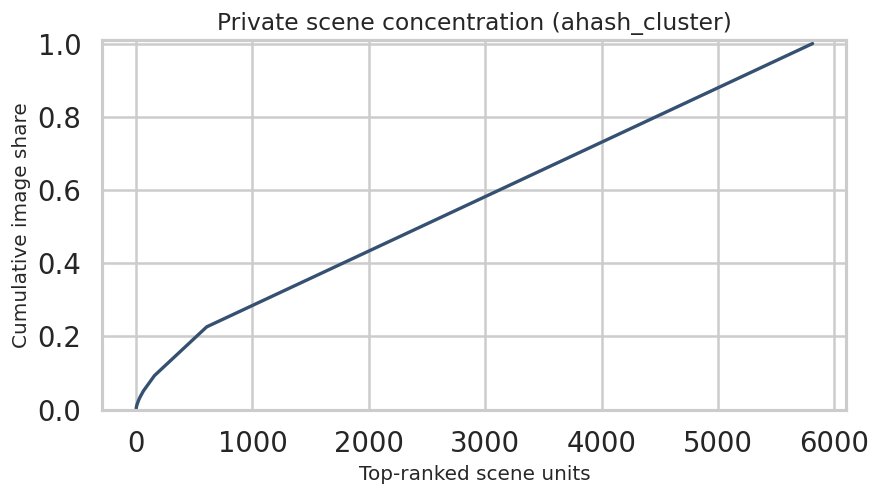

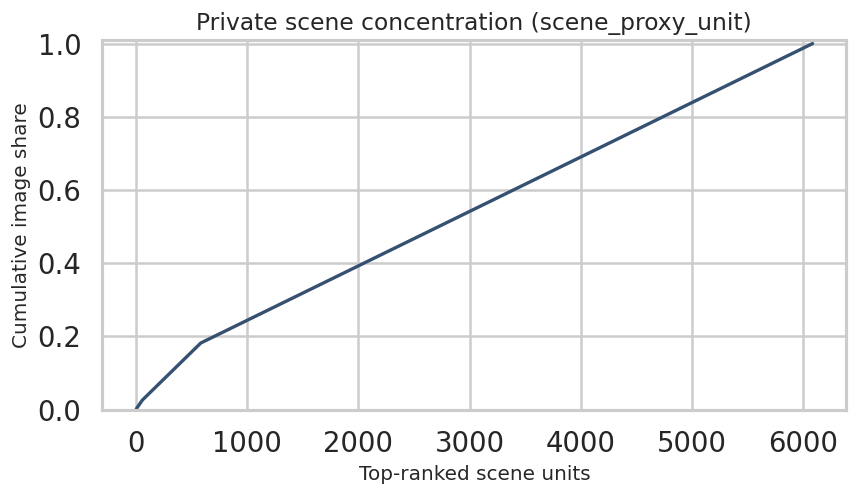

In [11]:
private_scene_fig = plot_scene_concentration(PRIVATE_PROFILE["images"], "ahash_cluster", "Private scene concentration (ahash_cluster)")
private_scene_fig = plot_scene_concentration(PRIVATE_PROFILE["images"], "scene_proxy_unit", "Private scene concentration (scene_proxy_unit)")
save_figure(private_scene_fig, "private_scene_concentration")



In [12]:
private_inventory_table = pd.concat(
    [PRIVATE_PROFILE["inventory"], PRIVATE_PROFILE["scene_summary"], PRIVATE_PROFILE["perceptual_summary"]],
    axis=1,
)
save_table(private_inventory_table, "private_inventory_summary")
private_inventory_table


,dataset,images,annotations,person_annotations,mean_annotations_per_image,mean_persons_per_image,scene_units,camera_units,sequence_units,scene_col,...,scene_entropy,effective_scene_count,top_1_share,top_5_share,scene_col,n_scenes,scene_entropy,effective_scene_count,top_1_share,top_5_share
0,private_train,6725,16822,16822,2.501413,2.501413,6085,37,6085,scene_proxy_unit,...,12.517812,5864.577856,0.000595,0.002974,ahash_cluster,5813,12.385881,5352.070217,0.002825,0.009814


### Private audit notes

- `v18/train` is fully matched on disk: every image listed in `annotations.json` exists locally.
- `v18/val` is only partially present locally in this workspace, so split-sanity tables should be interpreted with that caveat.
- File names expose a sequence structure and a camera-like identifier, which gives the notebook a usable repetition proxy without needing extra metadata files.


## 5. Original FLIR Dataset Audit

The FLIR thermal dataset is loaded from:

- `images_thermal_train`
- `images_thermal_val`
- `video_thermal_test`

The local export uses thermal grayscale JPEGs plus COCO annotations. The public FLIR dataset page describes thermal JPEGs, MSCOCO annotations, and 15 advertised categories, but the local raw JSON is treated as the source of truth for active labels and support counts.


In [13]:
PRIVATE_CONSTRAINTS = derive_private_constraints(PRIVATE_PROFILE)

FLIR_ALL_IMAGES, FLIR_CATEGORY_TABLE, FLIR_ALL_ANNOTATIONS = load_all_flir(
    FLIR_SPLIT_DIRS,
    scene_chunk_size=PRIVATE_CONSTRAINTS["scene_chunk_size"],
)
FLIR_ALL_IMAGES["ahash_cluster"] = maybe_compute_ahash(FLIR_ALL_IMAGES, loader_kind="flir", cache_name="flir_all")
FLIR_PROFILE = profile_dataset("flir_original", FLIR_ALL_IMAGES, FLIR_ALL_ANNOTATIONS)

FLIR_PROFILE["inventory"]


,dataset,images,annotations,person_annotations,mean_annotations_per_image,mean_persons_per_image,scene_units,camera_units,sequence_units
0,flir_original,15635,254053,67271,16.248993,4.30259,15635,0,158


In [14]:
display(Markdown("**FLIR active category table**"))
FLIR_CATEGORY_TABLE[FLIR_CATEGORY_TABLE["is_active"]].sort_values("instance_count", ascending=False)


**FLIR active category table**

,category_id,raw_label,supercategory,canonical_label,instance_count,is_active
2,3,car,unknown,car,73623,True
0,1,person,unknown,person,50478,True
11,12,sign,unknown,street sign,20770,True
9,10,light,unknown,traffic light,16198,True
1,2,bike,unknown,bike,7237,True
3,4,motor,unknown,motorcycle,3314,True
7,8,truck,unknown,truck,2634,True
5,6,bus,unknown,bus,2245,True
78,79,other vehicle,unknown,other vehicle,1373,True
10,11,hydrant,unknown,fire hydrant,1095,True


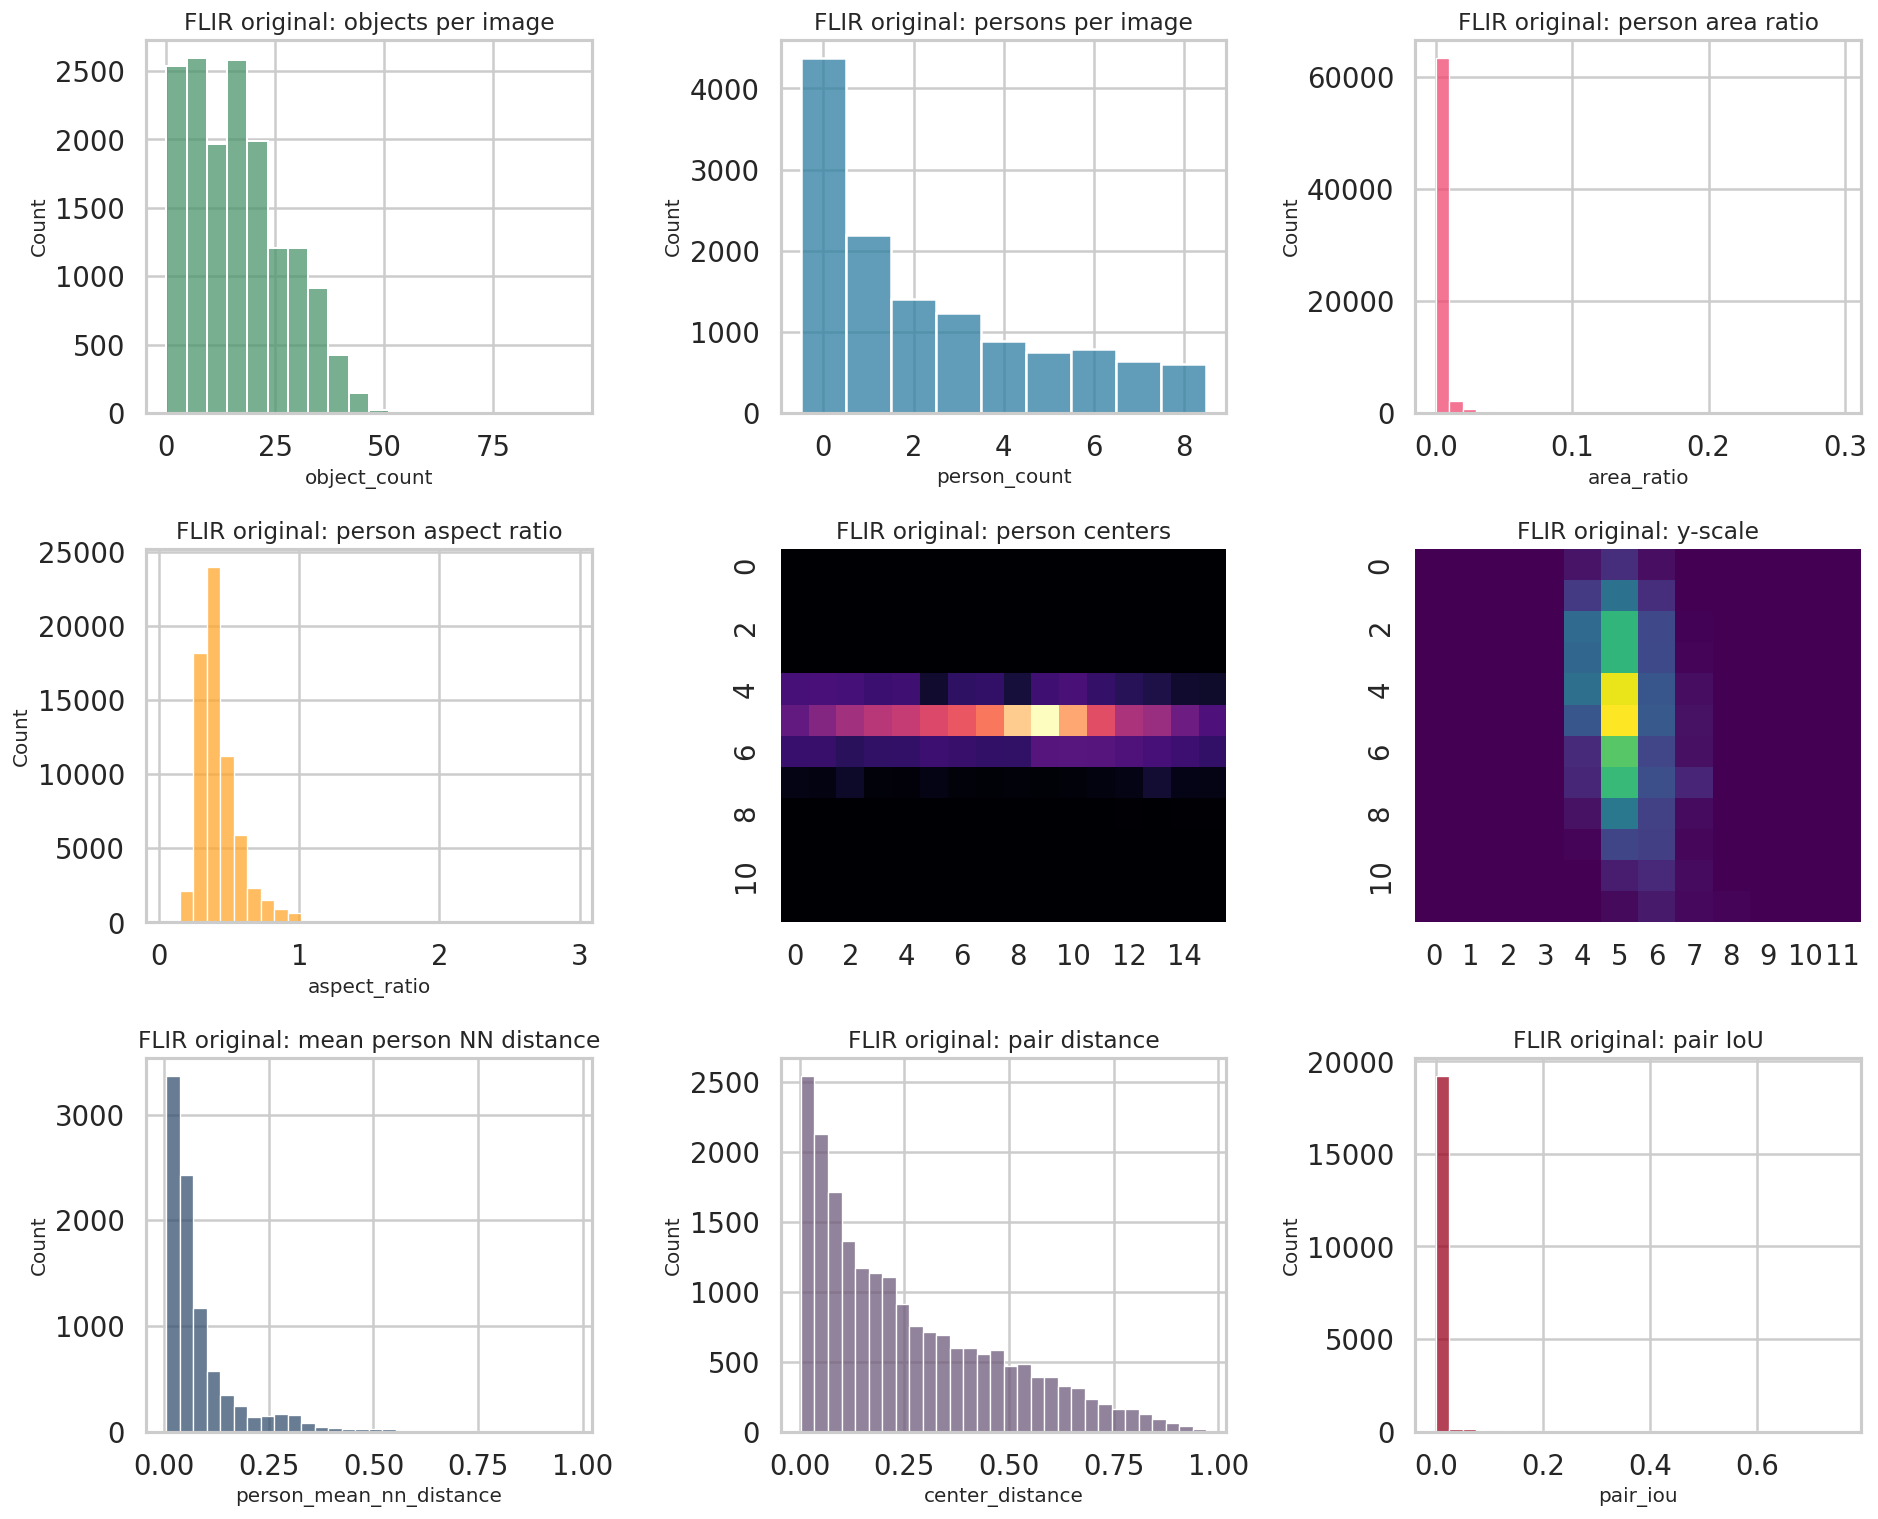

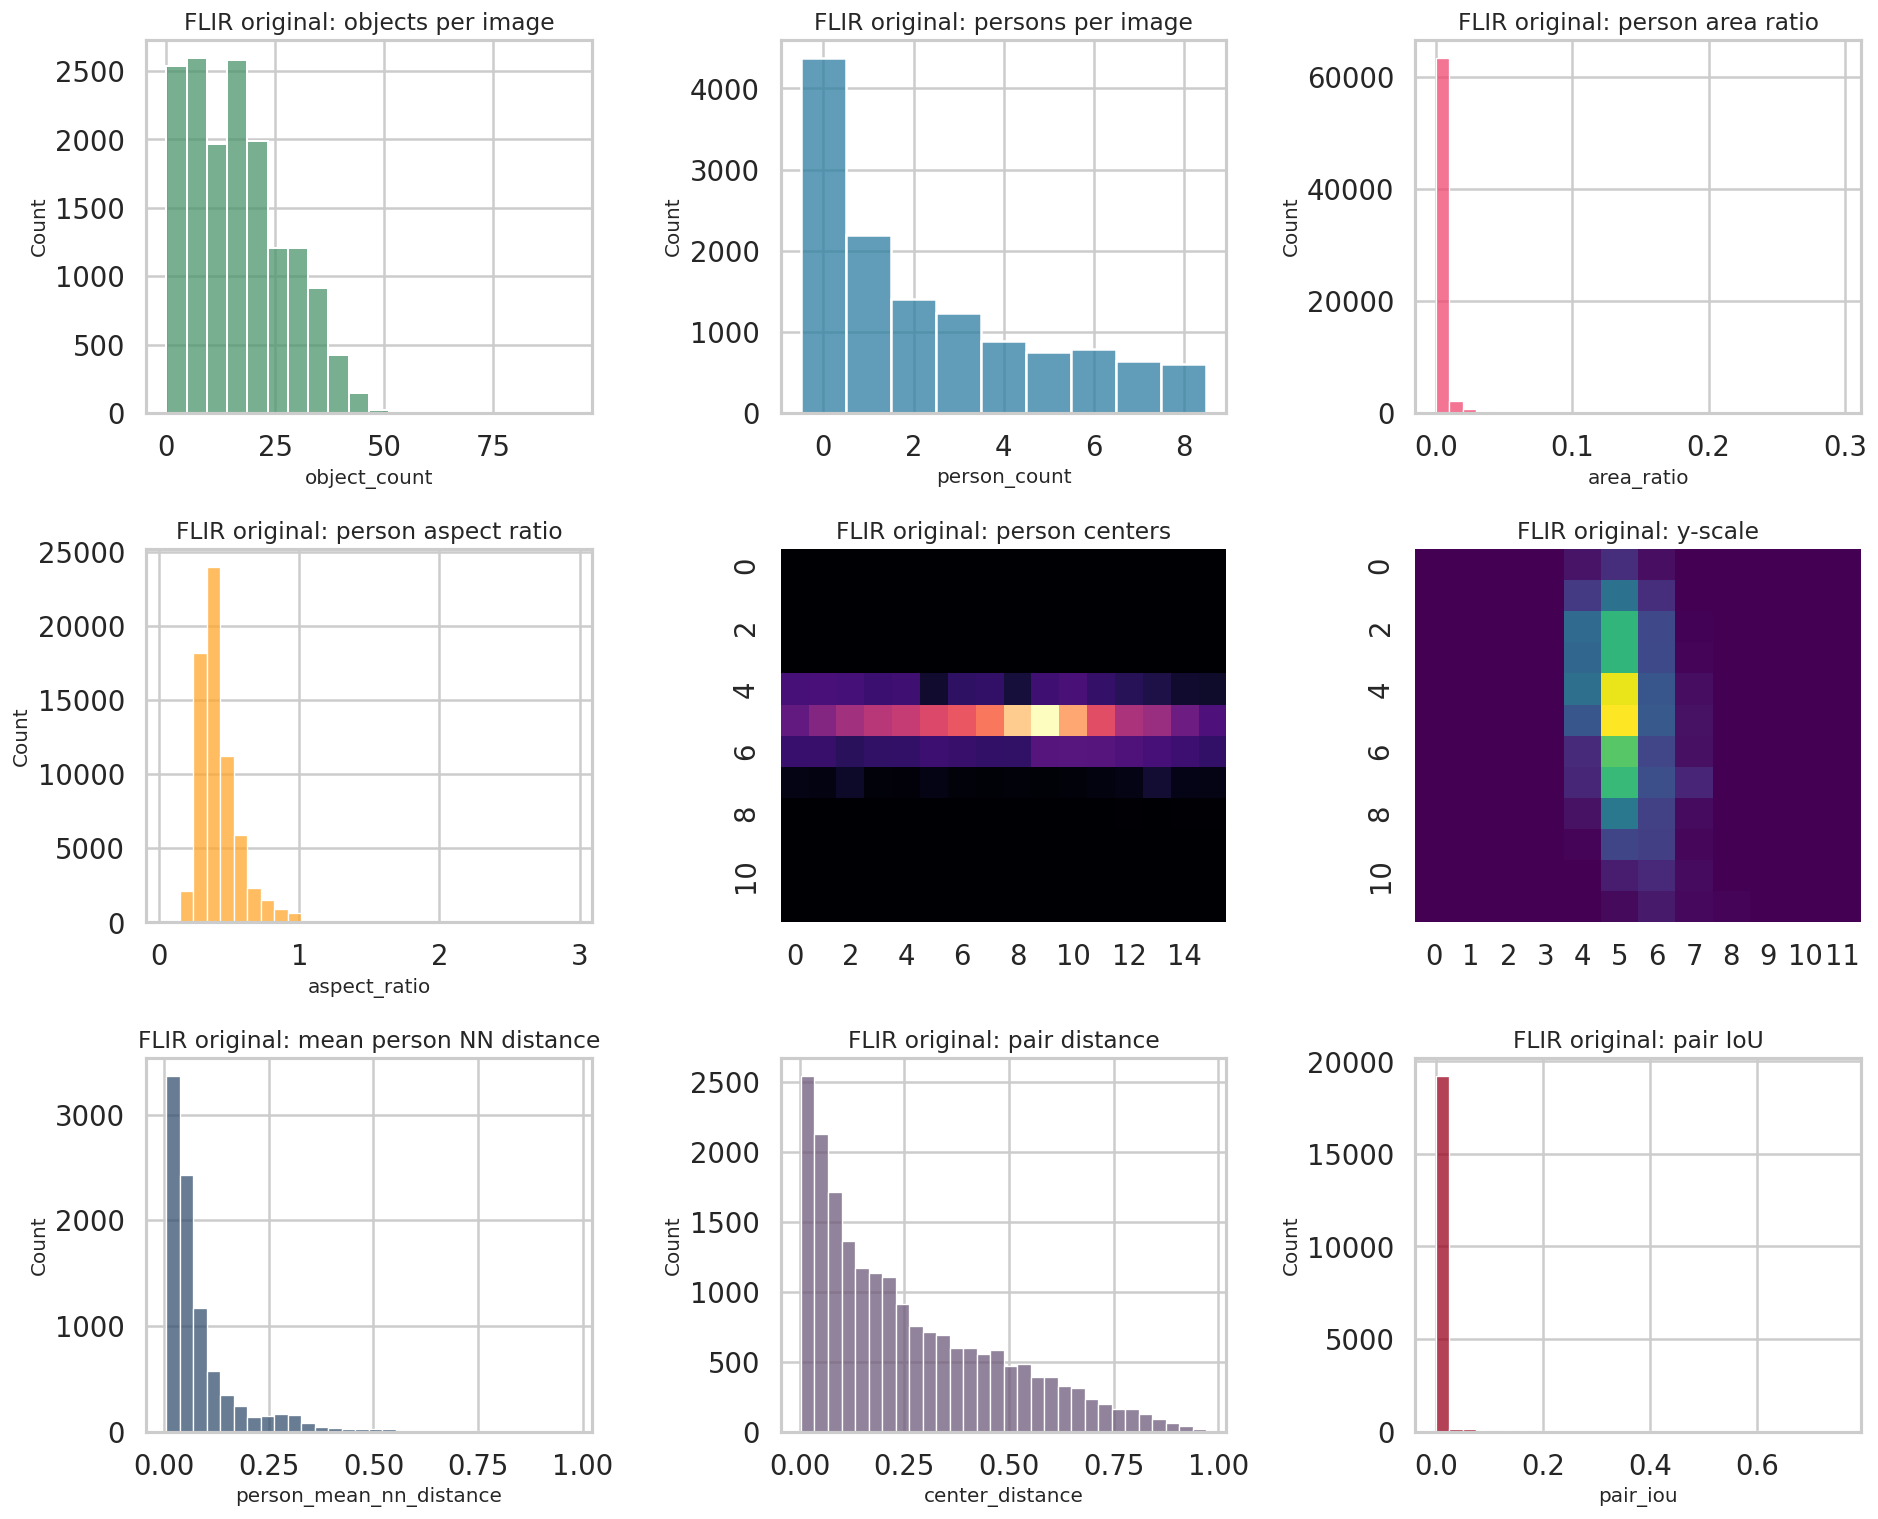

In [15]:
flir_person_audit_fig = plot_person_audit(FLIR_PROFILE, "FLIR original")
save_figure(flir_person_audit_fig, "flir_original_person_audit")
flir_person_audit_fig


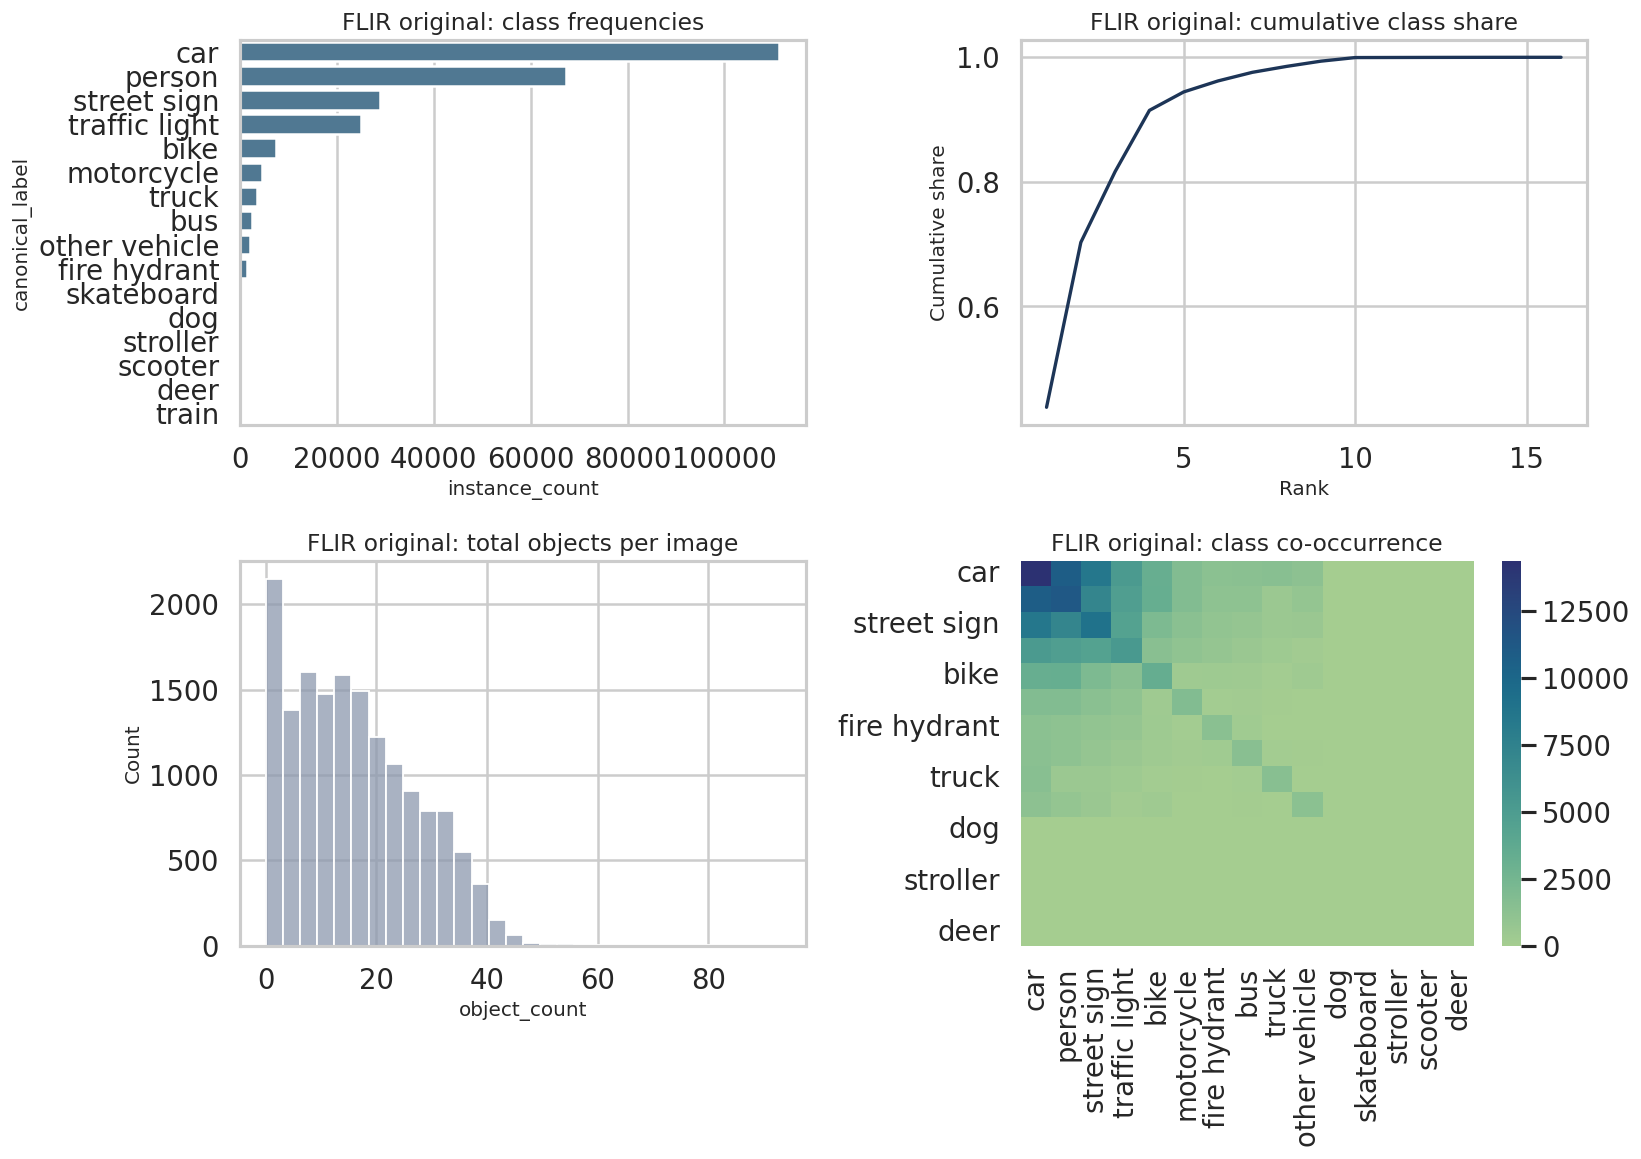

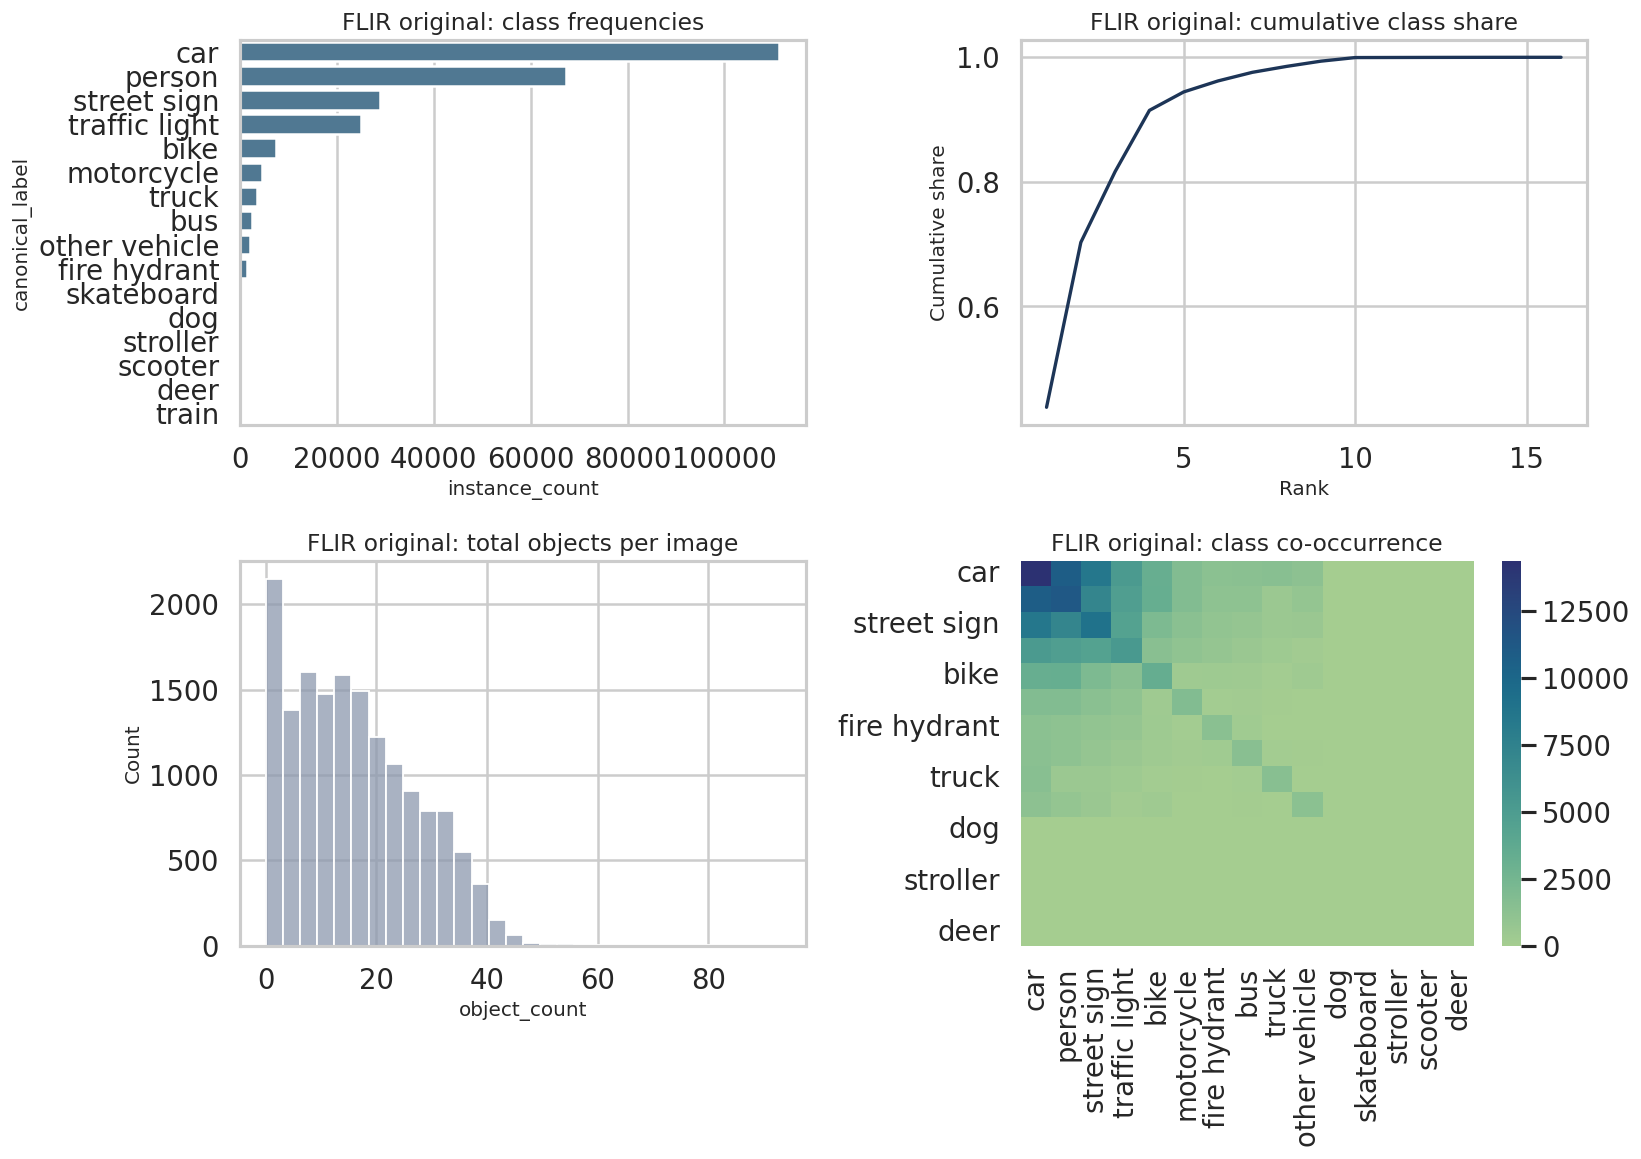

In [16]:
flir_global_audit_fig = plot_flir_global_audit(FLIR_PROFILE, "FLIR original")
save_figure(flir_global_audit_fig, "flir_original_global_audit")
flir_global_audit_fig


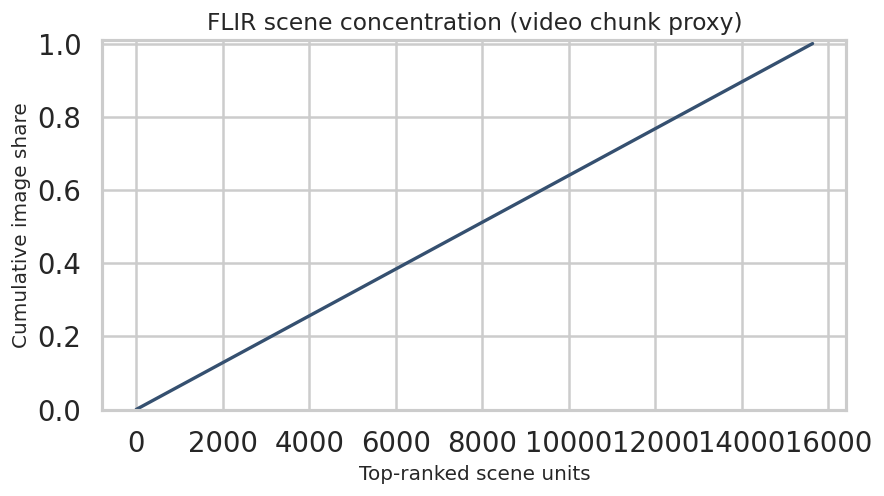

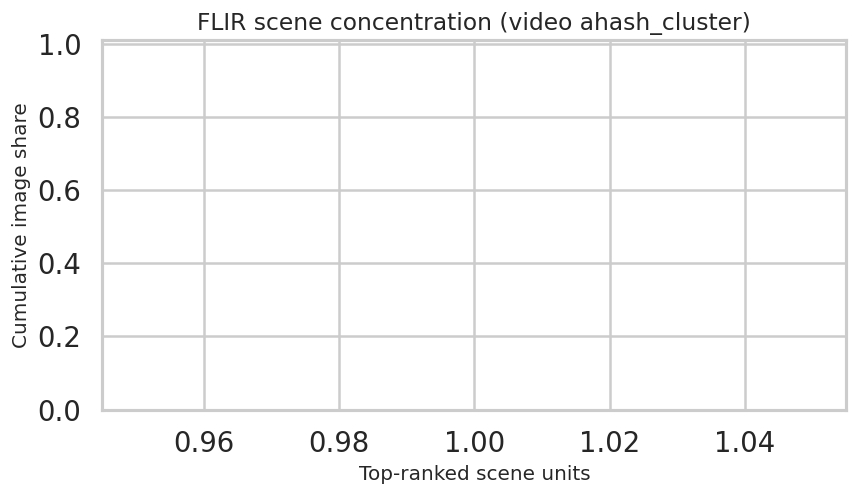

In [17]:
flir_scene_fig = plot_scene_concentration(FLIR_PROFILE["images"], "scene_proxy_unit", "FLIR scene concentration (video chunk proxy)")
flir_scene_fig = plot_scene_concentration(FLIR_PROFILE["images"], "ahash_cluster", "FLIR scene concentration (video ahash_cluster)")
save_figure(flir_scene_fig, "flir_original_scene_concentration")



In [18]:
flir_inventory_table = pd.concat(
    [FLIR_PROFILE["inventory"], FLIR_PROFILE["scene_summary"], FLIR_PROFILE["perceptual_summary"]],
    axis=1,
)
save_table(flir_inventory_table, "flir_original_inventory_summary")
flir_inventory_table


,dataset,images,annotations,person_annotations,mean_annotations_per_image,mean_persons_per_image,scene_units,camera_units,sequence_units,scene_col,...,scene_entropy,effective_scene_count,top_1_share,top_5_share,scene_col,n_scenes,scene_entropy,effective_scene_count,top_1_share,top_5_share
0,flir_original,15635,254053,67271,16.248993,4.30259,15635,0,158,scene_proxy_unit,...,13.932492,15635.0,0.000064,0.00032,ahash_cluster,1,-0.0,1.0,1.0,1.0


## 6. Pre-reduction Cross-Dataset Comparison

This section ranks the mismatches that motivate the reduction stage.


In [19]:
PRIVATE_VS_FLIR_ORIGINAL = compare_profiles(PRIVATE_PROFILE, FLIR_PROFILE, "private_vs_flir_original")
PRIVATE_VS_FLIR_ORIGINAL["rank"] = np.arange(1, len(PRIVATE_VS_FLIR_ORIGINAL) + 1)
PRIVATE_VS_FLIR_ORIGINAL["recommended_reduction_action"] = PRIVATE_VS_FLIR_ORIGINAL["category"].map(
    {
        "counts": "match with scene-aware image selection",
        "geometry": "score images by private person support",
        "crowding": "soft-match during subset refinement",
        "layout": "retain but improve, do not overfit",
        "repetition": "match by sequence/video chunk concentration",
        "multiclass": "preserve rather than collapse",
    }
)
save_table(PRIVATE_VS_FLIR_ORIGINAL, "private_vs_flir_original_comparison")
PRIVATE_VS_FLIR_ORIGINAL


,comparison,statistic,category,metric,distance,importance,rank,recommended_reduction_action
0,private_vs_flir_original,class_entropy,multiclass,absolute_difference,2.224064,preserve,1,preserve rather than collapse
1,private_vs_flir_original,scene_entropy,repetition,absolute_difference,1.414680,hard-match,2,match by sequence/video chunk concentration
2,private_vs_flir_original,person_aspect_ratio,geometry,wasserstein_1,0.828511,hard-match,3,score images by private person support
3,private_vs_flir_original,person_y_logh_distribution,geometry,js_divergence_2d,0.817791,hard-match,4,score images by private person support
4,private_vs_flir_original,class_gini,multiclass,absolute_difference,0.779065,preserve,5,preserve rather than collapse
5,private_vs_flir_original,person_center_distribution,geometry,js_divergence_2d,0.561496,hard-match,6,score images by private person support
6,private_vs_flir_original,class_frequency,multiclass,js_divergence,0.531870,preserve,7,preserve rather than collapse
7,private_vs_flir_original,person_count_per_image,counts,js_divergence,0.292803,hard-match,8,match with scene-aware image selection
8,private_vs_flir_original,person_mean_nn_distance,crowding,wasserstein_1,0.284627,soft-match,9,soft-match during subset refinement
9,private_vs_flir_original,pairwise_person_distance,layout,wasserstein_1,0.250714,soft-match,10,"retain but improve, do not overfit"


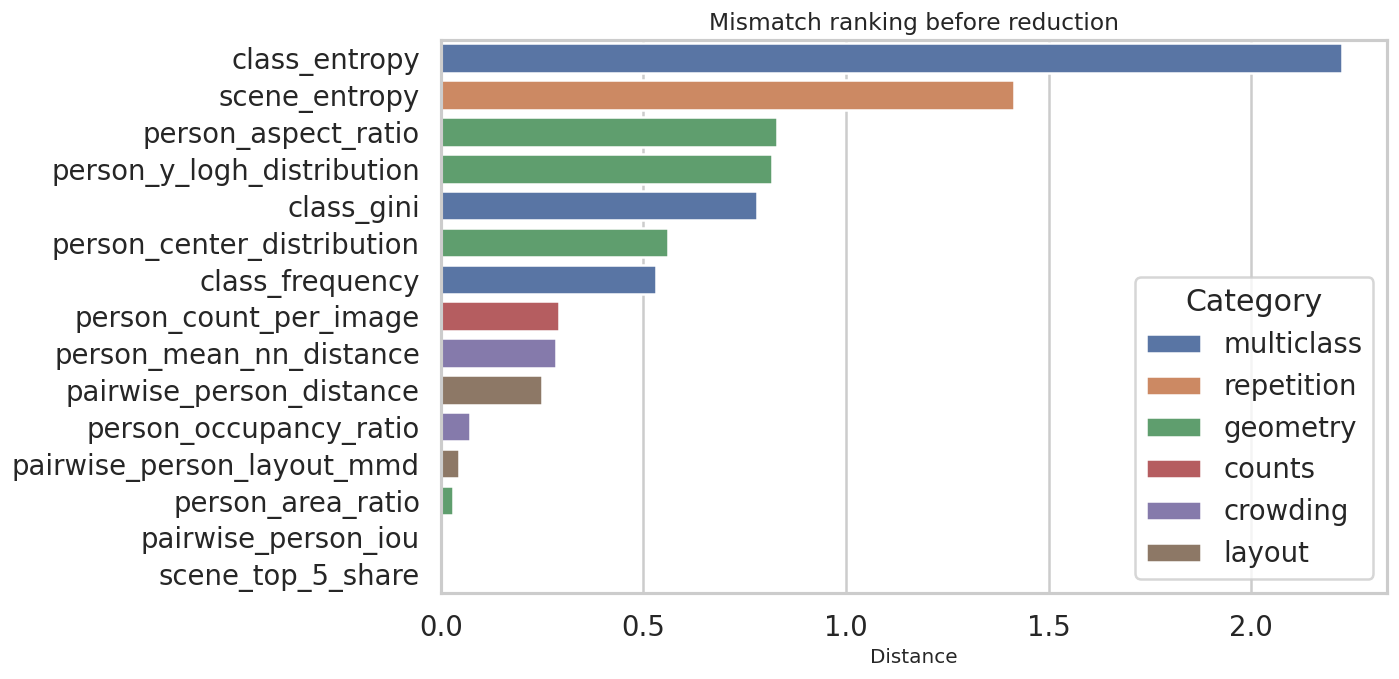

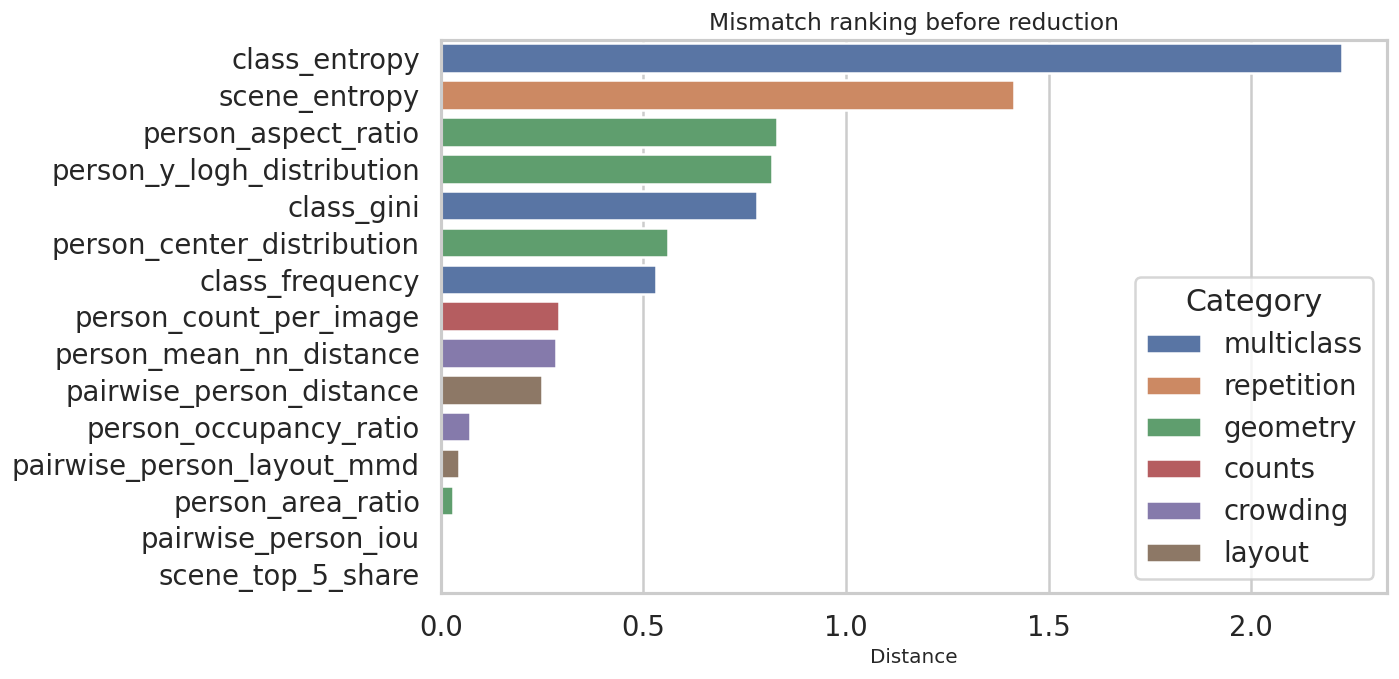

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=PRIVATE_VS_FLIR_ORIGINAL.sort_values("distance", ascending=False),
    x="distance",
    y="statistic",
    hue="category",
    dodge=False,
    ax=ax,
)
ax.set_title("Mismatch ranking before reduction")
ax.set_xlabel("Distance")
ax.set_ylabel("")
ax.legend(title="Category", loc="lower right")
fig.tight_layout()
save_figure(fig, "pre_reduction_mismatch_ranking")
fig


## 7. Reduction Target Definition

The reduction targets below follow three roles:

- **hard-match**: person-count structure, person geometry, person center occupancy, repetition concentration,
- **soft-match**: person-pair layouts and crowding,
- **relaxed**: exact private class structure or removal of FLIR auxiliary classes.


In [21]:
constraint_table_seed = pd.DataFrame(
    [
        {"statistic": "person_count_per_image", "role": "hard-match", "target_form": "reduce mismatch to private", "tolerance": "must improve over original FLIR", "reason": "count prior matters for transfer"},
        {"statistic": "person_center_distribution", "role": "hard-match", "target_form": "reduce 2D JS to private", "tolerance": "must improve over original FLIR", "reason": "camera framing bias"},
        {"statistic": "person_y_logh_distribution", "role": "hard-match", "target_form": "reduce 2D JS to private", "tolerance": "must improve over original FLIR", "reason": "viewpoint and scale coupling"},
        {"statistic": "person_aspect_ratio", "role": "hard-match", "target_form": "reduce W1 to private", "tolerance": "must improve over original FLIR", "reason": "shape prior"},
        {"statistic": "scene_top_5_share", "role": "hard-match", "target_form": "move toward private repetition concentration", "tolerance": "must improve over original FLIR", "reason": "repetition realism"},
        {"statistic": "pairwise_person_layout_mmd", "role": "soft-match", "target_form": "improve without overfitting", "tolerance": "directional improvement", "reason": "layout should remain benchmark-like"},
        {"statistic": "class_frequency", "role": "relaxed", "target_form": "keep meaningful multiclass support", "tolerance": "do not collapse to person-only", "reason": "publication value"},
        {"statistic": "class_gini", "role": "preserve", "target_form": "retain measurable long-tail imbalance", "tolerance": "avoid flattening", "reason": "non-trivial benchmark difficulty"},
    ]
)
save_table(constraint_table_seed, "reduction_target_definition_seed")
constraint_table_seed


,statistic,role,target_form,tolerance,reason
0,person_count_per_image,hard-match,reduce mismatch to private,must improve over original FLIR,count prior matters for transfer
1,person_center_distribution,hard-match,reduce 2D JS to private,must improve over original FLIR,camera framing bias
2,person_y_logh_distribution,hard-match,reduce 2D JS to private,must improve over original FLIR,viewpoint and scale coupling
3,person_aspect_ratio,hard-match,reduce W1 to private,must improve over original FLIR,shape prior
4,scene_top_5_share,hard-match,move toward private repetition concentration,must improve over original FLIR,repetition realism
5,pairwise_person_layout_mmd,soft-match,improve without overfitting,directional improvement,layout should remain benchmark-like
6,class_frequency,relaxed,keep meaningful multiclass support,do not collapse to person-only,publication value
7,class_gini,preserve,retain measurable long-tail imbalance,avoid flattening,non-trivial benchmark difficulty


## 8. Reduced FLIR Construction

Construction stages when `USE_ALL_FLIR_IMAGES_FOR_EXPORT = False`:

1. score every FLIR image against the private person-centric envelope,
2. keep a candidate pool that stays inside the hard-support region or contributes rare auxiliary structure,
3. select scene-aware FLIR chunks to approach the private statistics,
4. repair missing auxiliary-class support if the first pass undershoots it,
5. export manifests and split-wise COCO subsets for later experiments.

If `USE_ALL_FLIR_IMAGES_FOR_EXPORT = True`, the notebook skips reduction and exports
all split-pure FLIR train/val/test images directly.


In [22]:
REDUCED_FLIR_BUNDLE = build_flir_export_bundle(
    FLIR_PROFILE,
    PRIVATE_CONSTRAINTS,
    use_all_images=USE_ALL_FLIR_IMAGES_FOR_EXPORT,
)
REDUCED_EXPORTS = export_reduced_flir_subset(REDUCED_FLIR_BUNDLE, FLIR_CATEGORY_TABLE)

REDUCED_FLIR_BUNDLE["stage_table"]


,stage,images
0,starting_flir,15635
1,private_target_reference,6725
2,full_export_no_reduction,15635


In [23]:
display(Markdown("**Reduced FLIR exports**"))
pd.DataFrame(
    [{"artifact": key, "path": str(path)} for key, path in REDUCED_EXPORTS.items()]
)


**Reduced FLIR exports**

,artifact,path
0,manifest,/projets/Fbassignana/diffusers_try/flow_matchi...
1,stage_table,/projets/Fbassignana/diffusers_try/flow_matchi...
2,coco_test,/projets/Fbassignana/diffusers_try/flow_matchi...
3,coco_train,/projets/Fbassignana/diffusers_try/flow_matchi...
4,coco_val,/projets/Fbassignana/diffusers_try/flow_matchi...


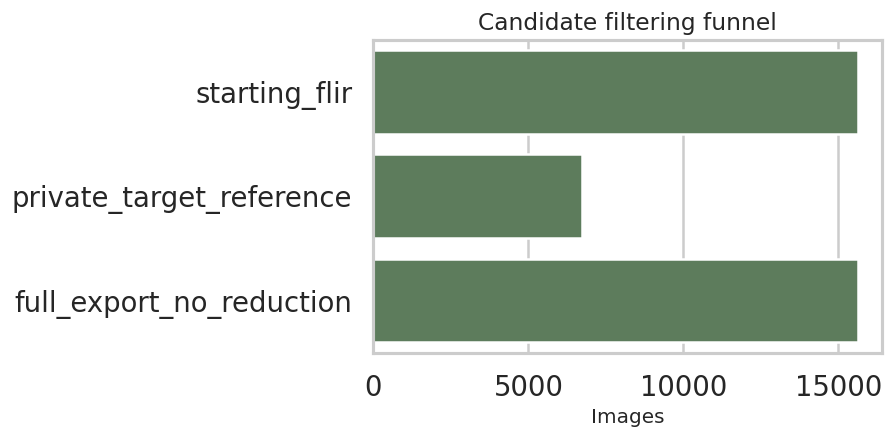

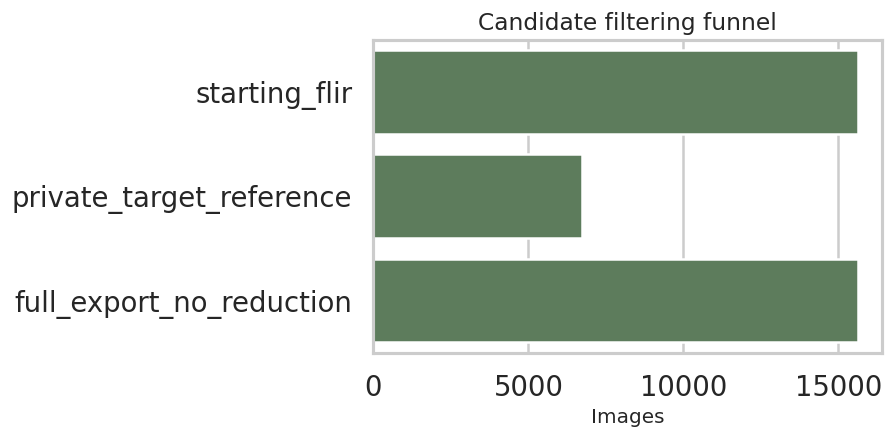

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=REDUCED_FLIR_BUNDLE["stage_table"], x="images", y="stage", ax=ax, color="#588157")
ax.set_title("Candidate filtering funnel")
ax.set_xlabel("Images")
ax.set_ylabel("")
fig.tight_layout()
save_figure(fig, "reduction_funnel")
fig


In [25]:
reduced_manifest_preview = REDUCED_FLIR_BUNDLE["images"][
    [
        "image_id",
        "split",
        "video_id",
        "scene_proxy_unit",
        "frame_index",
        "match_score",
        "support_score",
        "support_rate",
        "hard_support",
    ]
].sort_values(["split", "video_id", "frame_index"]).head(20)
reduced_manifest_preview


,image_id,split,video_id,scene_proxy_unit,frame_index,match_score,support_score,support_rate,hard_support
11886,test::0,test,4FRnNpmSmwktFJKjg,4FRnNpmSmwktFJKjg::chunk-0,745,NaN,NaN,NaN,False
11887,test::1,test,4FRnNpmSmwktFJKjg,4FRnNpmSmwktFJKjg::chunk-1,746,NaN,NaN,NaN,False
11888,test::2,test,4FRnNpmSmwktFJKjg,4FRnNpmSmwktFJKjg::chunk-2,747,NaN,NaN,NaN,False
11889,test::3,test,4FRnNpmSmwktFJKjg,4FRnNpmSmwktFJKjg::chunk-3,748,NaN,NaN,NaN,False
11890,test::4,test,4FRnNpmSmwktFJKjg,4FRnNpmSmwktFJKjg::chunk-4,749,NaN,NaN,NaN,False
11891,test::5,test,4FRnNpmSmwktFJKjg,4FRnNpmSmwktFJKjg::chunk-5,750,NaN,NaN,NaN,False
11892,test::6,test,4FRnNpmSmwktFJKjg,4FRnNpmSmwktFJKjg::chunk-6,751,NaN,NaN,NaN,False
11893,test::7,test,4FRnNpmSmwktFJKjg,4FRnNpmSmwktFJKjg::chunk-7,752,NaN,NaN,NaN,False
11894,test::8,test,4FRnNpmSmwktFJKjg,4FRnNpmSmwktFJKjg::chunk-8,753,NaN,NaN,NaN,False
11895,test::9,test,4FRnNpmSmwktFJKjg,4FRnNpmSmwktFJKjg::chunk-9,754,NaN,NaN,NaN,False


## 9. Reduced FLIR Audit

The same audit pipeline is re-run on the reduced subset so that the comparisons stay direct and symmetric.


In [26]:
REDUCED_FLIR_IMAGES = REDUCED_FLIR_BUNDLE["images"].copy()
REDUCED_FLIR_IMAGES["source_dataset"] = "flir_reduced"
REDUCED_FLIR_ANNOTATIONS = REDUCED_FLIR_BUNDLE["annotations"].copy()
REDUCED_FLIR_ANNOTATIONS["source_dataset"] = "flir_reduced"
REDUCED_FLIR_PROFILE = profile_dataset("flir_reduced", REDUCED_FLIR_IMAGES, REDUCED_FLIR_ANNOTATIONS)

REDUCED_FLIR_PROFILE["inventory"]


,dataset,images,annotations,person_annotations,mean_annotations_per_image,mean_persons_per_image,scene_units,camera_units,sequence_units
0,flir_reduced,15635,254053,67271,16.248993,4.30259,15635,0,158


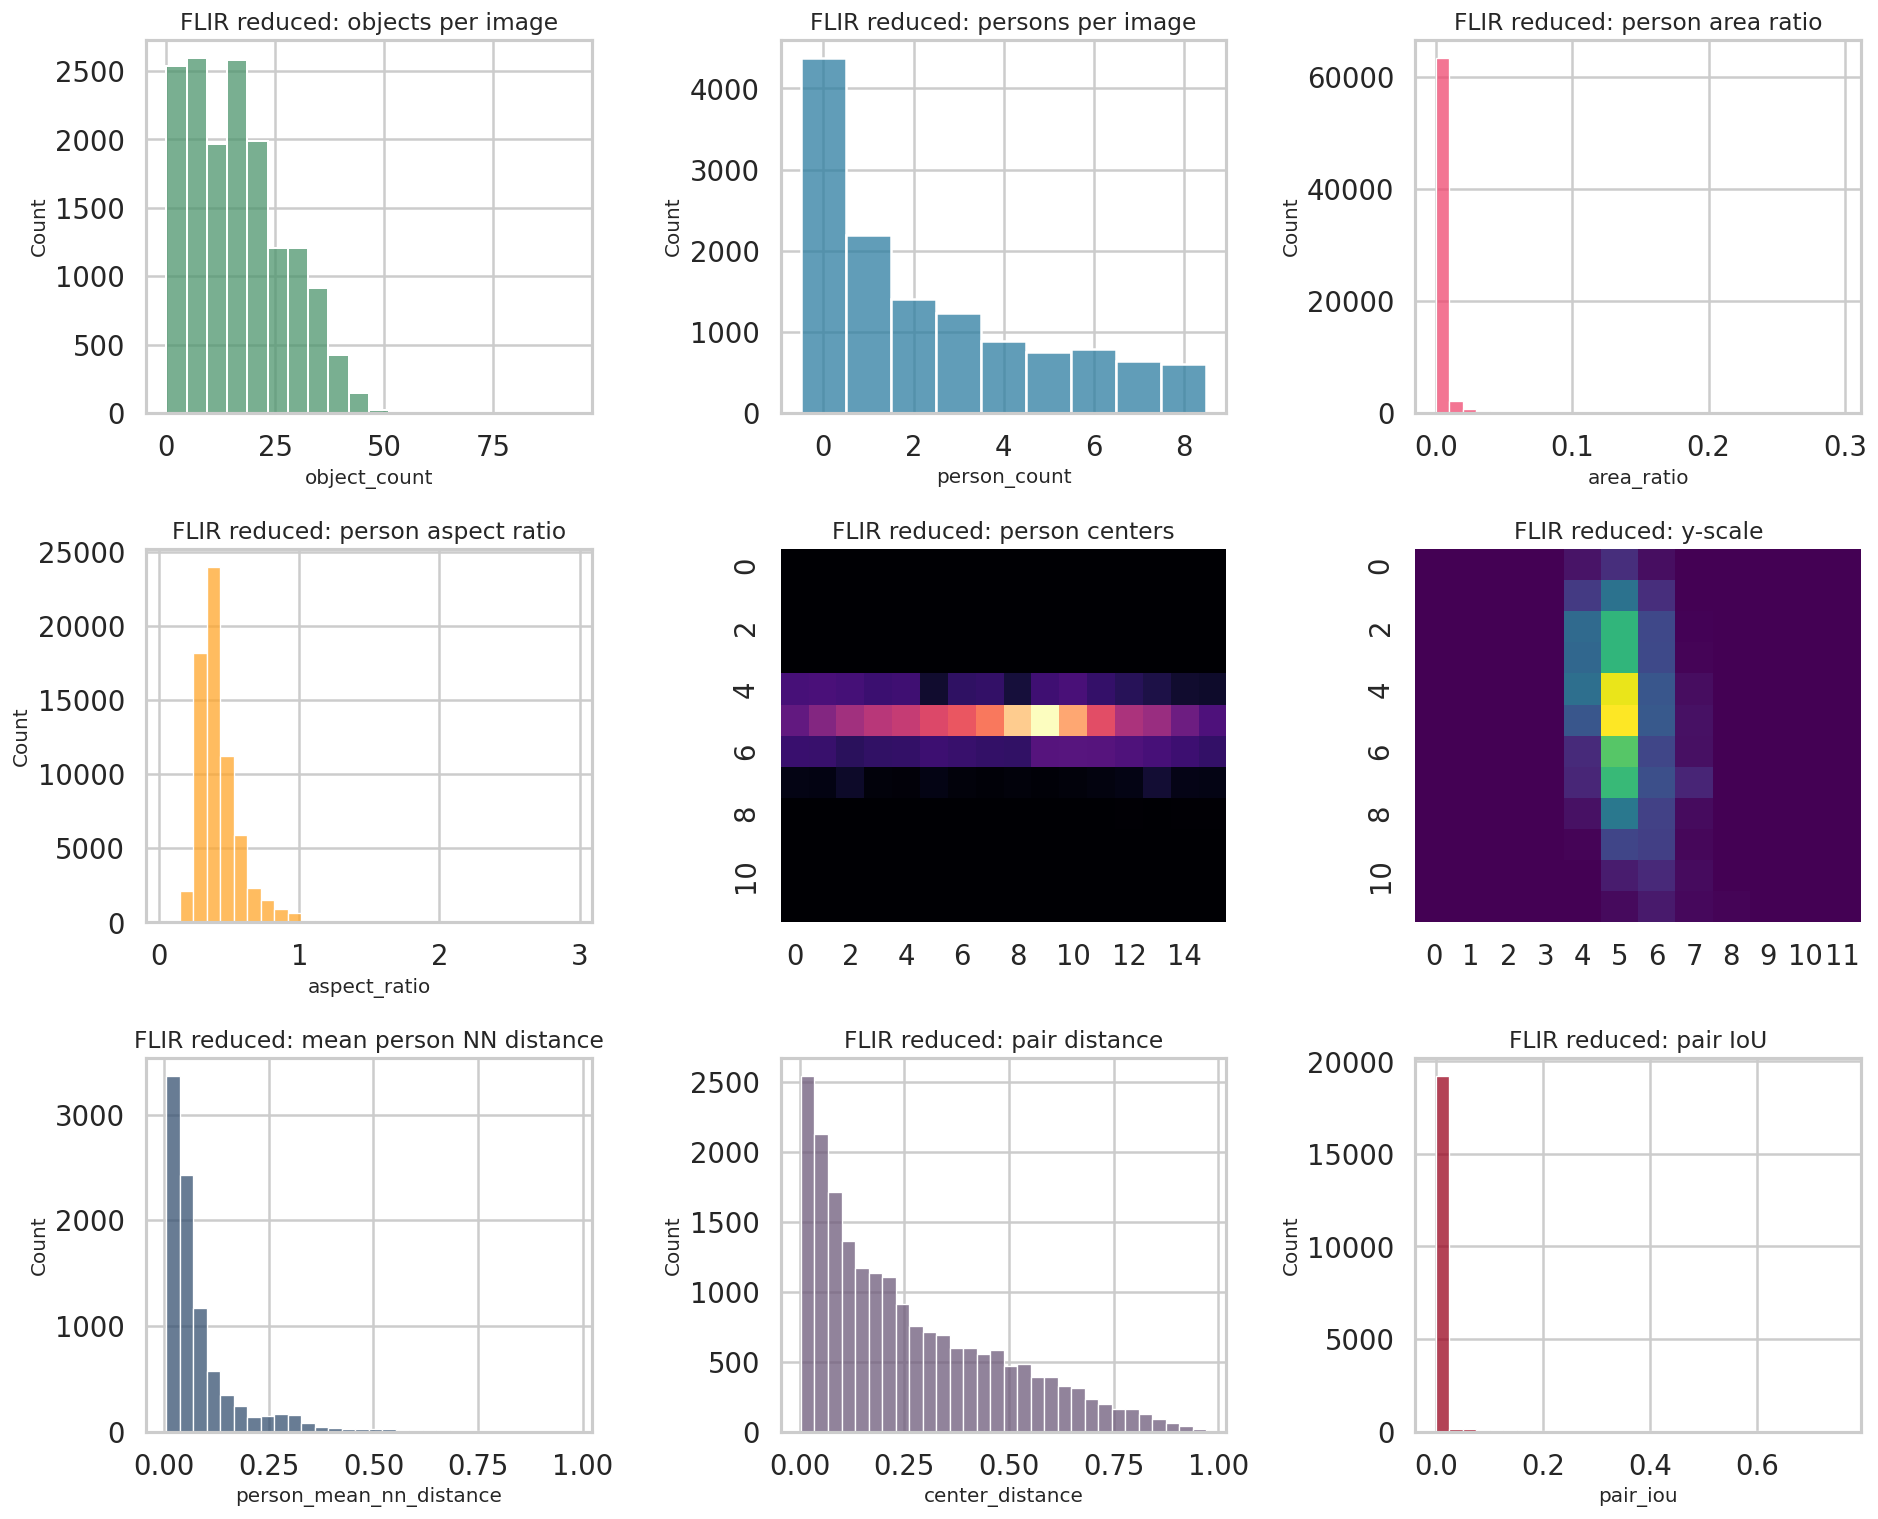

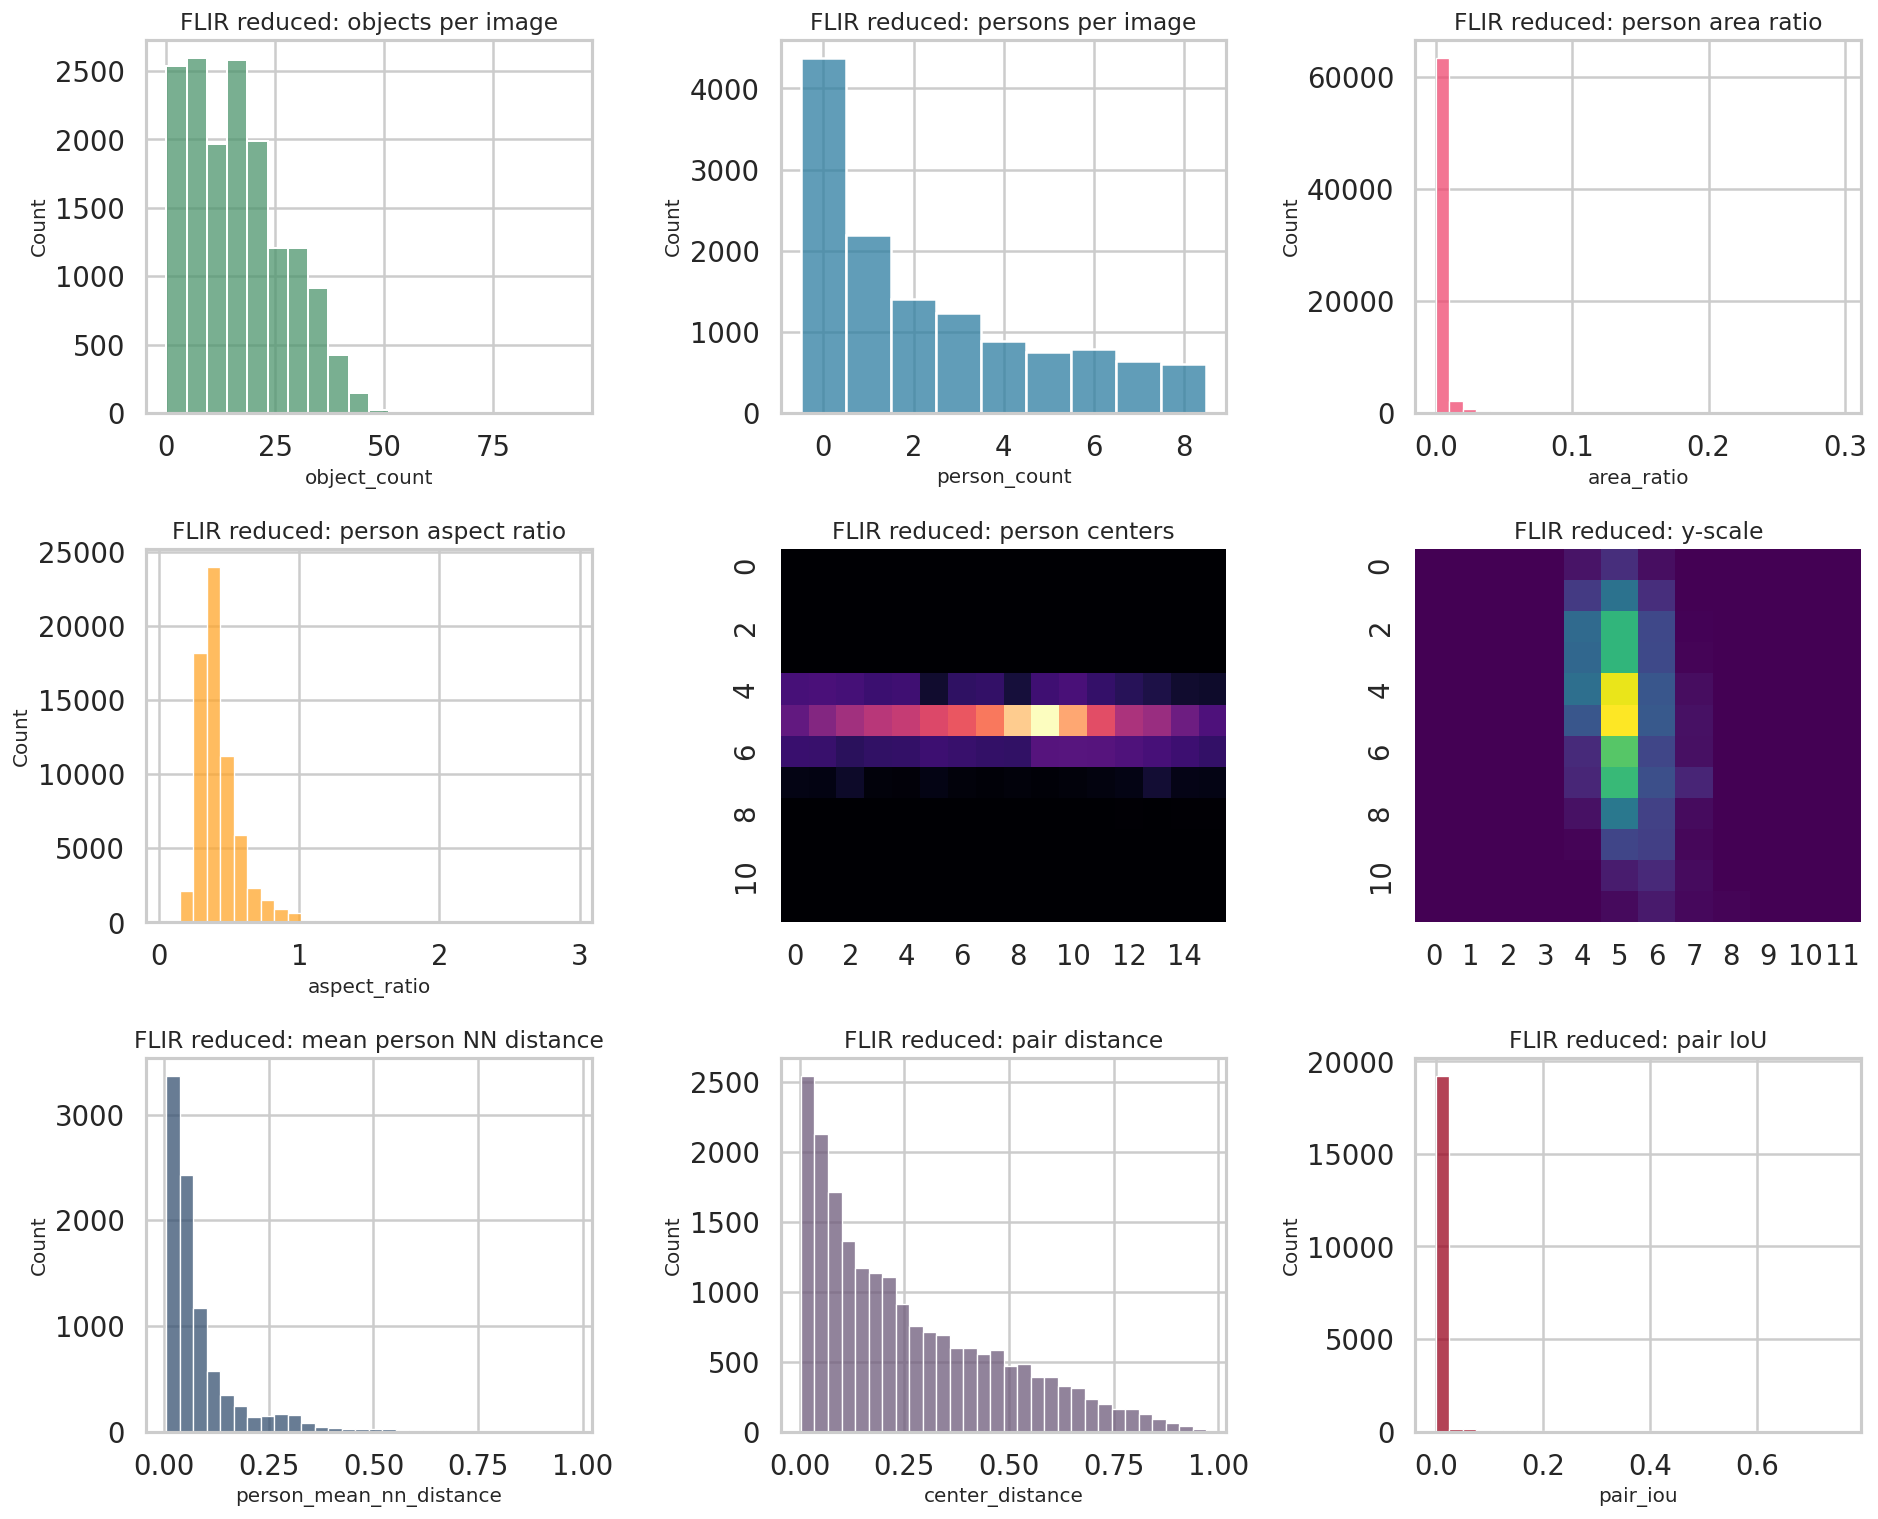

In [27]:
reduced_person_audit_fig = plot_person_audit(REDUCED_FLIR_PROFILE, "FLIR reduced")
save_figure(reduced_person_audit_fig, "flir_reduced_person_audit")
reduced_person_audit_fig


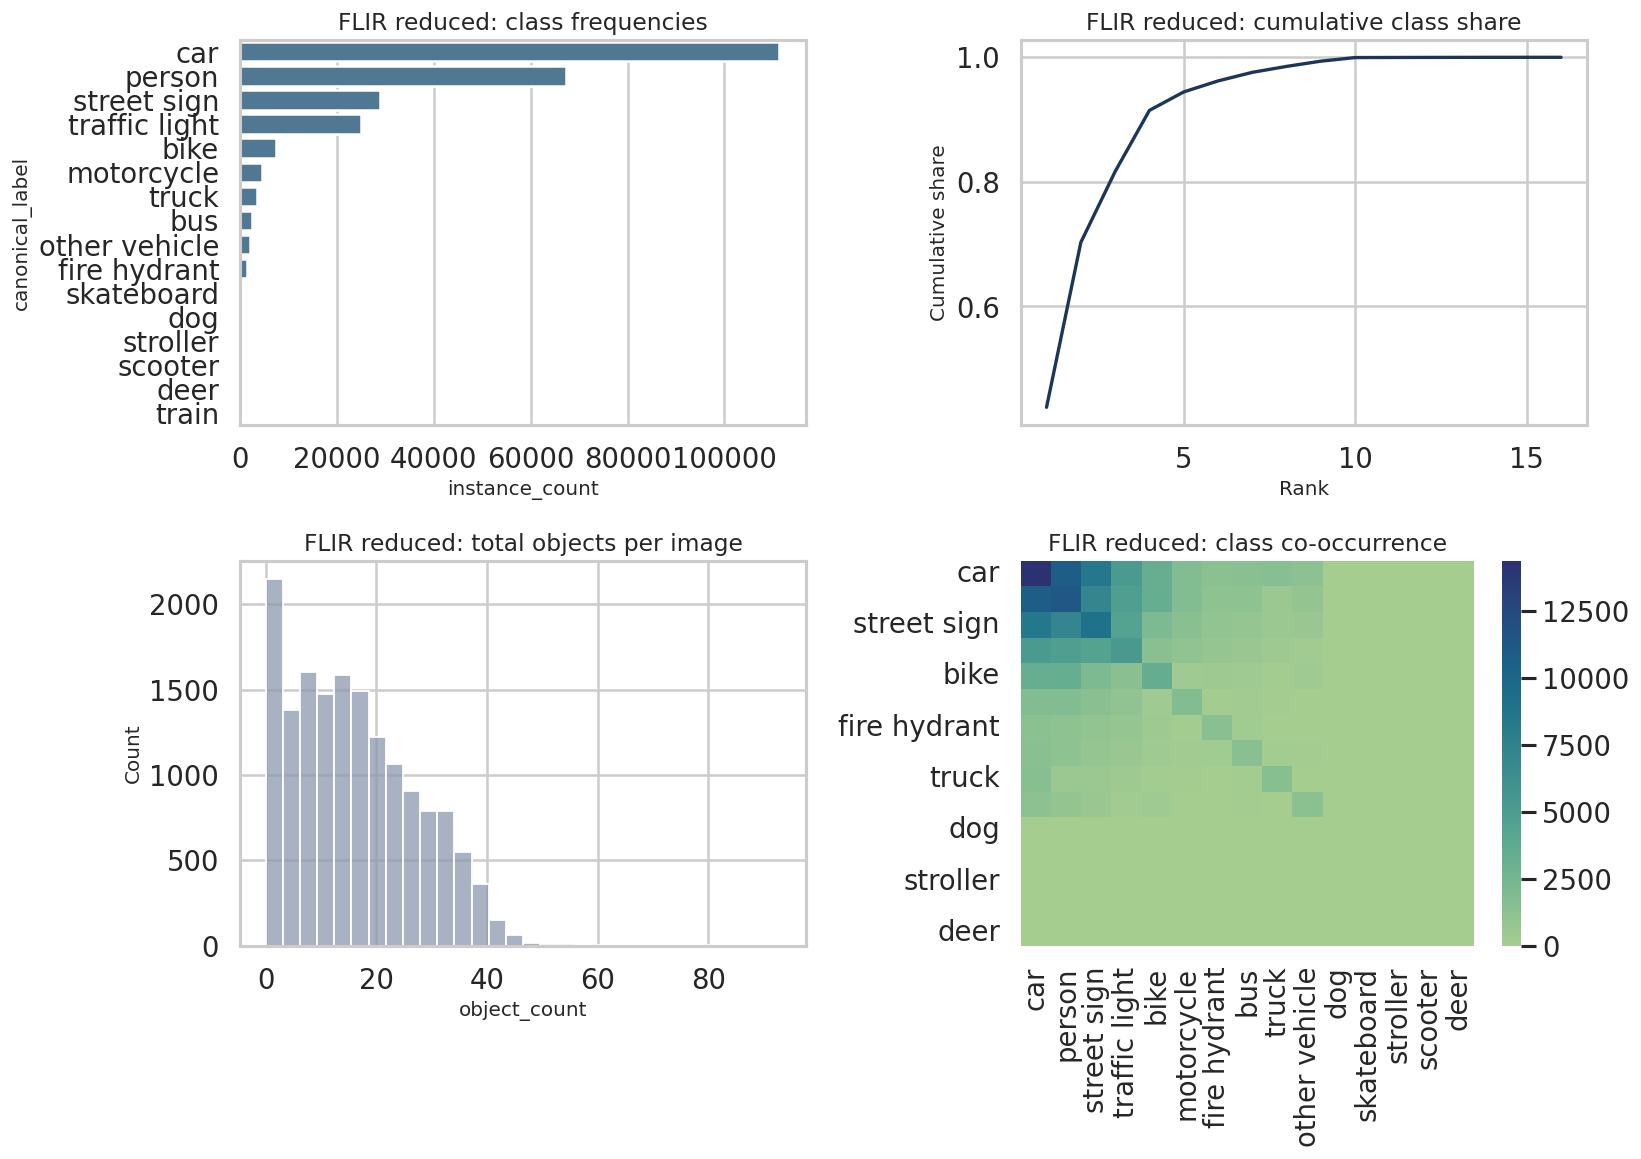

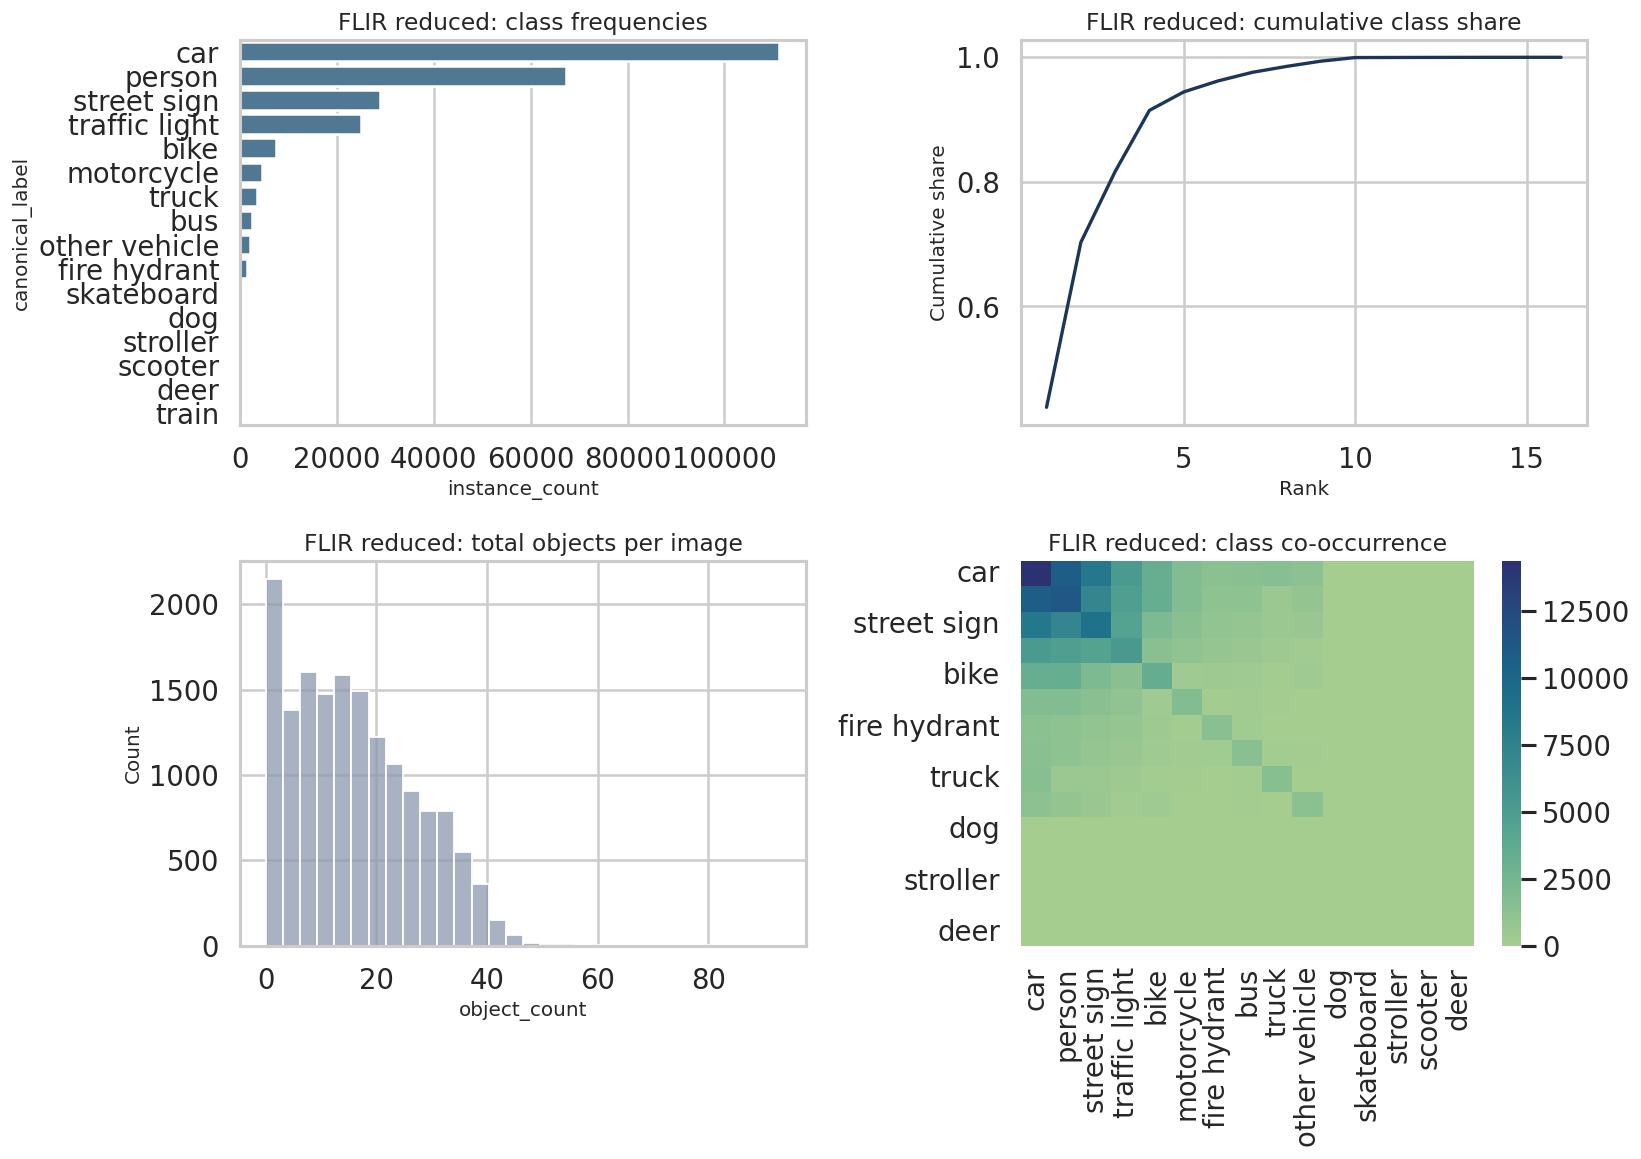

In [28]:
reduced_global_audit_fig = plot_flir_global_audit(REDUCED_FLIR_PROFILE, "FLIR reduced")
save_figure(reduced_global_audit_fig, "flir_reduced_global_audit")
reduced_global_audit_fig


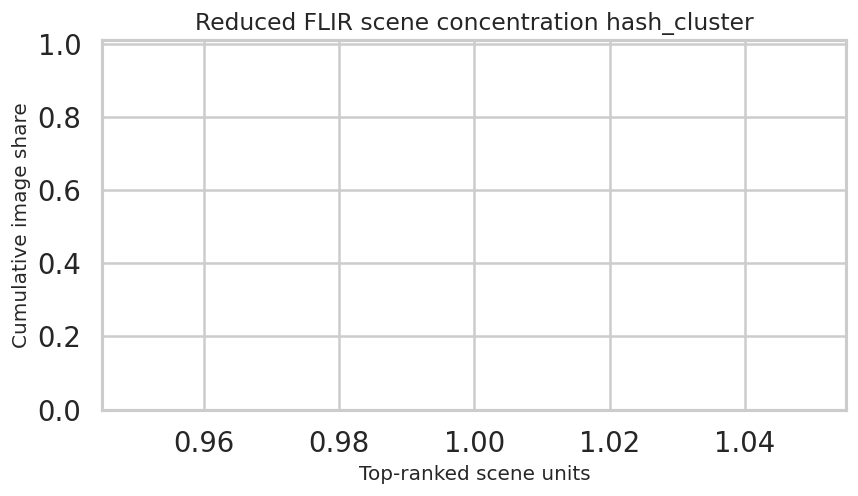

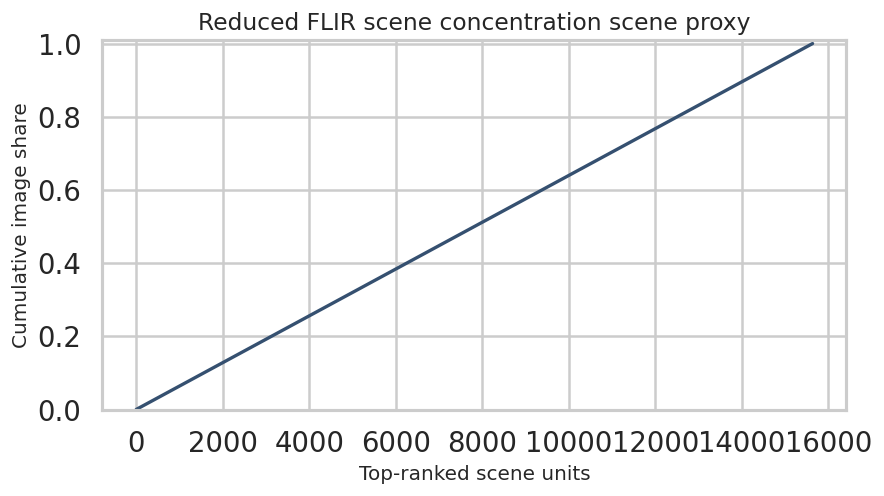

In [29]:
reduced_scene_fig = plot_scene_concentration(REDUCED_FLIR_PROFILE["images"], "ahash_cluster", "Reduced FLIR scene concentration hash_cluster")
reduced_scene_fig = plot_scene_concentration(REDUCED_FLIR_PROFILE["images"], "scene_proxy_unit", "Reduced FLIR scene concentration scene proxy")
save_figure(reduced_scene_fig, "flir_reduced_scene_concentration")



## 10. Post-reduction Cross-Dataset Comparison

Three pairwise blocks are tracked:

- private vs original FLIR,
- private vs reduced FLIR,
- original FLIR vs reduced FLIR.


In [30]:
PRIVATE_VS_FLIR_REDUCED = compare_profiles(PRIVATE_PROFILE, REDUCED_FLIR_PROFILE, "private_vs_flir_reduced")
FLIR_ORIGINAL_VS_REDUCED = compare_profiles(FLIR_PROFILE, REDUCED_FLIR_PROFILE, "flir_original_vs_reduced")

save_table(PRIVATE_VS_FLIR_REDUCED, "private_vs_flir_reduced_comparison")
save_table(FLIR_ORIGINAL_VS_REDUCED, "flir_original_vs_reduced_comparison")

PRIVATE_VS_FLIR_REDUCED


,comparison,statistic,category,metric,distance,importance
0,private_vs_flir_reduced,class_entropy,multiclass,absolute_difference,2.224064,preserve
1,private_vs_flir_reduced,scene_entropy,repetition,absolute_difference,1.414680,hard-match
2,private_vs_flir_reduced,person_aspect_ratio,geometry,wasserstein_1,0.828511,hard-match
3,private_vs_flir_reduced,person_y_logh_distribution,geometry,js_divergence_2d,0.817791,hard-match
4,private_vs_flir_reduced,class_gini,multiclass,absolute_difference,0.779065,preserve
5,private_vs_flir_reduced,person_center_distribution,geometry,js_divergence_2d,0.561496,hard-match
6,private_vs_flir_reduced,class_frequency,multiclass,js_divergence,0.531870,preserve
7,private_vs_flir_reduced,person_count_per_image,counts,js_divergence,0.292803,hard-match
8,private_vs_flir_reduced,person_mean_nn_distance,crowding,wasserstein_1,0.284627,soft-match
9,private_vs_flir_reduced,pairwise_person_distance,layout,wasserstein_1,0.250714,soft-match


In [31]:
delta_table = PRIVATE_VS_FLIR_ORIGINAL[
    ["statistic", "category", "distance", "importance"]
].rename(columns={"distance": "original_mismatch"}).merge(
    PRIVATE_VS_FLIR_REDUCED[["statistic", "distance"]].rename(columns={"distance": "reduced_mismatch"}),
    on="statistic",
    how="left",
)
delta_table["relative_improvement"] = (
    (delta_table["original_mismatch"] - delta_table["reduced_mismatch"])
    / delta_table["original_mismatch"].replace(0, np.nan)
)
delta_table["what_happened"] = np.where(
    delta_table["relative_improvement"] > 0.05,
    "got closer",
    np.where(delta_table["relative_improvement"] < -0.05, "moved away", "roughly unchanged"),
)
save_table(delta_table, "delta_distance_table")
delta_table


,statistic,category,original_mismatch,importance,reduced_mismatch,relative_improvement,what_happened
0,class_entropy,multiclass,2.224064,preserve,2.224064,0.000000,roughly unchanged
1,scene_entropy,repetition,1.414680,hard-match,1.414680,0.000000,roughly unchanged
2,person_aspect_ratio,geometry,0.828511,hard-match,0.828511,0.000000,roughly unchanged
3,person_y_logh_distribution,geometry,0.817791,hard-match,0.817791,0.000000,roughly unchanged
4,class_gini,multiclass,0.779065,preserve,0.779065,0.000000,roughly unchanged
5,person_center_distribution,geometry,0.561496,hard-match,0.561496,0.000000,roughly unchanged
6,class_frequency,multiclass,0.531870,preserve,0.531870,0.000000,roughly unchanged
7,person_count_per_image,counts,0.292803,hard-match,0.292803,0.000000,roughly unchanged
8,person_mean_nn_distance,crowding,0.284627,soft-match,0.284627,0.000000,roughly unchanged
9,pairwise_person_distance,layout,0.250714,soft-match,0.250714,0.000000,roughly unchanged


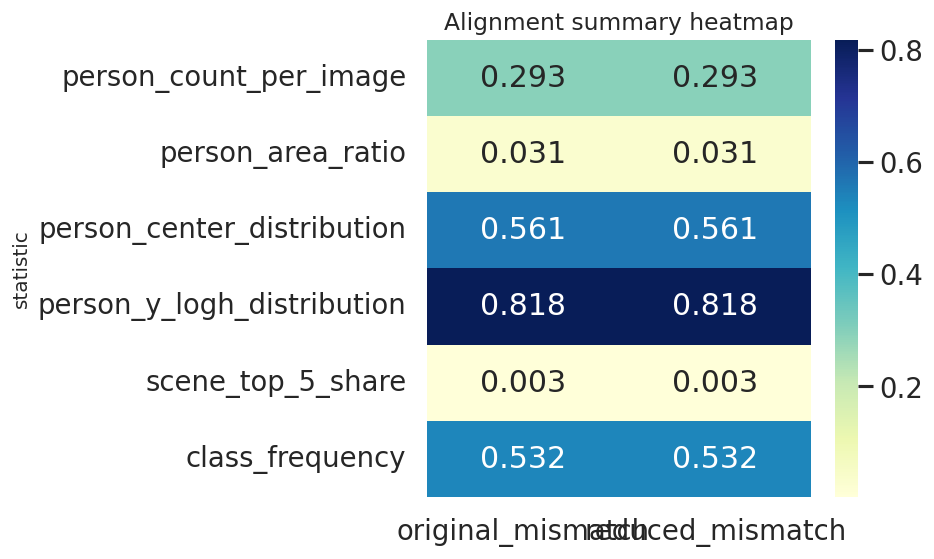

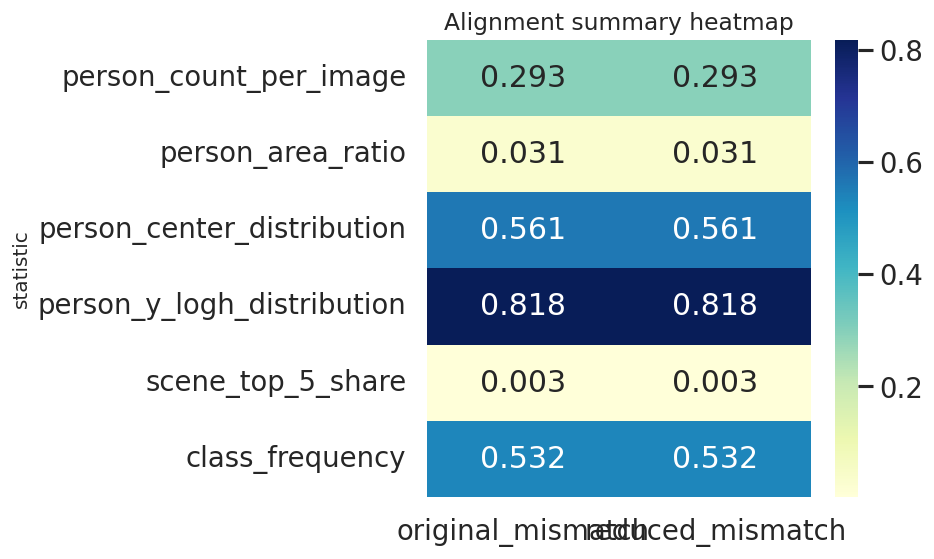

In [32]:
key_stats = [
    "person_count_per_image",
    "person_area_ratio",
    "person_center_distribution",
    "person_y_logh_distribution",
    "scene_top_5_share",
    "class_frequency",
]
heatmap_df = delta_table.set_index("statistic").loc[key_stats][["original_mismatch", "reduced_mismatch"]]
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
ax.set_title("Alignment summary heatmap")
fig.tight_layout()
save_figure(fig, "alignment_summary_heatmap")
fig


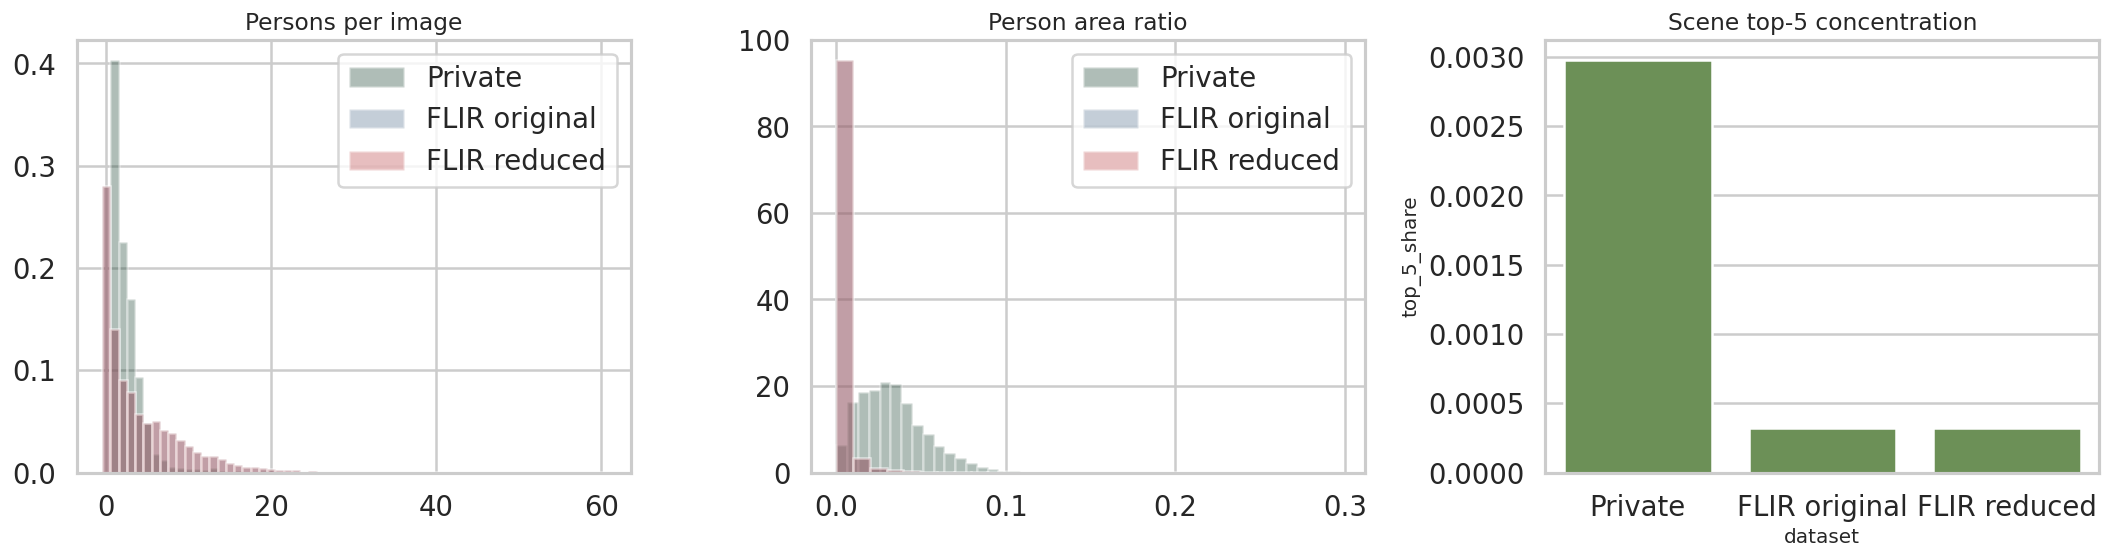

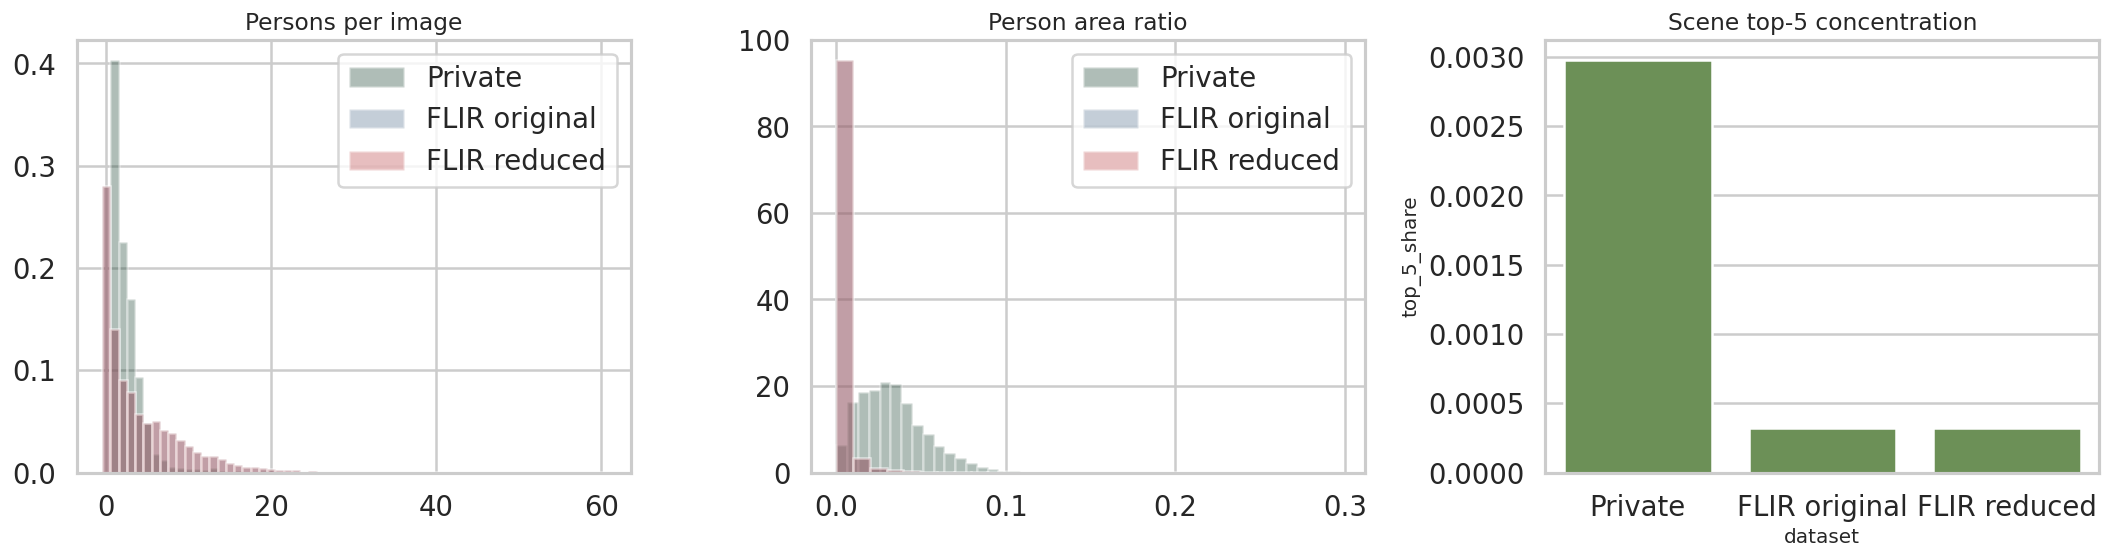

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

count_bins_overlay = np.arange(
    -0.5,
    max(
        PRIVATE_PROFILE["image_metrics"]["person_count"].max(),
        FLIR_PROFILE["image_metrics"]["person_count"].max(),
        REDUCED_FLIR_PROFILE["image_metrics"]["person_count"].max(),
        COUNT_BIN_CAP,
    )
    + 1.5,
    1.0,
)
for label, profile, color in [
    ("Private", PRIVATE_PROFILE, "#1b4332"),
    ("FLIR original", FLIR_PROFILE, "#577590"),
    ("FLIR reduced", REDUCED_FLIR_PROFILE, "#bc4749"),
]:
    axes[0].hist(
        profile["image_metrics"]["person_count"],
        bins=count_bins_overlay,
        density=True,
        alpha=0.35,
        label=label,
        color=color,
    )
axes[0].set_title("Persons per image")
axes[0].legend()

for label, profile, color in [
    ("Private", PRIVATE_PROFILE, "#1b4332"),
    ("FLIR original", FLIR_PROFILE, "#577590"),
    ("FLIR reduced", REDUCED_FLIR_PROFILE, "#bc4749"),
]:
    axes[1].hist(
        profile["person_annotations"]["area_ratio"],
        bins=30,
        density=True,
        alpha=0.35,
        label=label,
        color=color,
    )
axes[1].set_title("Person area ratio")
axes[1].legend()

scene_compare = pd.DataFrame(
    [
        {
            "dataset": label,
            "top_5_share": profile["scene_summary"].iloc[0][f"top_{TOP_K_SCENES}_share"],
            "scene_entropy": profile["scene_summary"].iloc[0]["scene_entropy"],
        }
        for label, profile in [
            ("Private", PRIVATE_PROFILE),
            ("FLIR original", FLIR_PROFILE),
            ("FLIR reduced", REDUCED_FLIR_PROFILE),
        ]
    ]
)
sns.barplot(data=scene_compare, x="dataset", y="top_5_share", ax=axes[2], color="#6a994e")
axes[2].set_title("Scene top-5 concentration")
fig.tight_layout()
save_figure(fig, "three_way_overlay_key_stats")
fig


## 11. Compliance and Anti-cheating Validation

The reduction should not solve the research problem at curation time. The checks below explicitly ask whether the proxy became closer on targeted person statistics while remaining multiclass, imbalanced, and split-clean.


In [34]:
CONSTRAINT_TABLE = build_constraint_table(
    private_constraints=PRIVATE_CONSTRAINTS,
    baseline_comparison=PRIVATE_VS_FLIR_ORIGINAL,
    reduced_comparison=PRIVATE_VS_FLIR_REDUCED,
)
save_table(CONSTRAINT_TABLE, "hard_soft_relaxed_constraint_table")
CONSTRAINT_TABLE


,statistic,role,target_form,tolerance,reason
0,dataset_size,hard-match,close to 6725 images,+/- 25%,keep the proxy in the same order of magnitude ...
1,person_count_per_image,hard-match,reduce histogram mismatch versus private,improve over baseline 0.2928,crowd structure directly affects transfer
2,person_center_distribution,hard-match,reduce 2D JS divergence versus private,improve over baseline 0.5615,position bias is a strong deployment prior
3,person_y_logh_distribution,hard-match,reduce 2D JS divergence versus private,improve over baseline 0.8178,vertical position and scale encode viewpoint bias
4,scene_top_5_share,hard-match,move repetition concentration toward private,private target 0.003,repetition bias matters for transfer realism
5,pairwise_person_layout_mmd,soft-match,improve multivariate layout similarity,baseline 0.0449 -> reduced 0.0603,"layout matters, but exact matching is not requ..."
6,class_frequency,relaxed,do not force FLIR to mimic private single-clas...,multiclass support must remain meaningful,preserve publication value and long-tail behavior


In [35]:
COMPLIANCE_TABLE = build_compliance_table(
    private_profile=PRIVATE_PROFILE,
    flir_profile=FLIR_PROFILE,
    reduced_profile=REDUCED_FLIR_PROFILE,
    baseline_comparison=PRIVATE_VS_FLIR_ORIGINAL,
    reduced_comparison=PRIVATE_VS_FLIR_REDUCED,
)
save_table(COMPLIANCE_TABLE, "compliance_table")
COMPLIANCE_TABLE


,criterion,rationale,observed_result,pass
0,thermal_only_detection,keep task and modality unchanged,all reduced paths come from FLIR thermal split...,True
1,reduced_is_not_person_only,avoid collapsing the benchmark to the private ...,15 non-person classes remain active,True
2,multiclass_support_retained,preserve publication utility,16/16 active classes retained,True
3,long_tail_not_flattened,keep measurable imbalance,"original gini=0.779, reduced gini=0.779",True
4,scene_split_disjointness,avoid scene leakage across reduced splits,scene_proxy_unit overlap across splits is zero,True
5,person_count_became_closer,one of the main hard-match targets must improve,"baseline=0.2928, reduced=0.2928",False
6,center_geometry_became_closer,person geometry should move toward the private...,"baseline=0.5615, reduced=0.5615",False
7,scene_repetition_became_closer,repetition bias is explicitly targeted,"baseline=0.0027, reduced=0.0027",False


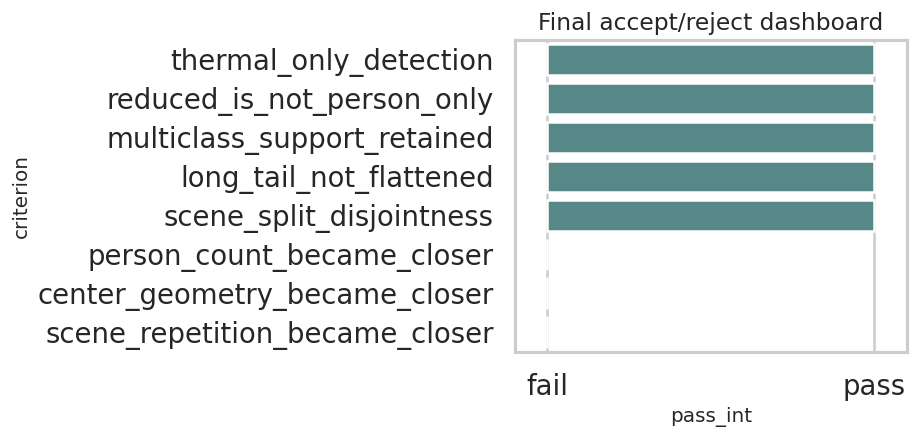

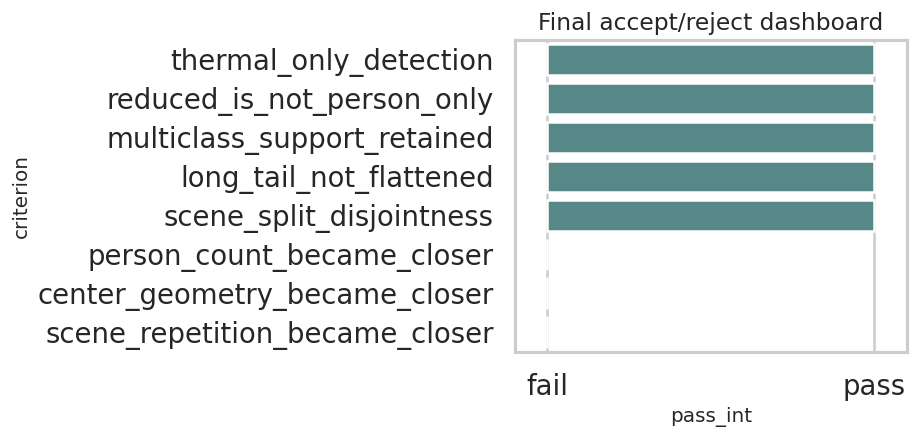

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = COMPLIANCE_TABLE.copy()
plot_df["pass_int"] = plot_df["pass"].astype(int)
sns.barplot(data=plot_df, x="pass_int", y="criterion", ax=ax, color="#4d908e")
ax.set_xlim(-0.1, 1.1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["fail", "pass"])
ax.set_title("Final accept/reject dashboard")
fig.tight_layout()
save_figure(fig, "accept_reject_dashboard")
fig


## 12. Research Interpretation and Paper Narrative Extraction

Final interpretation is split into:

- **transferability**: which private properties were moved closer,
- **publication**: what multiclass and long-tail value was preserved,
- **augmentation readiness**: which residual gaps remain measurable and can motivate later synthetic or generative balancing work.


In [37]:
NARRATIVE_TABLE = build_narrative_table(
    private_vs_original=PRIVATE_VS_FLIR_ORIGINAL,
    private_vs_reduced=PRIVATE_VS_FLIR_REDUCED,
    original_vs_reduced=FLIR_ORIGINAL_VS_REDUCED,
)
save_table(NARRATIVE_TABLE, "paper_narrative_table")
NARRATIVE_TABLE


,claim,supporting_evidence,candidate_figure_or_table
0,Original FLIR is broader than the private targ...,"person_count 0.2928, center 0.5615, scene_top_...",mismatch ranking before reduction
1,Reduced FLIR is closer to the private dataset ...,"person_count 0.2928 -> 0.2928, center 0.5615 -...",alignment improvement heatmap
2,The reduction preserves enough multiclass and ...,class_frequency delta original-vs-reduced 0.00...,retained difficulty table
3,The reduced proxy exposes measurable residual ...,"pairwise layout mmd 0.0603, class_frequency 0....",intentional mismatch table


In [38]:
paper_reuse_candidates = pd.DataFrame(
    [
        {"asset": "study_flow", "why_reuse": "methods overview"},
        {"asset": "pre_reduction_mismatch_ranking", "why_reuse": "motivates the reduction"},
        {"asset": "alignment_summary_heatmap", "why_reuse": "shows what became closer"},
        {"asset": "flir_reduced_global_audit", "why_reuse": "documents preserved multiclass structure"},
        {"asset": "compliance_table", "why_reuse": "anti-cheating summary"},
    ]
)
save_table(paper_reuse_candidates, "paper_reuse_candidates")
paper_reuse_candidates


,asset,why_reuse
0,study_flow,methods overview
1,pre_reduction_mismatch_ranking,motivates the reduction
2,alignment_summary_heatmap,shows what became closer
3,flir_reduced_global_audit,documents preserved multiclass structure
4,compliance_table,anti-cheating summary


In [39]:
display(
    Markdown(
        "\n".join(
            [
                "**End state**",
                "",
                "- The notebook has loaded the actual local `v18` and FLIR schemas rather than assuming a generic thermal format.",
                "- The private domain is profiled with the same statistical language later used on FLIR.",
                "- A reduced FLIR subset is created with scene-aware selection and explicit export manifests.",
                "- Compliance tables make it possible to argue that this is domain alignment rather than benchmark trivialization.",
                "",
                "**Official FLIR reference used for framing**",
                "",
                "- Teledyne FLIR dataset page: `https://oem.flir.com/solutions/automotive/adas-dataset-form/`",
                "",
                "Local raw annotations remain the source of truth for the actual active label set in this workspace.",
            ]
        )
    )
)


**End state**

- The notebook has loaded the actual local `v18` and FLIR schemas rather than assuming a generic thermal format.
- The private domain is profiled with the same statistical language later used on FLIR.
- A reduced FLIR subset is created with scene-aware selection and explicit export manifests.
- Compliance tables make it possible to argue that this is domain alignment rather than benchmark trivialization.

**Official FLIR reference used for framing**

- Teledyne FLIR dataset page: `https://oem.flir.com/solutions/automotive/adas-dataset-form/`

Local raw annotations remain the source of truth for the actual active label set in this workspace.